# P5 — Latent Space Explainability (AAPL)

This notebook implements the explainability phase in an AAPL workflow.

Execution order:
1. Validate latent artifact schema (`mus`, `logvars`, `dates`) for all 6 variants.
2. Build feature table and latent diagnostics.
3. Add traversals, Jacobians, interpolation, and synthesis outputs.

All outputs are saved under `artifacts/validation/latent_analysis/`.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path(os.getcwd())
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Project root: {ROOT}')
print(f'Device: {DEVICE}')

Project root: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis
Device: cuda


In [2]:
TICKER = 'AAPL'
VARIANTS = ['mlp', 'mlp_log', 'mlp_log_arb', 'conv', 'conv_log', 'conv_log_arb']

EVAL_ROOT = ROOT / 'artifacts' / 'eval' / TICKER
OUT_ROOT = ROOT / 'artifacts' / 'validation' / 'latent_analysis' / TICKER
PLOTS_DIR = OUT_ROOT / 'plots'
TABLES_DIR = OUT_ROOT / 'tables'

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Eval root: {EVAL_ROOT}')
print(f'Output root: {OUT_ROOT}')

Eval root: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\eval\AAPL
Output root: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL


In [3]:
def load_latent_artifact(variant: str) -> dict:
    path = EVAL_ROOT / variant / 'test_latents.pt'
    if not path.exists():
        raise FileNotFoundError(f'Missing latent artifact: {path}')

    payload = torch.load(str(path), map_location='cpu', weights_only=False)

    required_keys = ('mus', 'logvars', 'dates')
    missing = [k for k in required_keys if k not in payload]
    if missing:
        raise KeyError(
            f'Latent artifact for {variant} is missing required keys {missing}. '
            f'Expected keys: {required_keys}. Path: {path}'
        )

    mus = payload['mus']
    logvars = payload['logvars']
    dates = payload['dates']

    if not isinstance(mus, torch.Tensor):
        mus = torch.as_tensor(mus)
    if not isinstance(logvars, torch.Tensor):
        logvars = torch.as_tensor(logvars)

    if mus.ndim != 2:
        raise ValueError(f'{variant}: mus must be 2D [N, latent_dim], got shape={tuple(mus.shape)}')
    if logvars.ndim != 2:
        raise ValueError(
            f'{variant}: logvars must be 2D [N, latent_dim], got shape={tuple(logvars.shape)}'
        )
    if mus.shape != logvars.shape:
        raise ValueError(
            f'{variant}: mus/logvars shape mismatch: {tuple(mus.shape)} vs {tuple(logvars.shape)}'
        )

    n_samples = mus.shape[0]
    if dates is not None and len(dates) != n_samples:
        raise ValueError(
            f'{variant}: dates length mismatch. len(dates)={len(dates)} vs N={n_samples}'
        )

    return {
        'variant': variant,
        'path': path,
        'mus': mus,
        'logvars': logvars,
        'dates': dates,
        'n_samples': int(n_samples),
        'latent_dim': int(mus.shape[1]),
    }


def validate_all_variants(variants: list[str]) -> pd.DataFrame:
    rows = []
    for variant in variants:
        item = load_latent_artifact(variant)
        rows.append({
            'ticker': TICKER,
            'variant': variant,
            'n_samples': item['n_samples'],
            'latent_dim': item['latent_dim'],
            'has_dates': item['dates'] is not None,
            'file': str(item['path'].relative_to(ROOT)),
        })

    return pd.DataFrame(rows).sort_values('variant').reset_index(drop=True)

In [4]:
schema_df = validate_all_variants(VARIANTS)
display(schema_df)

if not (schema_df['n_samples'] == schema_df['n_samples'].iloc[0]).all():
    raise RuntimeError('Sample count mismatch across variants. Stop and investigate before analysis.')

if not (schema_df['latent_dim'] == schema_df['latent_dim'].iloc[0]).all():
    raise RuntimeError('Latent dimension mismatch across variants. Stop and investigate before analysis.')

out_csv = TABLES_DIR / 'latent_schema_check_AAPL.csv'
schema_df.to_csv(out_csv, index=False)
print(f'Latent schema check saved: {out_csv}')

,ticker,variant,n_samples,latent_dim,has_dates,file
0,AAPL,conv,244,24,True,artifacts\eval\AAPL\conv\test_latents.pt
1,AAPL,conv_log,244,24,True,artifacts\eval\AAPL\conv_log\test_latents.pt
2,AAPL,conv_log_arb,244,24,True,artifacts\eval\AAPL\conv_log_arb\test_latents.pt
3,AAPL,mlp,244,24,True,artifacts\eval\AAPL\mlp\test_latents.pt
4,AAPL,mlp_log,244,24,True,artifacts\eval\AAPL\mlp_log\test_latents.pt
5,AAPL,mlp_log_arb,244,24,True,artifacts\eval\AAPL\mlp_log_arb\test_latents.pt


Latent schema check saved: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\latent_schema_check_AAPL.csv


## 1. Market Feature Engineering

Build a per-date feature table from the AAPL market implied-volatility surfaces.

Feature definitions for this phase:
- **Channel convention:** primary features use the channel-average of call and put surfaces.
- **ATM level:** mean IV at delta 50 across maturities.
- **Overall level:** mean IV across the full channel-averaged surface.
- **Skew proxy:** mean 75Δ minus 25Δ spread across maturities.
- **Risk reversal:** export both sign conventions, `call75_minus_put25` and `put25_minus_call75`.
- **Term slope:** ATM front/back slope exported in both sign conventions for clarity.
- **Curvature:** quadratic-fit smile curvature coefficient per maturity, averaged across maturities.

This block also validates that market-surface dates align exactly with the latent-artifact dates before any downstream analysis proceeds.

In [5]:
import json


def _normalize_dates(values) -> np.ndarray:
    series = pd.to_datetime(pd.Series(values))
    return series.dt.normalize().to_numpy(dtype='datetime64[ns]')


reference_variant = VARIANTS[0]
reference_surfaces_dir = EVAL_ROOT / reference_variant / 'surfaces'
market_path = reference_surfaces_dir / 'market_surfaces.npy'
dates_path = reference_surfaces_dir / 'vae_surface_dates.csv'
grid_spec_path = reference_surfaces_dir / 'grid_spec.json'

if not market_path.exists():
    raise FileNotFoundError(f'Missing market surfaces file: {market_path}')
if not dates_path.exists():
    raise FileNotFoundError(f'Missing market dates file: {dates_path}')
if not grid_spec_path.exists():
    raise FileNotFoundError(f'Missing grid spec file: {grid_spec_path}')

market_surfaces = np.load(market_path)  # [N, C, H, W] in original IV space
market_dates_df = pd.read_csv(dates_path)
market_dates = _normalize_dates(market_dates_df.iloc[:, 0].to_numpy())

with open(grid_spec_path, 'r', encoding='utf-8') as f:
    grid_spec = json.load(f)

days_grid = np.asarray(grid_spec['days_grid'], dtype=float)
delta_grid_raw = np.asarray(grid_spec['delta_grid'], dtype=float)
delta_grid = delta_grid_raw / 100.0 if np.nanmax(delta_grid_raw) > 1.5 else delta_grid_raw
cp_order = [str(item).lower() for item in grid_spec.get('cp_order', ['call', 'put'])]

call_idx = next((i for i, label in enumerate(cp_order) if label.startswith('c')), 0)
put_idx = next((i for i, label in enumerate(cp_order) if label.startswith('p')), 1 if market_surfaces.shape[1] > 1 else 0)

idx25 = int(np.argmin(np.abs(delta_grid - 0.25)))
idx50 = int(np.argmin(np.abs(delta_grid - 0.50)))
idx75 = int(np.argmin(np.abs(delta_grid - 0.75)))

expected_n = int(schema_df['n_samples'].iloc[0])
if market_surfaces.shape[0] != expected_n:
    raise RuntimeError(
        f'Market surface sample count mismatch: {market_surfaces.shape[0]} vs expected {expected_n}'
    )

for variant in VARIANTS:
    latent_dates = _normalize_dates(load_latent_artifact(variant)['dates'])
    if not np.array_equal(latent_dates, market_dates):
        raise RuntimeError(f'Date mismatch between market surfaces and latent artifact for {variant}')

avg_surfaces = np.nanmean(market_surfaces, axis=1)  # [N, H, W]

overall_level = np.nanmean(avg_surfaces, axis=(1, 2))
atm_level = np.nanmean(avg_surfaces[:, :, idx50], axis=1)
skew_75_minus_25_mean = np.nanmean(avg_surfaces[:, :, idx75] - avg_surfaces[:, :, idx25], axis=1)

call75_minus_put25 = np.nanmean(
    market_surfaces[:, call_idx, :, idx75] - market_surfaces[:, put_idx, :, idx25],
    axis=1,
    )
put25_minus_call75 = -call75_minus_put25

front_atm = avg_surfaces[:, 0, idx50]
back_atm = avg_surfaces[:, -1, idx50]
term_slope_back_minus_front_atm = back_atm - front_atm
term_slope_front_minus_back_atm = front_atm - back_atm

smile_curvature_quad_mean = []
for surface in avg_surfaces:
    maturity_coeffs = []
    for maturity_slice in surface:
        valid = np.isfinite(maturity_slice) & np.isfinite(delta_grid)
        if valid.sum() < 3:
            continue
        try:
            quad_a, _, _ = np.polyfit(delta_grid[valid], maturity_slice[valid], deg=2)
            maturity_coeffs.append(float(quad_a))
        except np.linalg.LinAlgError:
            continue
    smile_curvature_quad_mean.append(np.nan if not maturity_coeffs else float(np.mean(maturity_coeffs)))

features_df = pd.DataFrame({
    'date': pd.to_datetime(market_dates),
    'overall_level': overall_level,
    'atm_level_delta50_mean': atm_level,
    'skew_75_minus_25_mean': skew_75_minus_25_mean,
    'rr_call75_minus_put25': call75_minus_put25,
    'rr_put25_minus_call75': put25_minus_call75,
    'term_slope_back_minus_front_atm': term_slope_back_minus_front_atm,
    'term_slope_front_minus_back_atm': term_slope_front_minus_back_atm,
    'smile_curvature_quad_mean': smile_curvature_quad_mean,
})

if len(features_df) != expected_n:
    raise RuntimeError(f'Feature table row count mismatch: {len(features_df)} vs expected {expected_n}')

numeric_cols = [col for col in features_df.columns if col != 'date']
nan_counts = features_df[numeric_cols].isna().sum().sort_values(ascending=False)
if nan_counts.any():
    raise RuntimeError(
        'Feature table contains unexpected NaNs:\n' + nan_counts[nan_counts > 0].to_string()
    )

feature_path = TABLES_DIR / f'market_features_{TICKER}.csv'
features_df.to_csv(feature_path, index=False)

display(features_df.head())
display(nan_counts.to_frame(name='n_missing').T)

print(f'Reference variant: {reference_variant}')
print(f'Call/put indices: call={call_idx}, put={put_idx}, cp_order={cp_order}')
print(f'Delta indices: 25Δ->{idx25}, 50Δ->{idx50}, 75Δ->{idx75}')
print(f'Feature table saved: {feature_path}')

,date,overall_level,atm_level_delta50_mean,skew_75_minus_25_mean,rr_call75_minus_put25,rr_put25_minus_call75,term_slope_back_minus_front_atm,term_slope_front_minus_back_atm,smile_curvature_quad_mean
0,2024-09-10,0.266242,0.253051,0.003293,0.010889,-0.010889,-0.031320,0.031320,0.302478
1,2024-09-11,0.258754,0.243864,0.004387,0.011571,-0.011571,-0.007908,0.007908,0.344464
2,2024-09-12,0.256127,0.241622,0.001814,0.003656,-0.003656,0.001447,-0.001447,0.340449
3,2024-09-13,0.252192,0.238721,0.000618,0.000124,-0.000124,0.012715,-0.012715,0.316455
4,2024-09-16,0.257030,0.245170,0.001975,0.004587,-0.004587,-0.010612,0.010612,0.270693


,overall_level,atm_level_delta50_mean,skew_75_minus_25_mean,rr_call75_minus_put25,rr_put25_minus_call75,term_slope_back_minus_front_atm,term_slope_front_minus_back_atm,smile_curvature_quad_mean
n_missing,0,0,0,0,0,0,0,0


Reference variant: mlp
Call/put indices: call=0, put=1, cp_order=['c', 'p']
Delta indices: 25Δ->3, 50Δ->8, 75Δ->13
Feature table saved: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\market_features_AAPL.csv


## 2. KL Per-Dimension Analysis

Compute latent KL usage by dimension for each AAPL variant.

This is the first core explainability block: it tells us which latent dimensions are active, how concentrated the information content is, and how latent usage differs across architectures/variants.

Outputs from this block:
- Per-variant KL-by-dimension table
- Effective dimensionality summary table
- KL bar chart panel (one subplot per variant)
- Cross-model KL heatmap
- Cumulative KL concentration plot

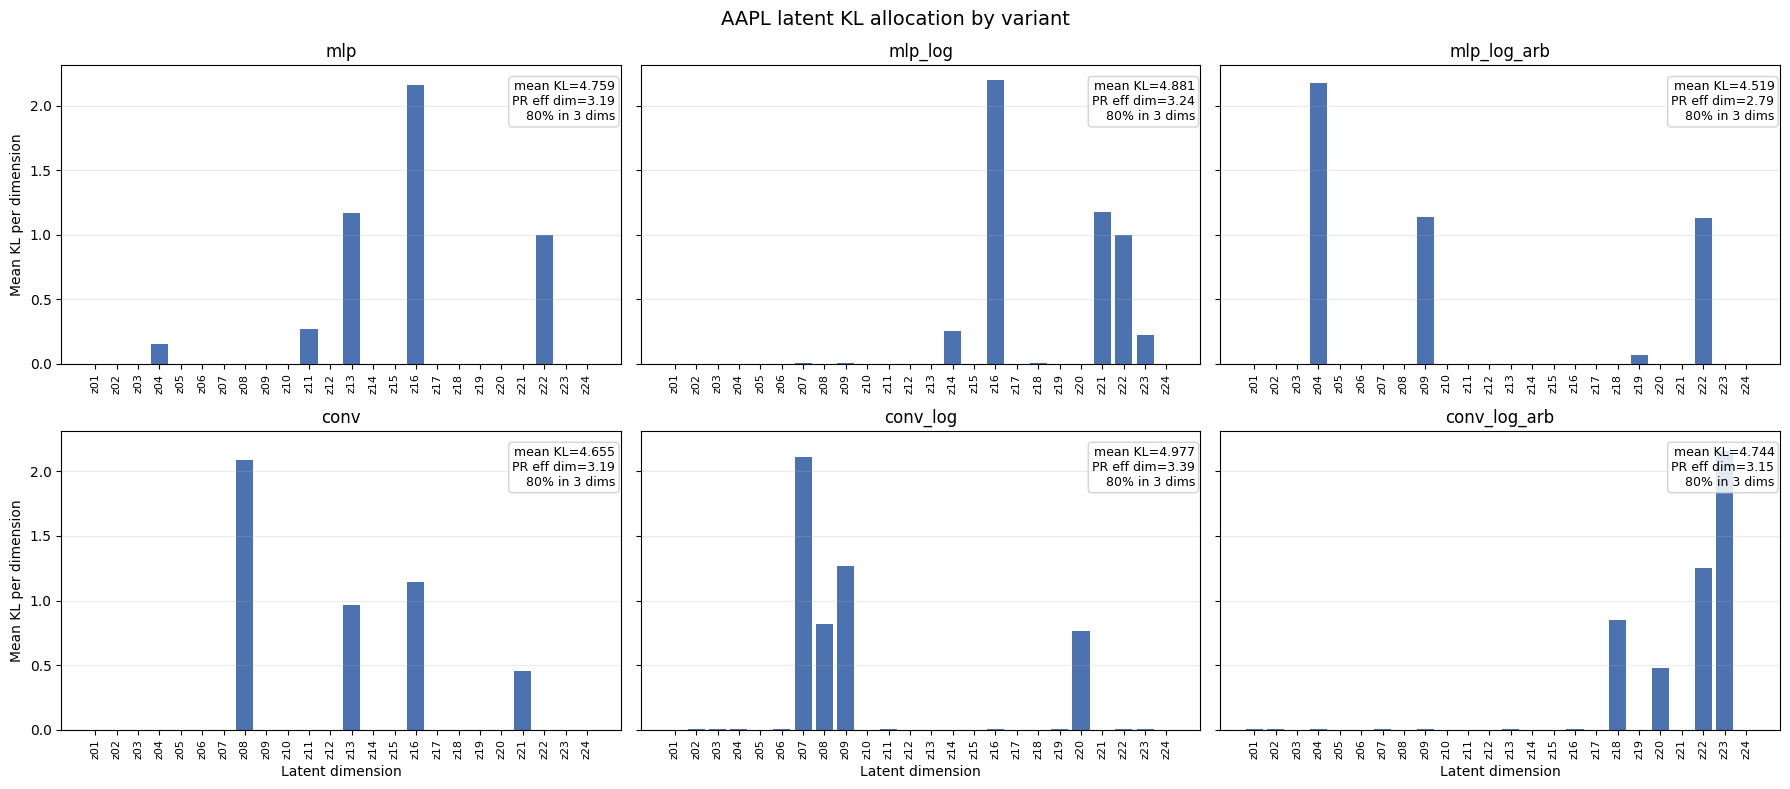

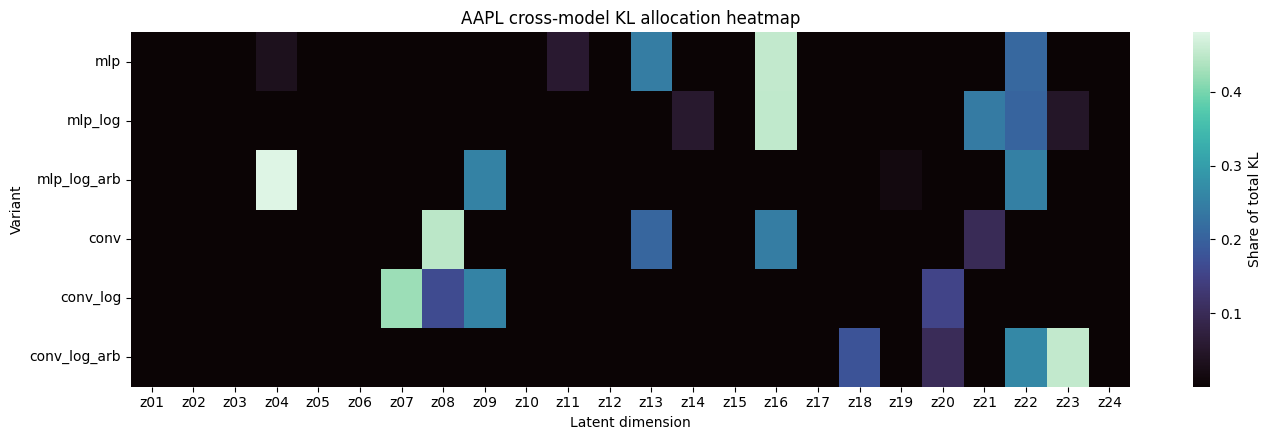

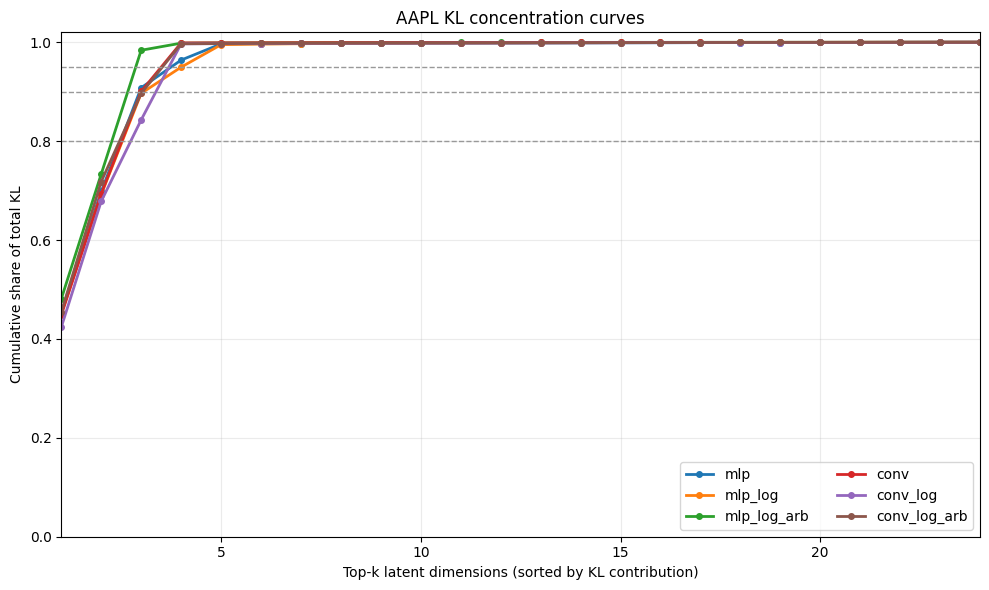

Saved per-dimension KL table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\kl_per_dim_AAPL.csv
Saved KL summary table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\kl_summary_AAPL.csv
Saved cumulative KL table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\kl_cumulative_AAPL.csv
Saved KL matrix to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\kl_matrix_AAPL.csv
Saved KL share matrix to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\kl_share_matrix_AAPL.csv
Saved KL bar panel to: C:\Users\Admin\OneDrive\Desktop\Fifth Y

,variant,latent_dim,mean_total_kl,std_total_kl,median_total_kl,p95_total_kl,effective_dimensionality_pr,dims_to_80pct_kl,dims_to_90pct_kl,dims_to_95pct_kl,dims_to_99pct_kl,top1_dim,top1_share,top3_share,top5_dims
0,mlp,24,4.758533,1.626888,4.341430,7.099128,3.188509,3,3,4,5,z16,0.453285,0.907897,"z16, z13, z22, z11, z04"
1,mlp_log,24,4.880884,1.029045,4.661118,6.532982,3.243135,3,4,5,5,z16,0.451277,0.896626,"z16, z21, z22, z14, z23"
2,mlp_log_arb,24,4.518875,1.061621,4.224535,6.207493,2.794203,3,3,3,4,z04,0.480860,0.983748,"z04, z09, z22, z19, z08"
3,conv,24,4.654660,1.588882,4.297456,7.120337,3.189977,3,3,4,4,z08,0.448140,0.900438,"z08, z16, z13, z21, z20"
4,conv_log,24,4.977323,1.028153,4.807950,6.907477,3.387956,3,4,4,4,z07,0.423774,0.842942,"z07, z09, z08, z20, z02"
5,conv_log_arb,24,4.744358,1.027537,4.497775,6.524345,3.145793,3,4,4,4,z23,0.454311,0.896506,"z23, z22, z18, z20, z07"


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
import matplotlib.pyplot as plt


def to_numpy(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().numpy()
    return np.asarray(value)


expected_dates = pd.to_datetime(features_df["date"]).dt.normalize().to_numpy()
kl_rows = []
summary_rows = []
cumulative_rows = []
variant_to_mean_kl = {}
variant_to_sorted_share = {}

for variant in VARIANTS:
    latent_path = EVAL_ROOT / variant / "test_latents.pt"
    payload = torch.load(latent_path, map_location="cpu", weights_only=False)

    mus = to_numpy(payload["mus"])
    logvars = to_numpy(payload["logvars"])
    latent_dates_variant = pd.to_datetime(pd.Series(payload["dates"])).dt.normalize().to_numpy()

    if mus.ndim != 2 or logvars.ndim != 2:
        raise ValueError(f"{variant}: expected 2D mus/logvars, got {mus.shape} and {logvars.shape}")
    if mus.shape != logvars.shape:
        raise ValueError(f"{variant}: mus/logvars shape mismatch: {mus.shape} vs {logvars.shape}")
    if latent_dates_variant.shape[0] != mus.shape[0]:
        raise ValueError(
            f"{variant}: date count {latent_dates_variant.shape[0]} does not match sample count {mus.shape[0]}"
        )
    if not np.array_equal(latent_dates_variant, expected_dates):
        raise ValueError(f"{variant}: latent dates are not aligned with feature dates")

    kl_per_sample_dim = 0.5 * (np.square(mus) + np.exp(logvars) - 1.0 - logvars)
    if not np.isfinite(kl_per_sample_dim).all():
        raise ValueError(f"{variant}: KL tensor contains NaN or inf values")

    mean_kl_per_dim = kl_per_sample_dim.mean(axis=0)
    total_kl_per_sample = kl_per_sample_dim.sum(axis=1)
    total_kl_mean = float(total_kl_per_sample.mean())
    total_kl_std = float(total_kl_per_sample.std(ddof=0))
    total_kl_median = float(np.median(total_kl_per_sample))
    total_kl_p95 = float(np.percentile(total_kl_per_sample, 95))
    denom = float(np.square(mean_kl_per_dim).sum())
    effective_dim_pr = float((total_kl_mean ** 2) / denom) if denom > 0 else 0.0

    sort_idx = np.argsort(mean_kl_per_dim)[::-1]
    sorted_mean_kl = mean_kl_per_dim[sort_idx]
    sorted_share = sorted_mean_kl / total_kl_mean if total_kl_mean > 0 else np.zeros_like(sorted_mean_kl)
    cumulative_share = np.cumsum(sorted_share)

    dims_to_80 = int(np.searchsorted(cumulative_share, 0.80) + 1) if total_kl_mean > 0 else 0
    dims_to_90 = int(np.searchsorted(cumulative_share, 0.90) + 1) if total_kl_mean > 0 else 0
    dims_to_95 = int(np.searchsorted(cumulative_share, 0.95) + 1) if total_kl_mean > 0 else 0
    dims_to_99 = int(np.searchsorted(cumulative_share, 0.99) + 1) if total_kl_mean > 0 else 0

    variant_to_mean_kl[variant] = mean_kl_per_dim
    variant_to_sorted_share[variant] = cumulative_share

    top_dims = [f"z{dim_idx + 1:02d}" for dim_idx in sort_idx[:5]]

    summary_rows.append(
        {
            "variant": variant,
            "latent_dim": int(mus.shape[1]),
            "mean_total_kl": total_kl_mean,
            "std_total_kl": total_kl_std,
            "median_total_kl": total_kl_median,
            "p95_total_kl": total_kl_p95,
            "effective_dimensionality_pr": effective_dim_pr,
            "dims_to_80pct_kl": dims_to_80,
            "dims_to_90pct_kl": dims_to_90,
            "dims_to_95pct_kl": dims_to_95,
            "dims_to_99pct_kl": dims_to_99,
            "top1_dim": f"z{sort_idx[0] + 1:02d}",
            "top1_share": float(sorted_share[0]) if sorted_share.size else 0.0,
            "top3_share": float(sorted_share[:3].sum()) if sorted_share.size else 0.0,
            "top5_dims": ", ".join(top_dims),
        }
    )

    dim_ranks = np.empty_like(sort_idx)
    dim_ranks[sort_idx] = np.arange(1, len(sort_idx) + 1)

    for dim_idx, mean_kl in enumerate(mean_kl_per_dim):
        share = float(mean_kl / total_kl_mean) if total_kl_mean > 0 else 0.0
        kl_rows.append(
            {
                "variant": variant,
                "latent_dim_idx": int(dim_idx),
                "latent_dim_label": f"z{dim_idx + 1:02d}",
                "mean_kl": float(mean_kl),
                "share_of_total_kl": share,
                "rank_within_variant": int(dim_ranks[dim_idx]),
            }
        )

    for rank, dim_idx in enumerate(sort_idx, start=1):
        cumulative_rows.append(
            {
                "variant": variant,
                "rank": rank,
                "latent_dim_idx": int(dim_idx),
                "latent_dim_label": f"z{dim_idx + 1:02d}",
                "mean_kl": float(sorted_mean_kl[rank - 1]),
                "share_of_total_kl": float(sorted_share[rank - 1]),
                "cumulative_share_of_total_kl": float(cumulative_share[rank - 1]),
            }
        )

kl_df = pd.DataFrame(kl_rows).sort_values(["variant", "rank_within_variant", "latent_dim_idx"]).reset_index(drop=True)
summary_df = pd.DataFrame(summary_rows).set_index("variant").loc[VARIANTS].reset_index()
cumulative_df = (
    pd.DataFrame(cumulative_rows)
    .sort_values(["variant", "rank"])
    .reset_index(drop=True)
)

kl_wide = (
    kl_df.pivot(index="variant", columns="latent_dim_label", values="mean_kl")
    .reindex(VARIANTS)
)
share_wide = (
    kl_df.pivot(index="variant", columns="latent_dim_label", values="share_of_total_kl")
    .reindex(VARIANTS)
)

kl_csv = TABLES_DIR / f"kl_per_dim_{TICKER}.csv"
summary_csv = TABLES_DIR / f"kl_summary_{TICKER}.csv"
cumulative_csv = TABLES_DIR / f"kl_cumulative_{TICKER}.csv"
kl_matrix_csv = TABLES_DIR / f"kl_matrix_{TICKER}.csv"
share_matrix_csv = TABLES_DIR / f"kl_share_matrix_{TICKER}.csv"

kl_df.to_csv(kl_csv, index=False)
summary_df.to_csv(summary_csv, index=False)
cumulative_df.to_csv(cumulative_csv, index=False)
kl_wide.to_csv(kl_matrix_csv)
share_wide.to_csv(share_matrix_csv)

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
bar_color = sns.color_palette("deep", n_colors=1)[0]
for ax, variant in zip(axes.flat, VARIANTS):
    mean_kl = variant_to_mean_kl[variant]
    labels = [f"z{dim_idx + 1:02d}" for dim_idx in range(len(mean_kl))]
    ax.bar(np.arange(len(mean_kl)), mean_kl, color=bar_color, width=0.8)
    ax.set_title(variant)
    ax.set_xticks(np.arange(len(mean_kl)))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.grid(axis="y", alpha=0.25)
    variant_summary = summary_df.loc[summary_df["variant"] == variant].iloc[0]
    ax.text(
        0.99,
        0.95,
        (
            f"mean KL={variant_summary['mean_total_kl']:.3f}\n"
            f"PR eff dim={variant_summary['effective_dimensionality_pr']:.2f}\n"
            f"80% in {int(variant_summary['dims_to_80pct_kl'])} dims"
        ),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
    )
for ax in axes[:, 0]:
    ax.set_ylabel("Mean KL per dimension")
for ax in axes[-1, :]:
    ax.set_xlabel("Latent dimension")
fig.suptitle(f"{TICKER} latent KL allocation by variant", fontsize=14)
fig.tight_layout()
bar_plot_path = PLOTS_DIR / f"kl_per_dim_panel_{TICKER}.png"
fig.savefig(bar_plot_path, dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(14, 4.5))
sns.heatmap(share_wide, cmap="mako", cbar_kws={"label": "Share of total KL"}, ax=ax)
ax.set_title(f"{TICKER} cross-model KL allocation heatmap")
ax.set_xlabel("Latent dimension")
ax.set_ylabel("Variant")
heatmap_path = PLOTS_DIR / f"kl_heatmap_{TICKER}.png"
fig.tight_layout()
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for variant in VARIANTS:
    cumulative_share = variant_to_sorted_share[variant]
    ax.plot(
        np.arange(1, len(cumulative_share) + 1),
        cumulative_share,
        marker="o",
        linewidth=2,
        markersize=4,
        label=variant,
    )
for y in [0.80, 0.90, 0.95]:
    ax.axhline(y, linestyle="--", linewidth=1, color="0.6")
ax.set_xlim(1, len(next(iter(variant_to_sorted_share.values()))))
ax.set_ylim(0, 1.02)
ax.set_xlabel("Top-k latent dimensions (sorted by KL contribution)")
ax.set_ylabel("Cumulative share of total KL")
ax.set_title(f"{TICKER} KL concentration curves")
ax.legend(loc="lower right", ncol=2)
ax.grid(alpha=0.25)
cumulative_plot_path = PLOTS_DIR / f"kl_cumulative_{TICKER}.png"
fig.tight_layout()
fig.savefig(cumulative_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved per-dimension KL table to: {kl_csv}")
print(f"Saved KL summary table to: {summary_csv}")
print(f"Saved cumulative KL table to: {cumulative_csv}")
print(f"Saved KL matrix to: {kl_matrix_csv}")
print(f"Saved KL share matrix to: {share_matrix_csv}")
print(f"Saved KL bar panel to: {bar_plot_path}")
print(f"Saved KL heatmap to: {heatmap_path}")
print(f"Saved KL cumulative plot to: {cumulative_plot_path}")

summary_df

## 3. PCA on Latent Means

This block measures the global geometry of the latent means on unseen AAPL test dates.
It saves per-variant scree summaries, cumulative explained-variance tables, top-3 PC scores,
and top-3 PC loading tables for later regime coloring and PC-based traversal analysis.

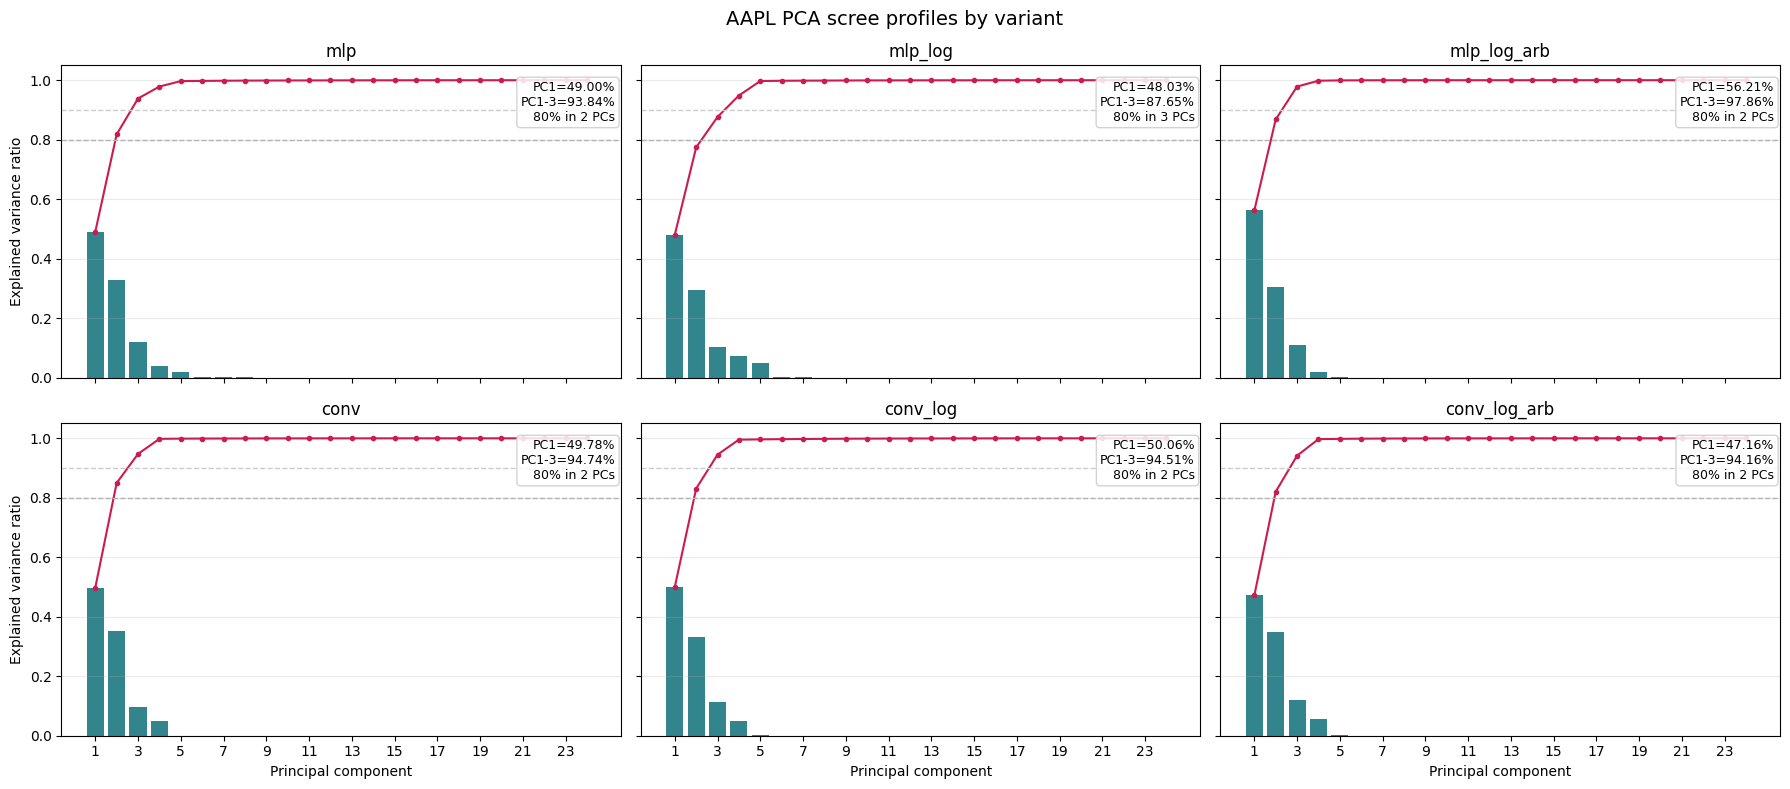

Saved PCA variance table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\pca_explained_variance_AAPL.csv
Saved PCA summary table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\pca_summary_AAPL.csv
Saved PCA top-3 score table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\pca_scores_top3_AAPL.csv
Saved PCA top-3 loading table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\pca_loadings_top3_AAPL.csv
Saved PCA scree plot panel to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\pca_scree_panel_AAPL.png


,variant,latent_dim,pc1_explained_variance_ratio,pc2_explained_variance_ratio,pc3_explained_variance_ratio,pc1_to_pc3_cumulative_ratio,pcs_to_80pct_variance,pcs_to_90pct_variance,pcs_to_95pct_variance
0,mlp,24,0.490034,0.327694,0.120687,0.938415,2,3,4
1,mlp_log,24,0.480289,0.293910,0.102296,0.876494,3,4,5
2,mlp_log_arb,24,0.562065,0.305977,0.110524,0.978565,2,3,3
3,conv,24,0.497822,0.351880,0.097713,0.947416,2,3,4
4,conv_log,24,0.500596,0.330620,0.113892,0.945108,2,3,4
5,conv_log_arb,24,0.471635,0.349047,0.120931,0.941613,2,3,4


In [7]:
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


def to_numpy_local(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().numpy()
    return np.asarray(value)


expected_dates = pd.to_datetime(features_df["date"]).dt.normalize()
feature_frame = features_df.copy()
feature_frame["date"] = expected_dates

pca_variance_rows = []
pca_summary_rows = []
pca_score_frames = []
pca_loading_rows = []

for variant in VARIANTS:
    latent_path = EVAL_ROOT / variant / "test_latents.pt"
    payload = torch.load(latent_path, map_location="cpu", weights_only=False)

    mus = to_numpy_local(payload["mus"])
    latent_dates_variant = pd.to_datetime(pd.Series(payload["dates"])).dt.normalize()

    if mus.ndim != 2:
        raise ValueError(f"{variant}: expected 2D latent means, got {mus.shape}")
    if latent_dates_variant.shape[0] != mus.shape[0]:
        raise ValueError(
            f"{variant}: date count {latent_dates_variant.shape[0]} does not match sample count {mus.shape[0]}"
        )
    if not latent_dates_variant.equals(expected_dates):
        raise ValueError(f"{variant}: latent dates are not aligned with feature dates")

    pca = PCA(n_components=mus.shape[1])
    scores = pca.fit_transform(mus)
    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    pcs_to_80 = int(np.searchsorted(cumulative, 0.80) + 1)
    pcs_to_90 = int(np.searchsorted(cumulative, 0.90) + 1)
    pcs_to_95 = int(np.searchsorted(cumulative, 0.95) + 1)

    pca_summary_rows.append(
        {
            "variant": variant,
            "latent_dim": int(mus.shape[1]),
            "pc1_explained_variance_ratio": float(explained[0]),
            "pc2_explained_variance_ratio": float(explained[1]),
            "pc3_explained_variance_ratio": float(explained[2]),
            "pc1_to_pc3_cumulative_ratio": float(cumulative[2]),
            "pcs_to_80pct_variance": pcs_to_80,
            "pcs_to_90pct_variance": pcs_to_90,
            "pcs_to_95pct_variance": pcs_to_95,
        }
    )

    for pc_idx, (ratio, cum_ratio) in enumerate(zip(explained, cumulative), start=1):
        pca_variance_rows.append(
            {
                "variant": variant,
                "pc": f"PC{pc_idx}",
                "pc_idx": pc_idx,
                "explained_variance_ratio": float(ratio),
                "cumulative_explained_variance_ratio": float(cum_ratio),
            }
        )

    score_frame = pd.DataFrame(
        {
            "date": expected_dates,
            "variant": variant,
            "PC1": scores[:, 0],
            "PC2": scores[:, 1],
            "PC3": scores[:, 2],
        }
    )
    score_frame = score_frame.merge(feature_frame, on="date", how="left", validate="one_to_one")
    pca_score_frames.append(score_frame)

    for pc_idx in range(3):
        for dim_idx, loading in enumerate(pca.components_[pc_idx]):
            pca_loading_rows.append(
                {
                    "variant": variant,
                    "pc": f"PC{pc_idx + 1}",
                    "pc_idx": pc_idx + 1,
                    "latent_dim_idx": dim_idx,
                    "latent_dim_label": f"z{dim_idx + 1:02d}",
                    "loading": float(loading),
                    "abs_loading": float(abs(loading)),
                }
            )

pca_variance_df = pd.DataFrame(pca_variance_rows).sort_values(["variant", "pc_idx"]).reset_index(drop=True)
pca_summary_df = pd.DataFrame(pca_summary_rows).set_index("variant").loc[VARIANTS].reset_index()
pca_scores_df = pd.concat(pca_score_frames, ignore_index=True)
pca_loadings_df = pd.DataFrame(pca_loading_rows).sort_values(["variant", "pc_idx", "abs_loading"], ascending=[True, True, False]).reset_index(drop=True)

pca_variance_csv = TABLES_DIR / f"pca_explained_variance_{TICKER}.csv"
pca_summary_csv = TABLES_DIR / f"pca_summary_{TICKER}.csv"
pca_scores_csv = TABLES_DIR / f"pca_scores_top3_{TICKER}.csv"
pca_loadings_csv = TABLES_DIR / f"pca_loadings_top3_{TICKER}.csv"

pca_variance_df.to_csv(pca_variance_csv, index=False)
pca_summary_df.to_csv(pca_summary_csv, index=False)
pca_scores_df.to_csv(pca_scores_csv, index=False)
pca_loadings_df.to_csv(pca_loadings_csv, index=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
bar_color = sns.color_palette("crest", n_colors=1)[0]
line_color = sns.color_palette("rocket", n_colors=1)[0]
for ax, variant in zip(axes.flat, VARIANTS):
    sub = pca_variance_df[pca_variance_df["variant"] == variant]
    x = sub["pc_idx"].to_numpy()
    ax.bar(x, sub["explained_variance_ratio"], color=bar_color, width=0.8)
    ax.plot(x, sub["cumulative_explained_variance_ratio"], color=line_color, marker="o", linewidth=1.5, markersize=3)
    ax.axhline(0.80, linestyle="--", linewidth=1, color="0.7")
    ax.axhline(0.90, linestyle="--", linewidth=1, color="0.8")
    ax.set_title(variant)
    ax.set_xticks(np.arange(1, len(x) + 1, 2))
    ax.grid(axis="y", alpha=0.25)
    variant_summary = pca_summary_df.loc[pca_summary_df["variant"] == variant].iloc[0]
    ax.text(
        0.99,
        0.95,
        (
            f"PC1={variant_summary['pc1_explained_variance_ratio']:.2%}\n"
            f"PC1-3={variant_summary['pc1_to_pc3_cumulative_ratio']:.2%}\n"
            f"80% in {int(variant_summary['pcs_to_80pct_variance'])} PCs"
        ),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
    )
for ax in axes[:, 0]:
    ax.set_ylabel("Explained variance ratio")
for ax in axes[-1, :]:
    ax.set_xlabel("Principal component")
fig.suptitle(f"{TICKER} PCA scree profiles by variant", fontsize=14)
fig.tight_layout()
pca_plot_path = PLOTS_DIR / f"pca_scree_panel_{TICKER}.png"
fig.savefig(pca_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved PCA variance table to: {pca_variance_csv}")
print(f"Saved PCA summary table to: {pca_summary_csv}")
print(f"Saved PCA top-3 score table to: {pca_scores_csv}")
print(f"Saved PCA top-3 loading table to: {pca_loadings_csv}")
print(f"Saved PCA scree plot panel to: {pca_plot_path}")

display(pca_summary_df)

## 4. PCA Score Geometry vs Market Features

This block visualizes the top-3 PCA score cloud for each variant and colors it by three core
surface features: level, skew, and term structure. It also exports simple PC-feature
correlations so the interpretation is not purely visual.

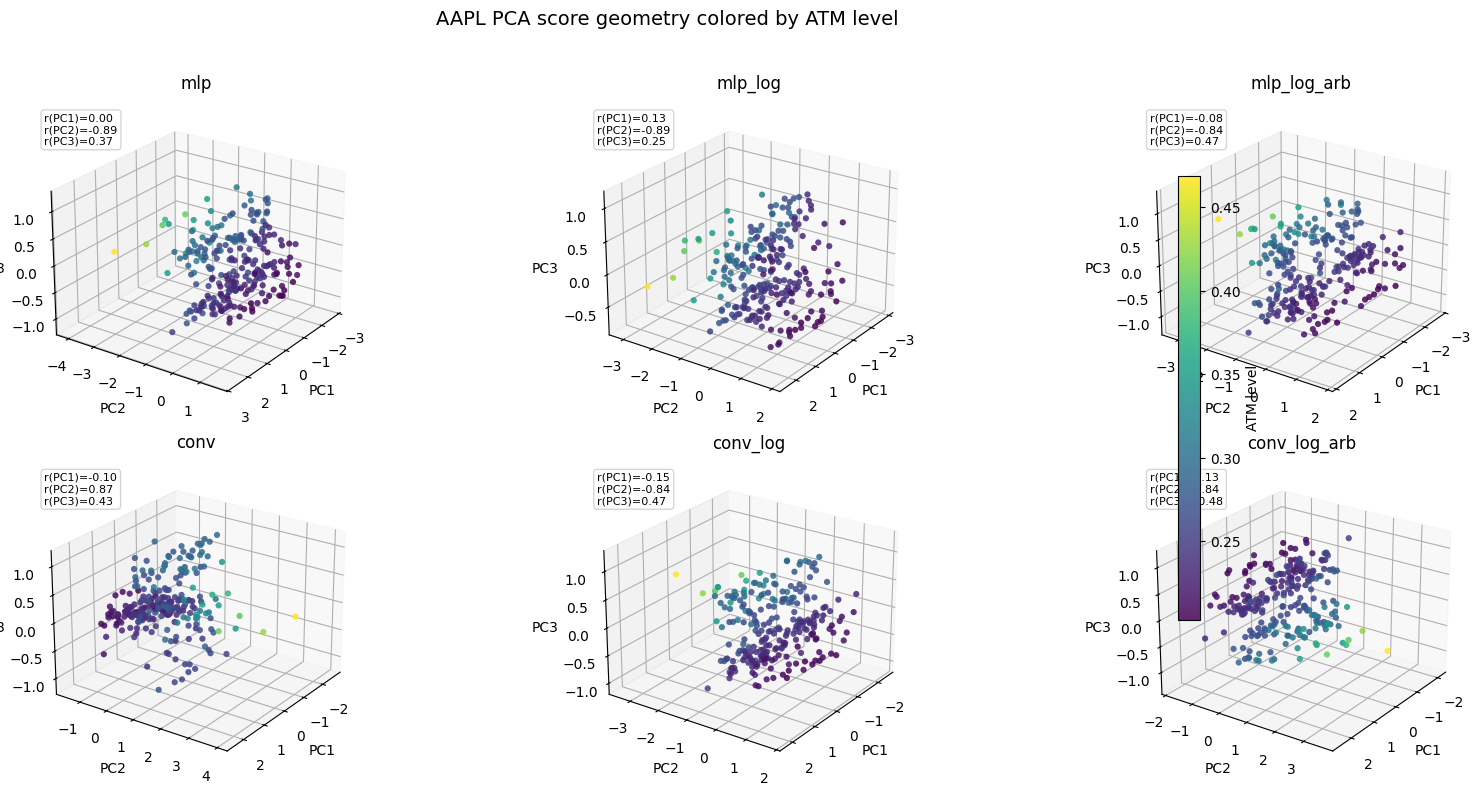

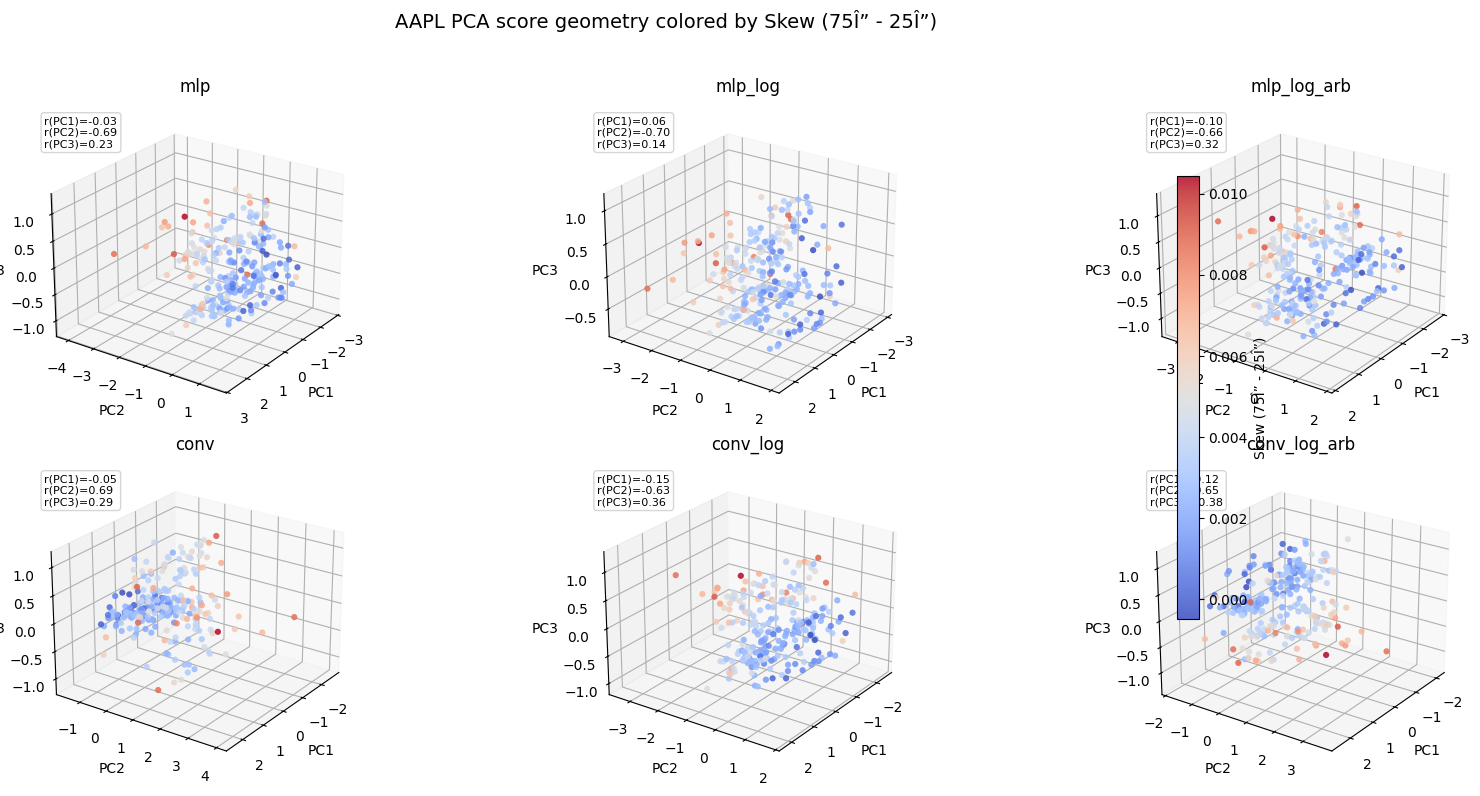

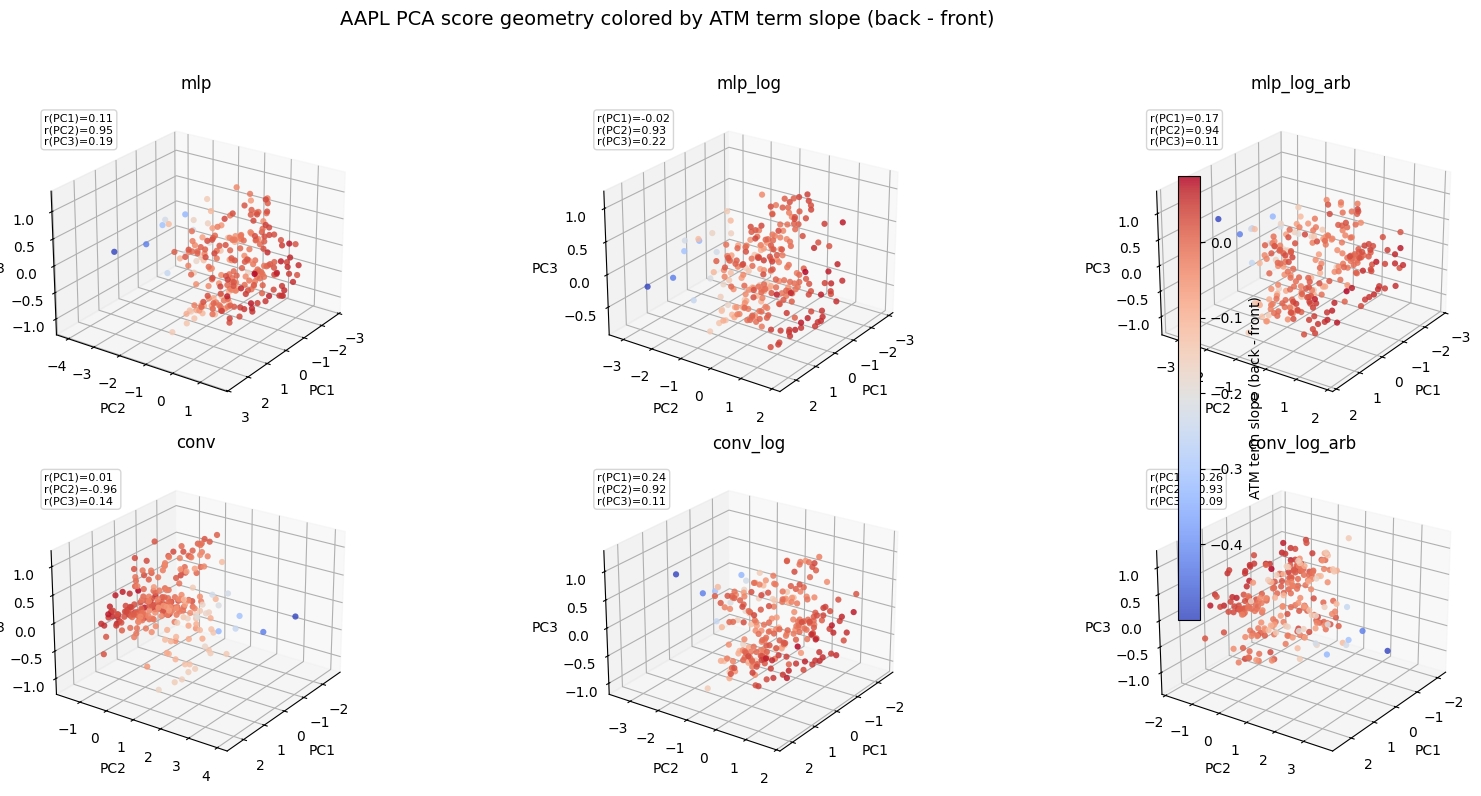

Saved PCA-feature correlation table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\pca_feature_correlations_AAPL.csv
Saved PCA-feature best-axis summary to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\pca_feature_best_axis_AAPL.csv
Saved PCA feature scatter plot to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\pca_pc123_scatter_atm_level_delta50_mean_AAPL.png
Saved PCA feature scatter plot to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\pca_pc123_scatter_skew_75_minus_25_mean_AAPL.png
Saved PCA feature scatter plot to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifac

feature_label,ATM level,ATM term slope (back - front),Skew (75Δ - 25Δ)
variant,,,
mlp,PC2 (-0.89),PC2 (+0.95),PC2 (-0.69)
mlp_log,PC2 (-0.89),PC2 (+0.93),PC2 (-0.70)
mlp_log_arb,PC2 (-0.84),PC2 (+0.94),PC2 (-0.66)
conv,PC2 (+0.87),PC2 (-0.96),PC2 (+0.69)
conv_log,PC2 (-0.84),PC2 (+0.92),PC2 (-0.63)
conv_log_arb,PC2 (+0.84),PC2 (-0.93),PC2 (+0.65)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "pca_scores_df" not in globals():
    raise RuntimeError("pca_scores_df is not available. Run the PCA block first.")

feature_specs = [
    ("atm_level_delta50_mean", "ATM level", "viridis"),
    ("skew_75_minus_25_mean", "Skew (75Δ - 25Δ)", "coolwarm"),
    ("term_slope_back_minus_front_atm", "ATM term slope (back - front)", "coolwarm"),
]

pca_feature_corr_rows = []
plot_paths = []

for feature_col, feature_label, cmap in feature_specs:
    if feature_col not in pca_scores_df.columns:
        raise KeyError(f"Missing required PCA feature column: {feature_col}")

    feature_values = pca_scores_df[feature_col].to_numpy()
    if not np.isfinite(feature_values).all():
        raise ValueError(f"Feature column {feature_col} contains NaN or inf values")

    norm = plt.Normalize(vmin=float(feature_values.min()), vmax=float(feature_values.max()))
    fig, axes = plt.subplots(2, 3, figsize=(18, 8), subplot_kw={"projection": "3d"})
    last_scatter = None

    for ax, variant in zip(axes.flat, VARIANTS):
        sub = pca_scores_df[pca_scores_df["variant"] == variant].copy()
        if sub.empty:
            raise ValueError(f"No PCA scores found for variant {variant}")

        corr_pc1 = float(np.corrcoef(sub["PC1"], sub[feature_col])[0, 1])
        corr_pc2 = float(np.corrcoef(sub["PC2"], sub[feature_col])[0, 1])
        corr_pc3 = float(np.corrcoef(sub["PC3"], sub[feature_col])[0, 1])
        pca_feature_corr_rows.append(
            {
                "variant": variant,
                "feature": feature_col,
                "feature_label": feature_label,
                "corr_pc1": corr_pc1,
                "corr_pc2": corr_pc2,
                "corr_pc3": corr_pc3,
            }
        )

        last_scatter = ax.scatter(
            sub["PC1"],
            sub["PC2"],
            sub["PC3"],
            c=sub[feature_col],
            cmap=cmap,
            norm=norm,
            s=20,
            alpha=0.85,
            edgecolor="none",
        )
        ax.view_init(elev=24, azim=35)
        ax.set_title(variant)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")
        ax.text2D(
            0.03,
            0.95,
            f"r(PC1)={corr_pc1:.2f}\nr(PC2)={corr_pc2:.2f}\nr(PC3)={corr_pc3:.2f}",
            transform=ax.transAxes,
            fontsize=8,
            va="top",
            bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8, "edgecolor": "0.8"},
        )

    cbar = fig.colorbar(last_scatter, ax=axes.ravel().tolist(), shrink=0.72, pad=0.04)
    cbar.set_label(feature_label)
    fig.suptitle(f"{TICKER} PCA score geometry colored by {feature_label}", fontsize=14)
    fig.tight_layout(rect=[0, 0, 0.95, 0.96])

    plot_path = PLOTS_DIR / f"pca_pc123_scatter_{feature_col}_{TICKER}.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plot_paths.append(plot_path)
    plt.show()

pca_feature_corr_df = pd.DataFrame(pca_feature_corr_rows).sort_values(["feature", "variant"]).reset_index(drop=True)
pca_feature_corr_csv = TABLES_DIR / f"pca_feature_correlations_{TICKER}.csv"
pca_feature_corr_df.to_csv(pca_feature_corr_csv, index=False)

best_axis_rows = []
for row in pca_feature_corr_df.itertuples(index=False):
    corr_map = {"PC1": row.corr_pc1, "PC2": row.corr_pc2, "PC3": row.corr_pc3}
    best_pc, best_corr = max(corr_map.items(), key=lambda item: abs(item[1]))
    best_axis_rows.append(
        {
            "variant": row.variant,
            "feature": row.feature,
            "feature_label": row.feature_label,
            "best_pc": best_pc,
            "signed_corr": float(best_corr),
            "abs_corr": float(abs(best_corr)),
        }
    )

best_axis_df = pd.DataFrame(best_axis_rows).sort_values(["feature", "variant"]).reset_index(drop=True)
best_axis_csv = TABLES_DIR / f"pca_feature_best_axis_{TICKER}.csv"
best_axis_df.to_csv(best_axis_csv, index=False)

best_axis_display = best_axis_df.copy()
best_axis_display["best_axis_summary"] = best_axis_display.apply(
    lambda row: f"{row['best_pc']} ({row['signed_corr']:+.2f})",
    axis=1,
)
best_axis_pivot = (
    best_axis_display.pivot(index="variant", columns="feature_label", values="best_axis_summary")
    .reindex(VARIANTS)
)

print(f"Saved PCA-feature correlation table to: {pca_feature_corr_csv}")
print(f"Saved PCA-feature best-axis summary to: {best_axis_csv}")
for plot_path in plot_paths:
    print(f"Saved PCA feature scatter plot to: {plot_path}")

display(best_axis_pivot)

## 5. Latent Dimensions vs Market Features

This block correlates each latent mean dimension directly with the engineered market features.
It exports full correlation tables, a best-match summary per feature, and a panel of signed
heatmaps so we can see whether specific latent coordinates look like financial factors.

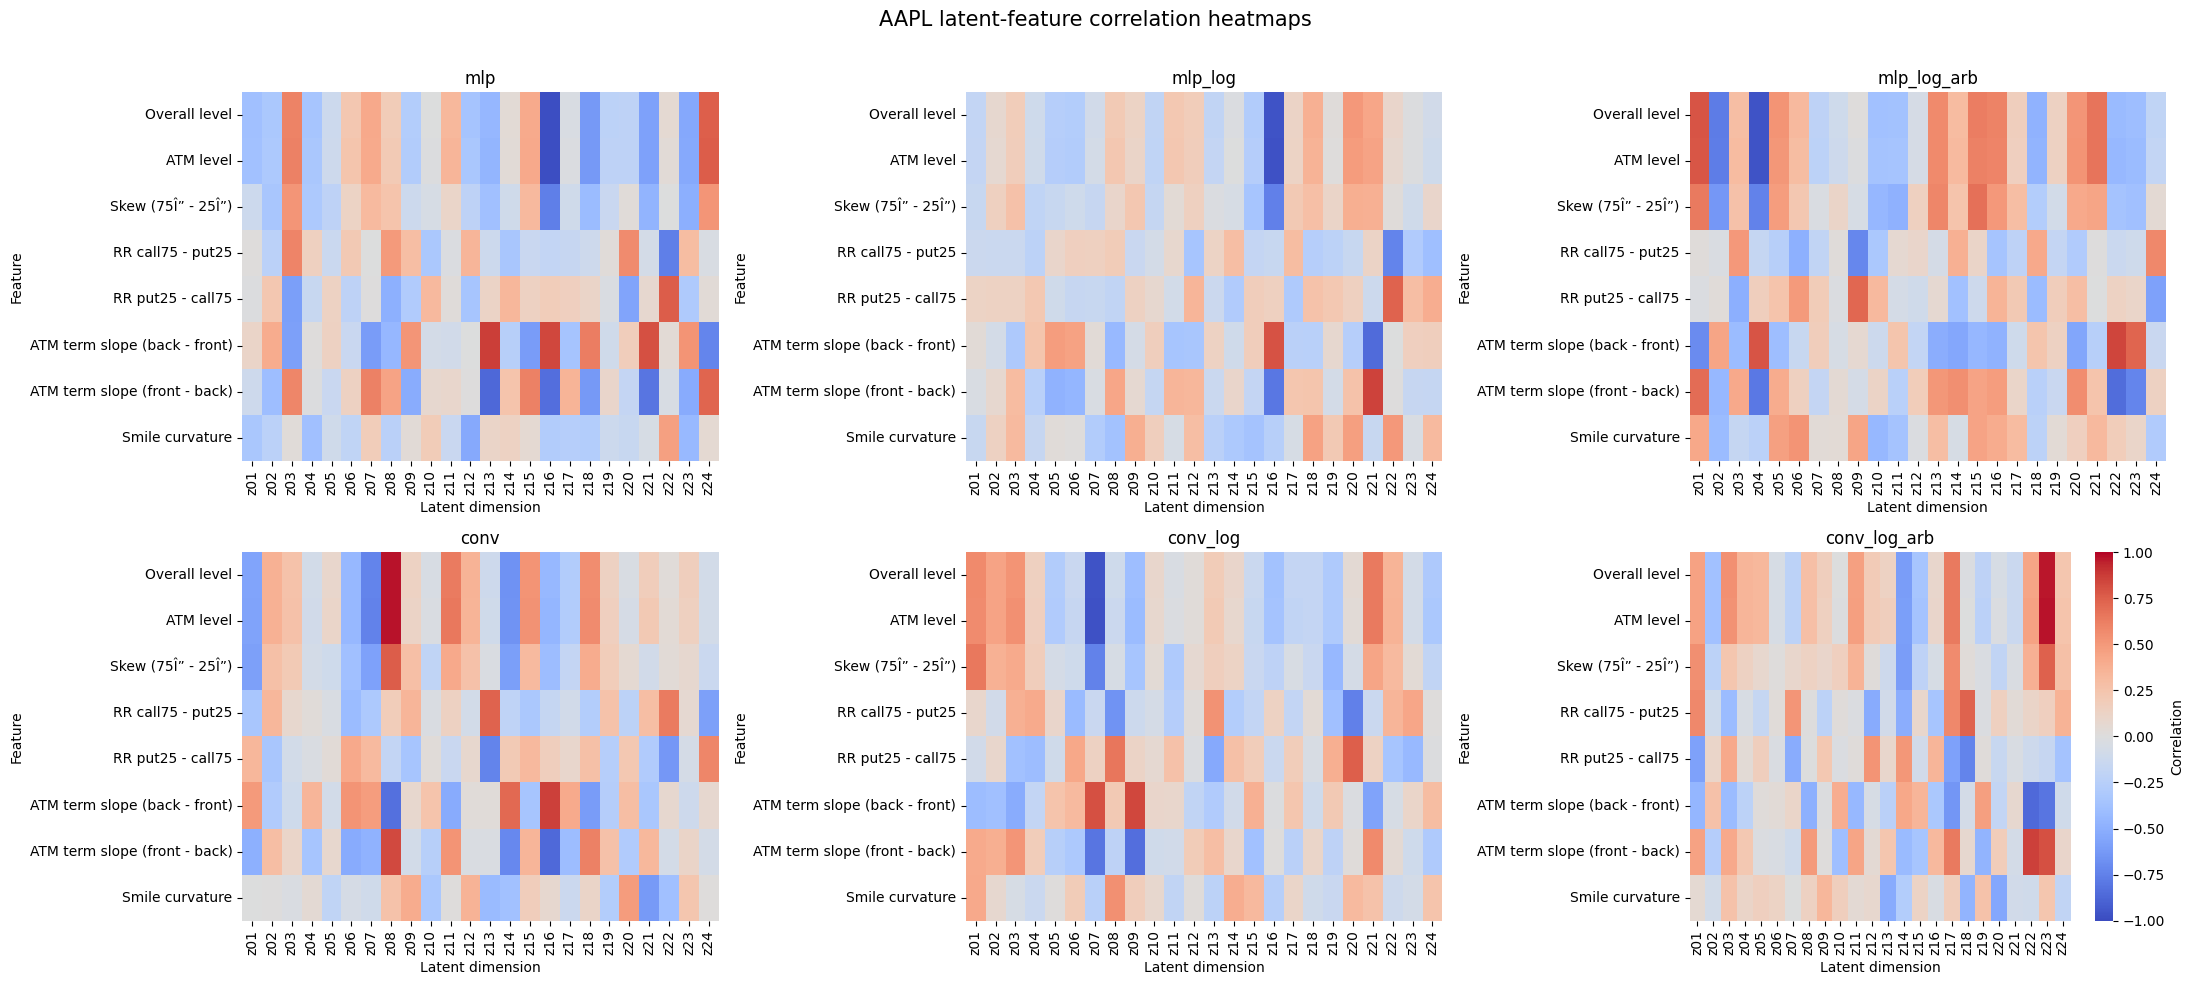

Saved latent-feature correlation table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\latent_feature_correlations_AAPL.csv
Saved latent-feature best-match table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\latent_feature_best_match_AAPL.csv
Saved latent-feature heatmap panel to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_feature_correlation_heatmaps_AAPL.png


feature_label,ATM level,ATM term slope (back - front),ATM term slope (front - back),Overall level,RR call75 - put25,RR put25 - call75,Skew (75Δ - 25Δ),Smile curvature
variant,,,,,,,,
mlp,z16 (-0.99),z13 (+0.87),z13 (-0.87),z16 (-0.98),z22 (-0.76),z22 (+0.76),z16 (-0.76),z12 (-0.53)
mlp_log,z16 (-0.97),z21 (-0.85),z21 (+0.85),z16 (-0.97),z22 (-0.74),z22 (+0.74),z16 (-0.75),z22 (+0.50)
mlp_log_arb,z04 (-0.97),z22 (+0.85),z22 (-0.85),z04 (-0.96),z09 (-0.72),z09 (+0.72),z04 (-0.75),z06 (+0.52)
conv,z08 (+0.98),z16 (+0.86),z16 (-0.86),z08 (+0.97),z13 (+0.74),z13 (-0.74),z08 (+0.77),z21 (-0.62)
conv_log,z07 (-0.97),z09 (+0.84),z09 (-0.84),z07 (-0.97),z20 (-0.75),z20 (+0.75),z07 (-0.75),z08 (+0.54)
conv_log_arb,z23 (+0.97),z22 (-0.86),z22 (+0.86),z23 (+0.97),z18 (+0.73),z18 (-0.73),z23 (+0.75),z20 (-0.55)


In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt

feature_cols = [
    "overall_level",
    "atm_level_delta50_mean",
    "skew_75_minus_25_mean",
    "rr_call75_minus_put25",
    "rr_put25_minus_call75",
    "term_slope_back_minus_front_atm",
    "term_slope_front_minus_back_atm",
    "smile_curvature_quad_mean",
]
feature_labels = {
    "overall_level": "Overall level",
    "atm_level_delta50_mean": "ATM level",
    "skew_75_minus_25_mean": "Skew (75Δ - 25Δ)",
    "rr_call75_minus_put25": "RR call75 - put25",
    "rr_put25_minus_call75": "RR put25 - call75",
    "term_slope_back_minus_front_atm": "ATM term slope (back - front)",
    "term_slope_front_minus_back_atm": "ATM term slope (front - back)",
    "smile_curvature_quad_mean": "Smile curvature",
}

feature_frame = features_df.copy()
feature_frame["date"] = pd.to_datetime(feature_frame["date"]).dt.normalize()
expected_dates = feature_frame["date"]

corr_rows = []
for variant in VARIANTS:
    latent_path = EVAL_ROOT / variant / "test_latents.pt"
    payload = torch.load(latent_path, map_location="cpu", weights_only=False)
    mus = payload["mus"].detach().cpu().numpy() if isinstance(payload["mus"], torch.Tensor) else np.asarray(payload["mus"])
    latent_dates_variant = pd.to_datetime(pd.Series(payload["dates"])).dt.normalize()

    if mus.ndim != 2:
        raise ValueError(f"{variant}: expected 2D latent means, got {mus.shape}")
    if not latent_dates_variant.equals(expected_dates):
        raise ValueError(f"{variant}: latent dates are not aligned with market feature dates")

    for dim_idx in range(mus.shape[1]):
        latent_values = mus[:, dim_idx]
        latent_std = float(np.std(latent_values))
        for feature_col in feature_cols:
            feature_values = feature_frame[feature_col].to_numpy()
            feature_std = float(np.std(feature_values))
            if feature_std == 0.0:
                raise ValueError(f"Feature {feature_col} has zero variance; correlation is undefined")
            if latent_std == 0.0:
                corr = 0.0
            else:
                corr = float(np.corrcoef(latent_values, feature_values)[0, 1])
            corr_rows.append(
                {
                    "variant": variant,
                    "latent_dim_idx": dim_idx,
                    "latent_dim_label": f"z{dim_idx + 1:02d}",
                    "feature": feature_col,
                    "feature_label": feature_labels[feature_col],
                    "correlation": corr,
                    "abs_correlation": abs(corr),
                }
            )

latent_feature_corr_df = pd.DataFrame(corr_rows).sort_values(
    ["variant", "feature", "abs_correlation"], ascending=[True, True, False]
).reset_index(drop=True)
latent_feature_corr_csv = TABLES_DIR / f"latent_feature_correlations_{TICKER}.csv"
latent_feature_corr_df.to_csv(latent_feature_corr_csv, index=False)

best_match_df = (
    latent_feature_corr_df.groupby(["variant", "feature", "feature_label"], as_index=False)
    .first()
    .sort_values(["feature", "variant"])
    .reset_index(drop=True)
)
best_match_csv = TABLES_DIR / f"latent_feature_best_match_{TICKER}.csv"
best_match_df.to_csv(best_match_csv, index=False)

fig, axes = plt.subplots(2, 3, figsize=(22, 10))
feature_order = [feature_labels[col] for col in feature_cols]
for ax, variant in zip(axes.flat, VARIANTS):
    matrix = (
        latent_feature_corr_df[latent_feature_corr_df["variant"] == variant]
        .pivot(index="feature_label", columns="latent_dim_label", values="correlation")
        .reindex(feature_order)
    )
    sns.heatmap(
        matrix,
        cmap="coolwarm",
        center=0.0,
        vmin=-1.0,
        vmax=1.0,
        ax=ax,
        cbar=ax is axes.flat[-1],
        cbar_kws={"label": "Correlation"},
    )
    ax.set_title(variant)
    ax.set_xlabel("Latent dimension")
    ax.set_ylabel("Feature")

fig.suptitle(f"{TICKER} latent-feature correlation heatmaps", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.97])
heatmap_path = PLOTS_DIR / f"latent_feature_correlation_heatmaps_{TICKER}.png"
fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

best_match_display = best_match_df.copy()
best_match_display["best_match"] = best_match_display.apply(
    lambda row: f"{row['latent_dim_label']} ({row['correlation']:+.2f})",
    axis=1,
)
best_match_pivot = (
    best_match_display.pivot(index="variant", columns="feature_label", values="best_match")
    .reindex(VARIANTS)
)

print(f"Saved latent-feature correlation table to: {latent_feature_corr_csv}")
print(f"Saved latent-feature best-match table to: {best_match_csv}")
print(f"Saved latent-feature heatmap panel to: {heatmap_path}")

display(best_match_pivot)

## 6. Regime-Labeled Nonlinear Embeddings (t-SNE / UMAP)

This block builds ATM-level regime labels using terciles and visualizes nonlinear embeddings of
latent means for each variant. It exports per-date 2D coordinates for both t-SNE and UMAP to
support downstream clustering and narrative checks.

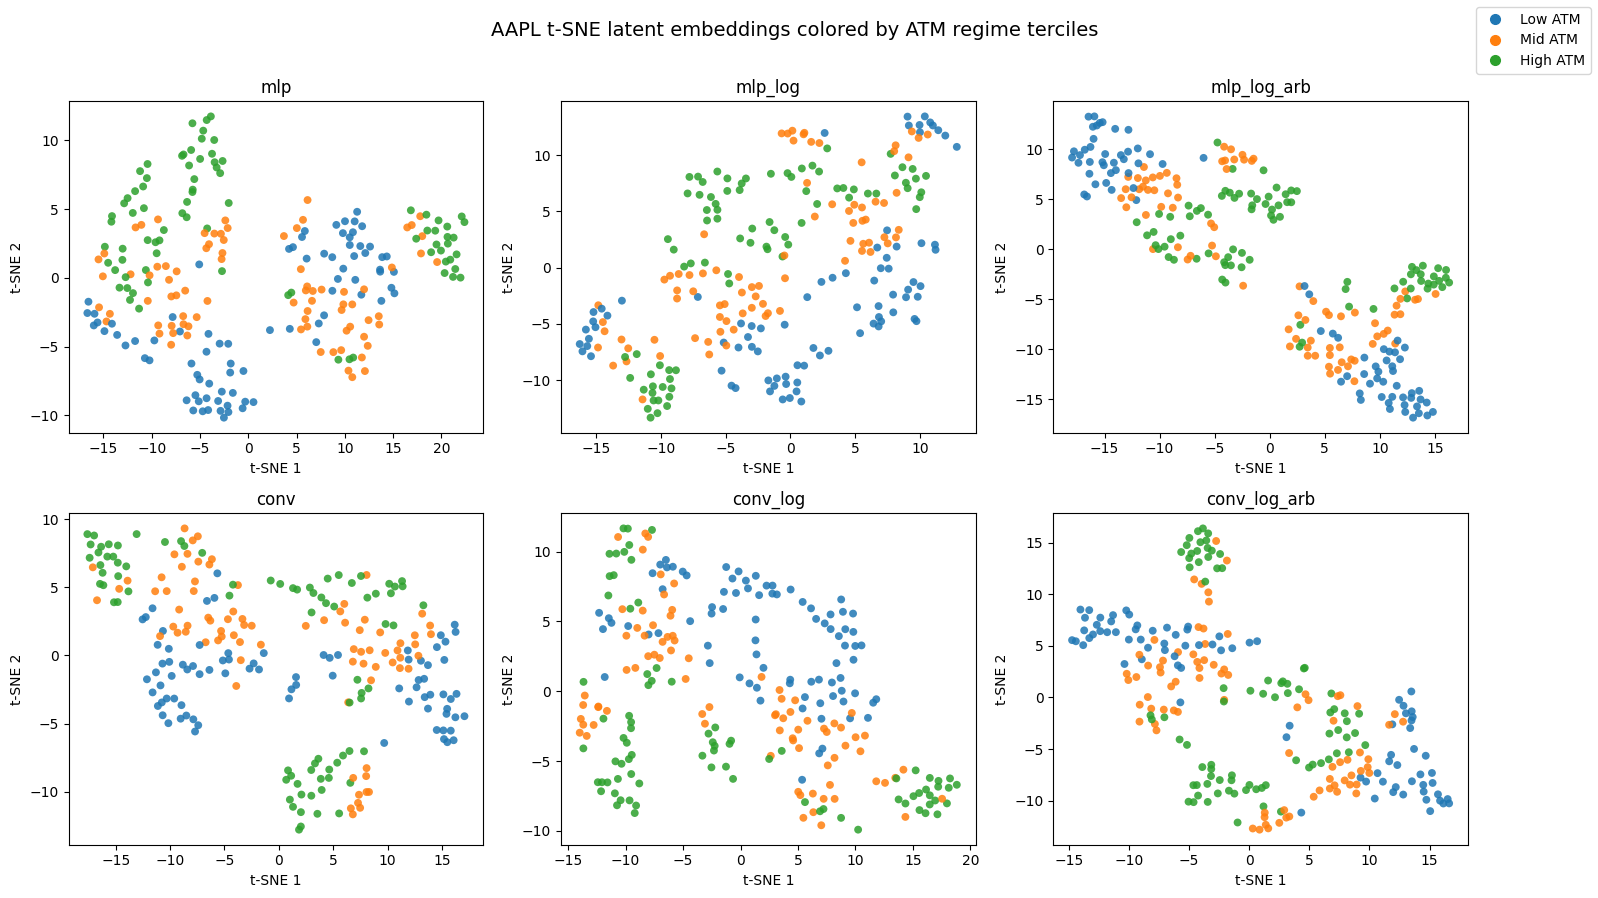

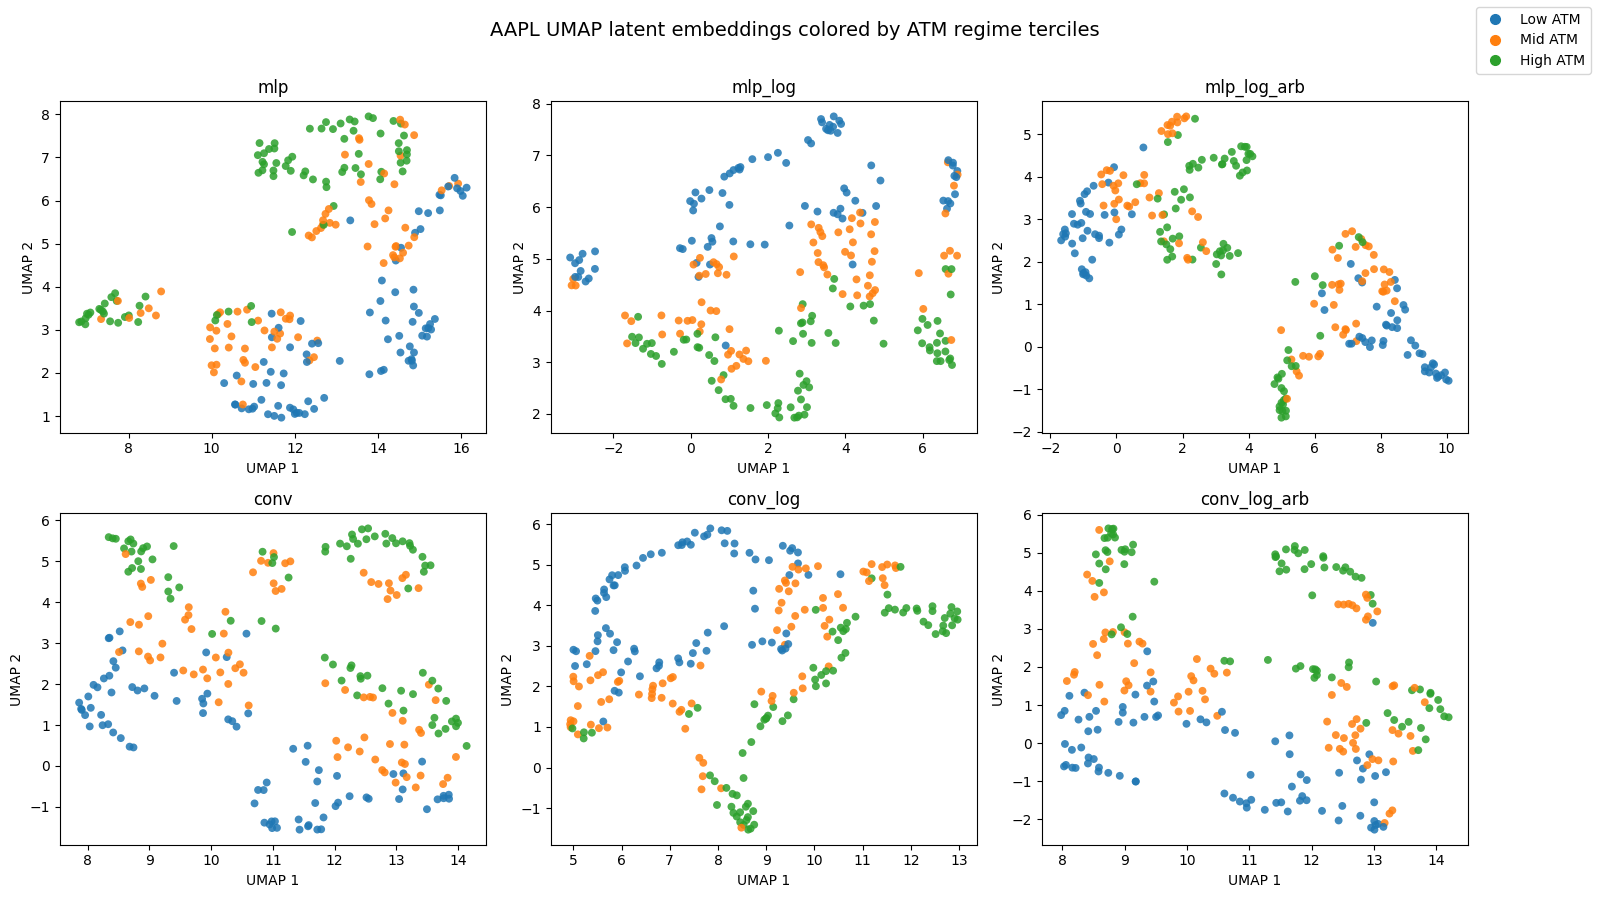

ATM tercile thresholds: q1=0.2386, q2=0.2688
Saved regime embedding table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\latent_regime_embeddings_AAPL.csv
Saved regime embedding plot to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_tsne_regimes_AAPL.png
Saved regime embedding plot to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_umap_regimes_AAPL.png


,count
atm_regime_tercile,
Low ATM,82
Mid ATM,81
High ATM,81


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.manifold import TSNE

try:
    import umap
except ImportError as exc:
    raise ImportError(
        "UMAP is required for this block. Install with `pip install umap-learn` in the active environment."
    ) from exc

feature_frame = features_df.copy()
feature_frame["date"] = pd.to_datetime(feature_frame["date"]).dt.normalize()

atm_col = "atm_level_delta50_mean"
atm_values = feature_frame[atm_col]
q1 = float(atm_values.quantile(1 / 3))
q2 = float(atm_values.quantile(2 / 3))

regime_labels = pd.Series(
    np.where(atm_values <= q1, "Low ATM", np.where(atm_values <= q2, "Mid ATM", "High ATM")),
    index=feature_frame.index,
)
feature_frame["atm_regime_tercile"] = regime_labels

palette = {"Low ATM": "#1f77b4", "Mid ATM": "#ff7f0e", "High ATM": "#2ca02c"}

embedding_rows = []
plot_paths = []

for variant in VARIANTS:
    latent_path = EVAL_ROOT / variant / "test_latents.pt"
    payload = torch.load(latent_path, map_location="cpu", weights_only=False)
    mus = payload["mus"].detach().cpu().numpy() if isinstance(payload["mus"], torch.Tensor) else np.asarray(payload["mus"])
    latent_dates_variant = pd.to_datetime(pd.Series(payload["dates"])).dt.normalize()

    if mus.ndim != 2:
        raise ValueError(f"{variant}: expected 2D latent means, got {mus.shape}")
    if not latent_dates_variant.equals(feature_frame["date"]):
        raise ValueError(f"{variant}: latent dates are not aligned with feature dates")

    tsne_model = TSNE(n_components=2, random_state=42, perplexity=30, init="pca", learning_rate="auto")
    tsne_coords = tsne_model.fit_transform(mus)

    umap_model = umap.UMAP(
        n_components=2,
        n_neighbors=20,
        min_dist=0.15,
        metric="euclidean",
        random_state=42,
    )
    umap_coords = umap_model.fit_transform(mus)

    base_df = pd.DataFrame(
        {
            "date": feature_frame["date"],
            "variant": variant,
            "atm_level_delta50_mean": feature_frame[atm_col],
            "atm_regime_tercile": feature_frame["atm_regime_tercile"],
        }
    )

    tsne_df = base_df.copy()
    tsne_df["method"] = "t-SNE"
    tsne_df["x"] = tsne_coords[:, 0]
    tsne_df["y"] = tsne_coords[:, 1]

    umap_df = base_df.copy()
    umap_df["method"] = "UMAP"
    umap_df["x"] = umap_coords[:, 0]
    umap_df["y"] = umap_coords[:, 1]

    embedding_rows.extend([tsne_df, umap_df])

embeddings_df = pd.concat(embedding_rows, ignore_index=True)
embeddings_csv = TABLES_DIR / f"latent_regime_embeddings_{TICKER}.csv"
embeddings_df.to_csv(embeddings_csv, index=False)

for method in ["t-SNE", "UMAP"]:
    method_df = embeddings_df[embeddings_df["method"] == method]
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=False, sharey=False)
    for ax, variant in zip(axes.flat, VARIANTS):
        sub = method_df[method_df["variant"] == variant]
        sns.scatterplot(
            data=sub,
            x="x",
            y="y",
            hue="atm_regime_tercile",
            hue_order=["Low ATM", "Mid ATM", "High ATM"],
            palette=palette,
            s=32,
            alpha=0.85,
            linewidth=0,
            ax=ax,
            legend=False,
        )
        ax.set_title(variant)
        ax.set_xlabel(f"{method} 1")
        ax.set_ylabel(f"{method} 2")

    handles, labels = axes.flat[-1].get_legend_handles_labels()
    if not handles:
        legend_handles = [
            plt.Line2D([0], [0], marker="o", linestyle="", color=palette[label], label=label, markersize=7)
            for label in ["Low ATM", "Mid ATM", "High ATM"]
        ]
        fig.legend(legend_handles, [h.get_label() for h in legend_handles], loc="upper right", frameon=True)
    else:
        fig.legend(handles, labels, loc="upper right", frameon=True)

    fig.suptitle(f"{TICKER} {method} latent embeddings colored by ATM regime terciles", fontsize=14)
    fig.tight_layout(rect=[0, 0, 0.93, 0.97])
    plot_path = PLOTS_DIR / f"latent_{method.lower().replace('-', '').replace(' ', '_')}_regimes_{TICKER}.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plot_paths.append(plot_path)
    plt.show()

regime_counts = (
    embeddings_df[["date", "atm_regime_tercile"]]
    .drop_duplicates()
    ["atm_regime_tercile"]
    .value_counts()
    .rename_axis("atm_regime_tercile")
    .to_frame("count")
)

print(f"ATM tercile thresholds: q1={q1:.4f}, q2={q2:.4f}")
print(f"Saved regime embedding table to: {embeddings_csv}")
for plot_path in plot_paths:
    print(f"Saved regime embedding plot to: {plot_path}")

display(regime_counts)

## 7. Latent Traversals (Top-K Active Dimensions)

This block identifies the top-K KL-active latent dimensions per variant and traverses each
dimension from \(-3\sigma\) to \(+3\sigma\) around the empirical latent mean. Each traversal is
rendered as separate call/put heatmaps in original IV space.

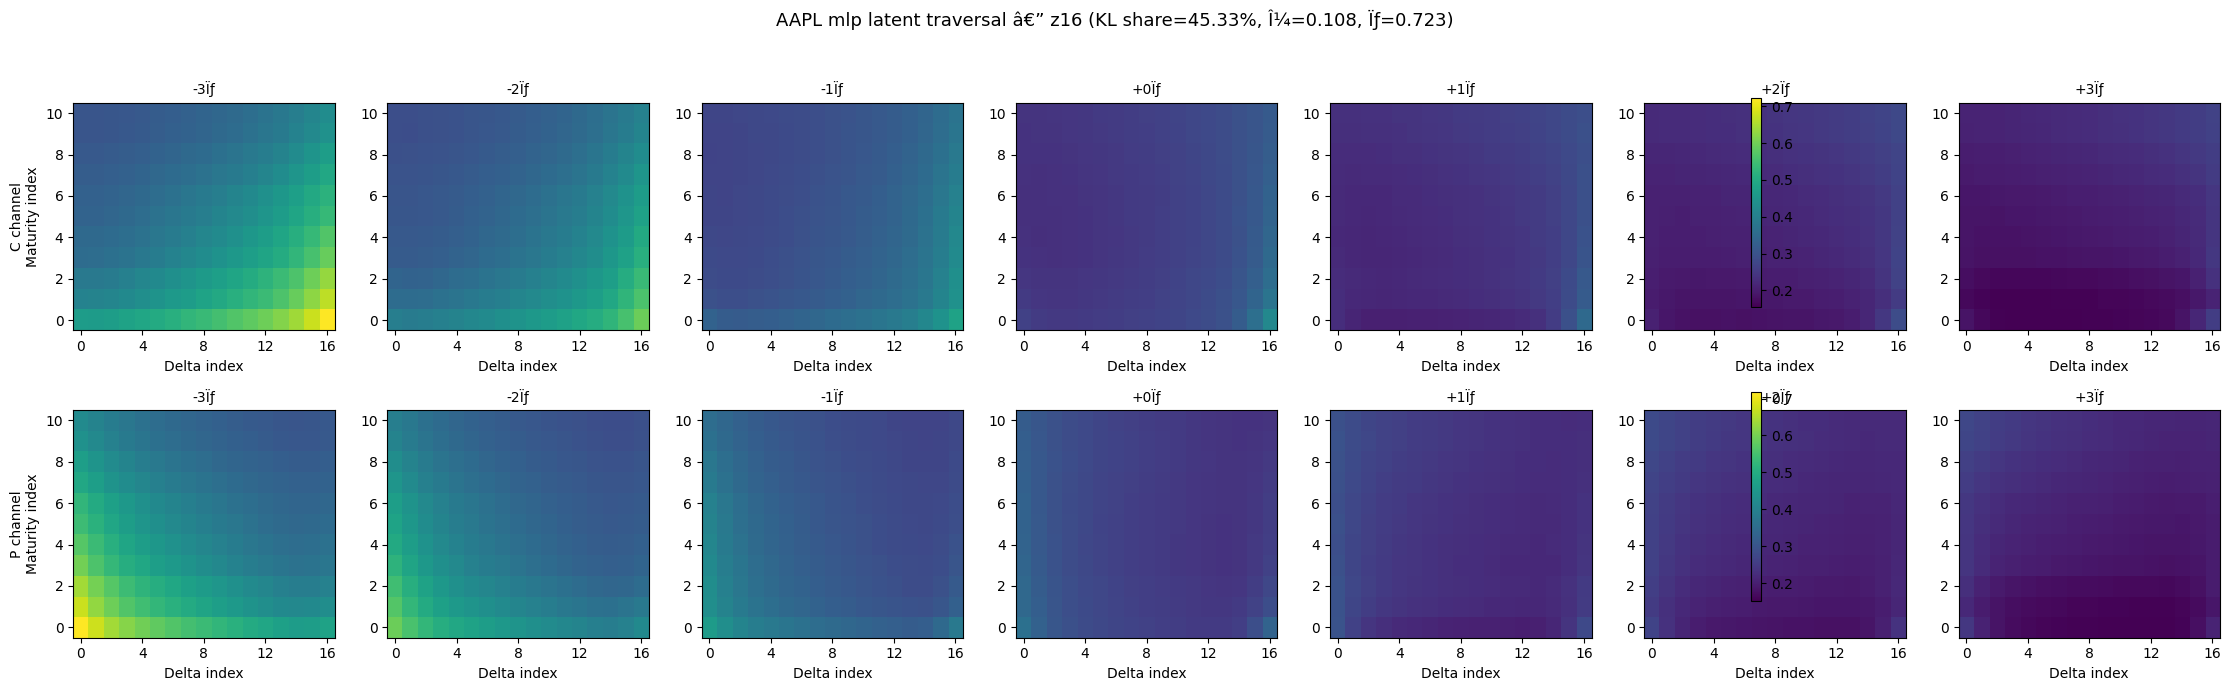

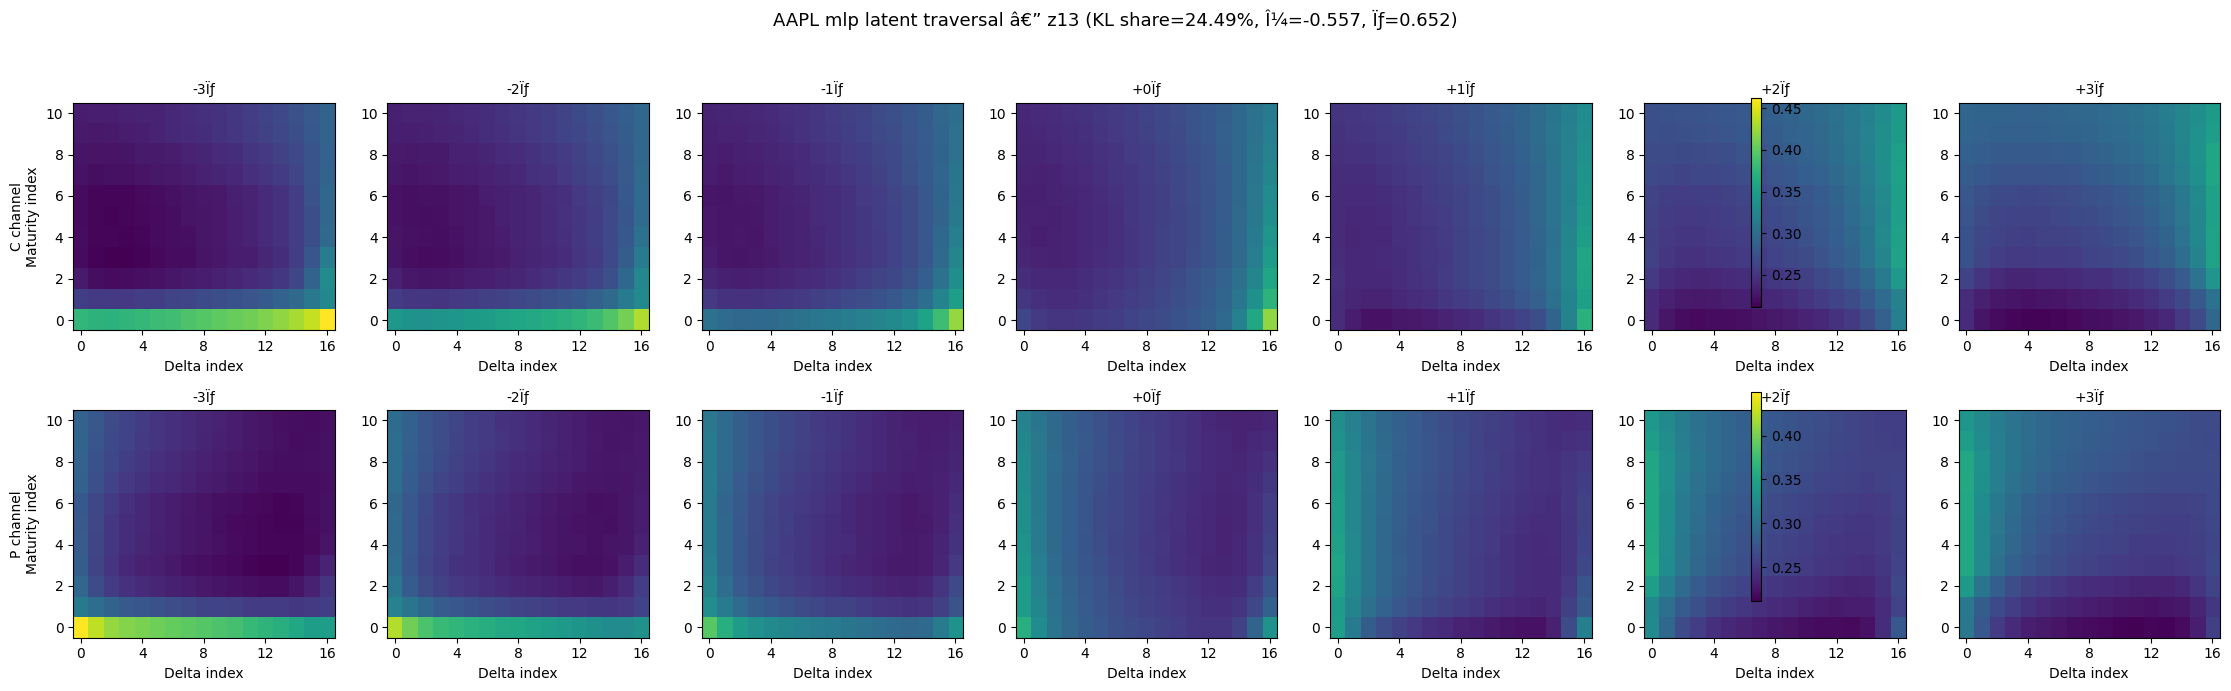

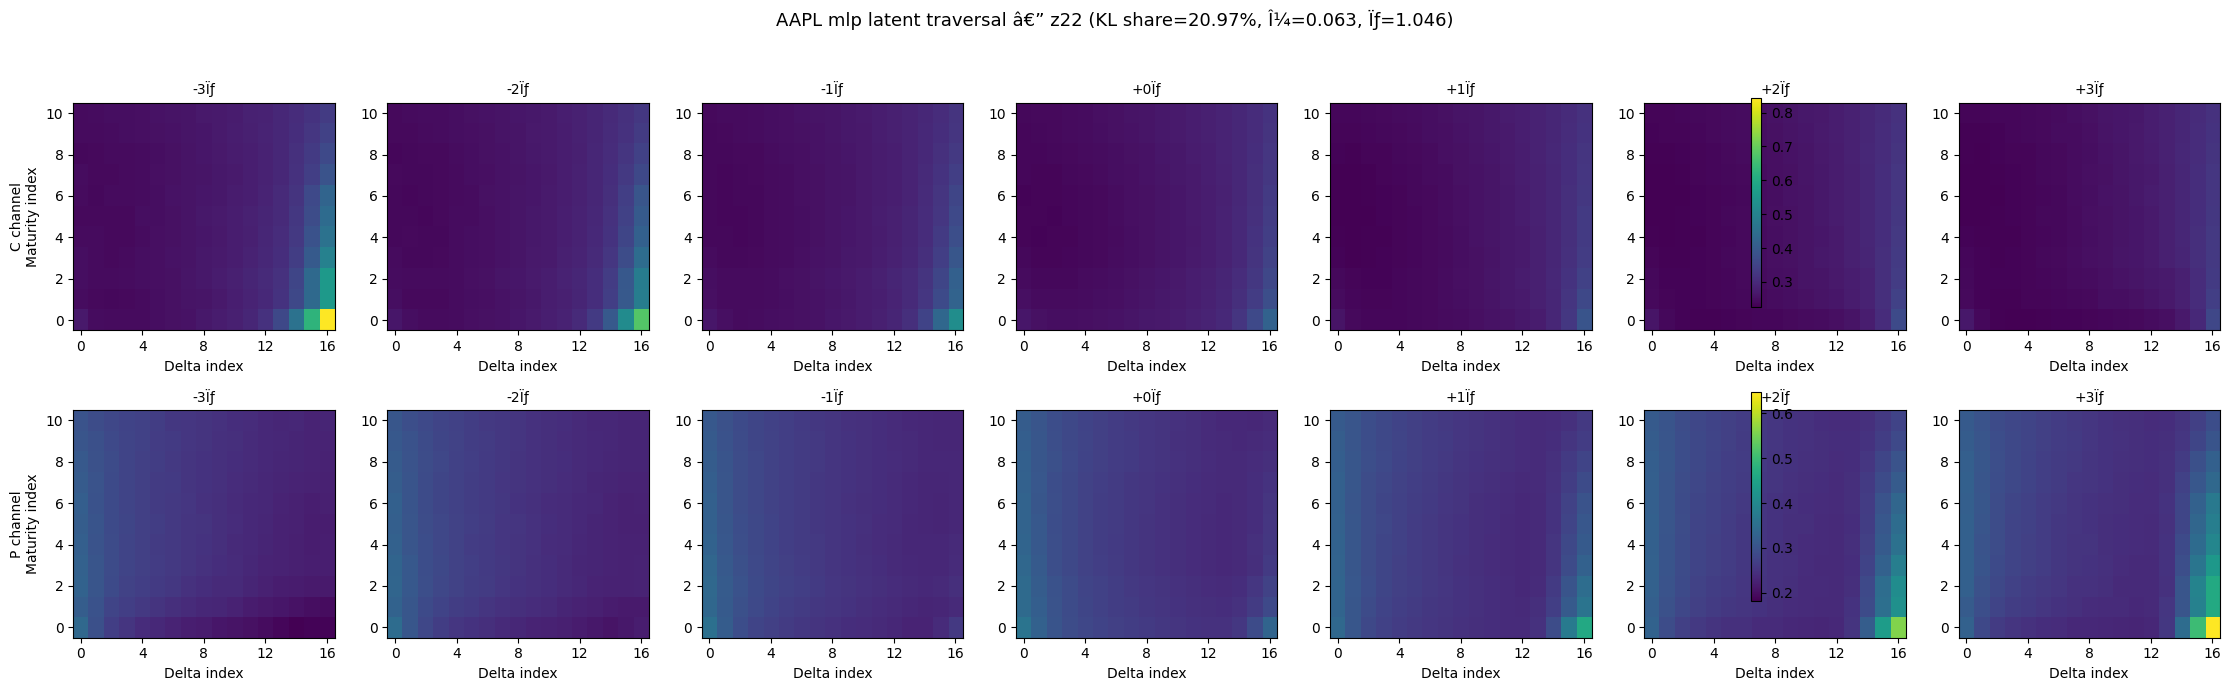

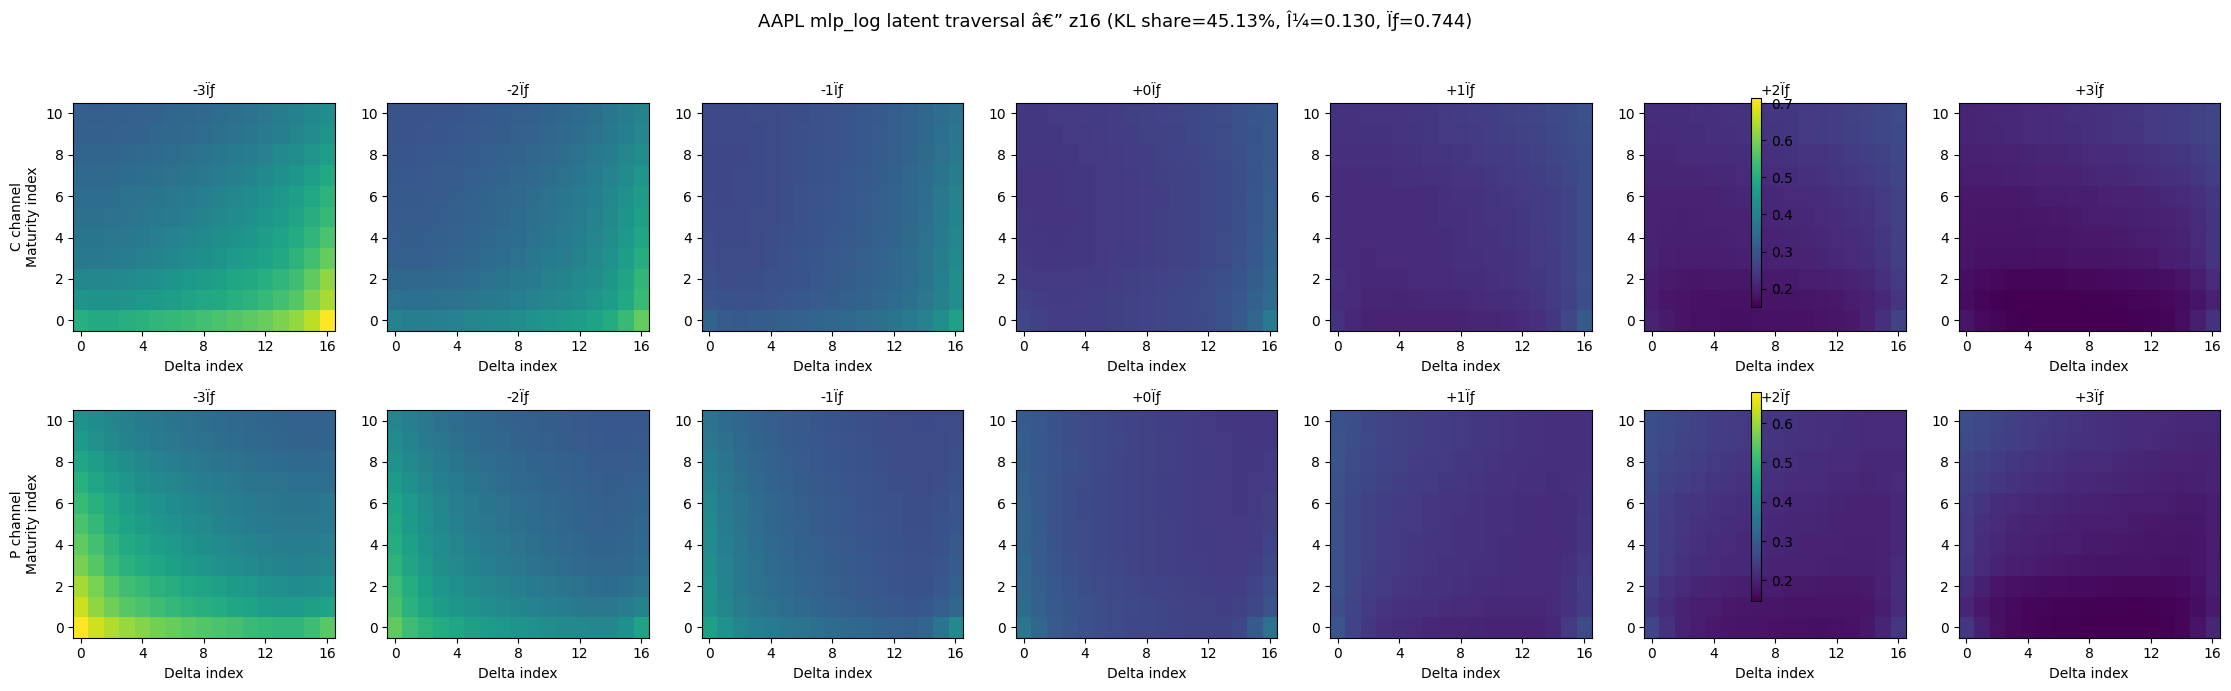

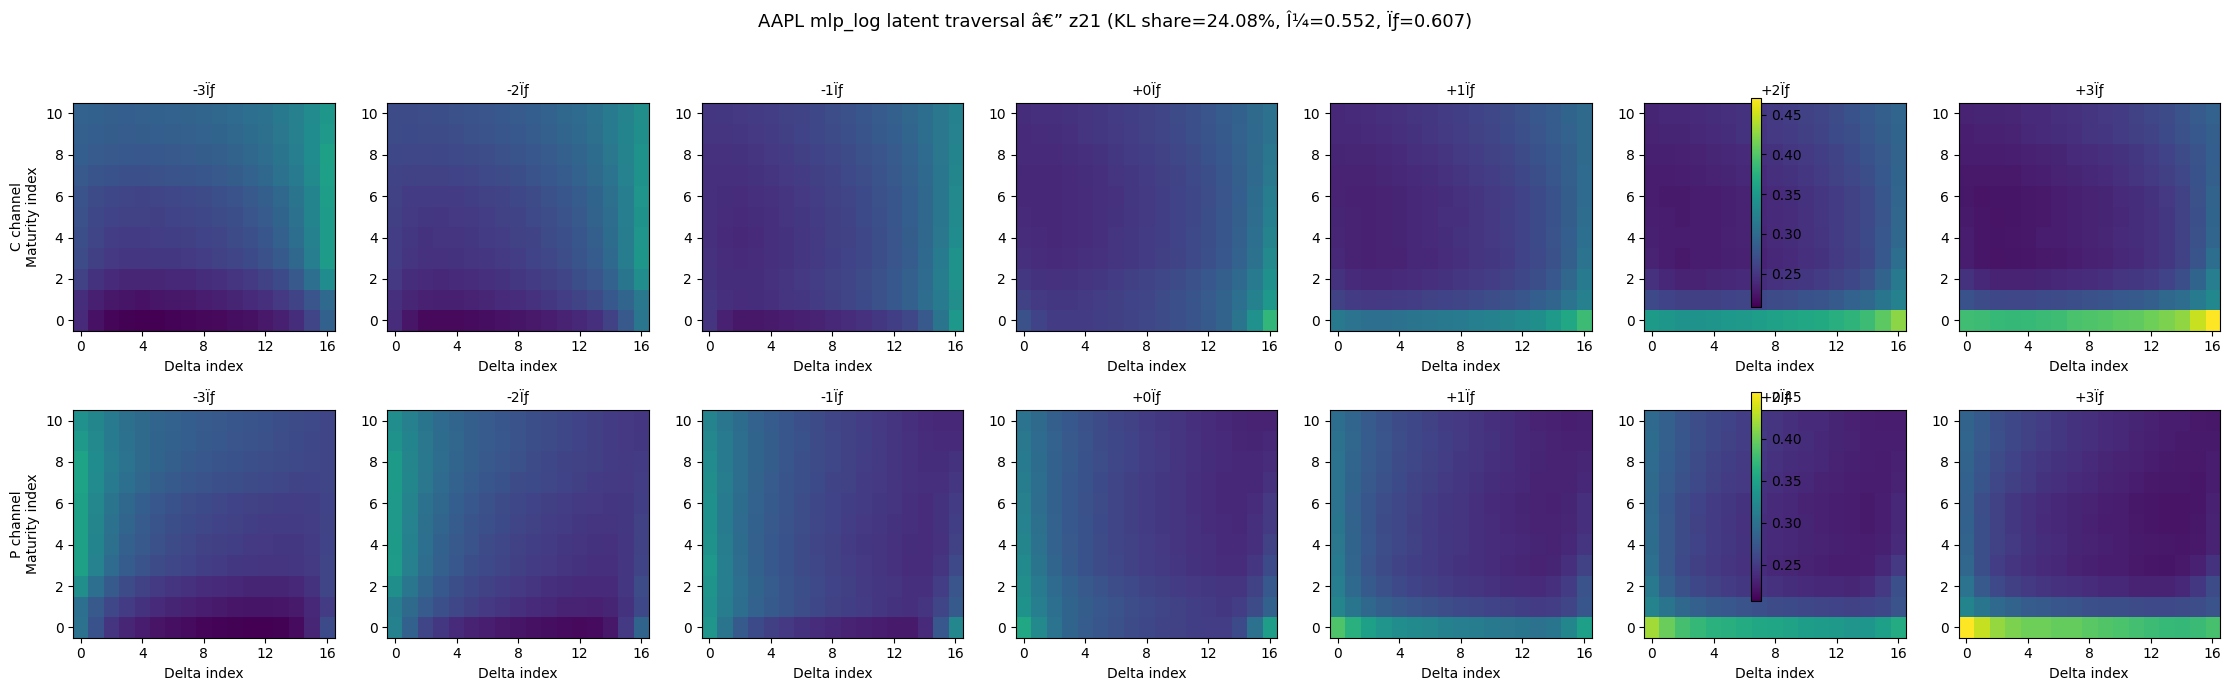

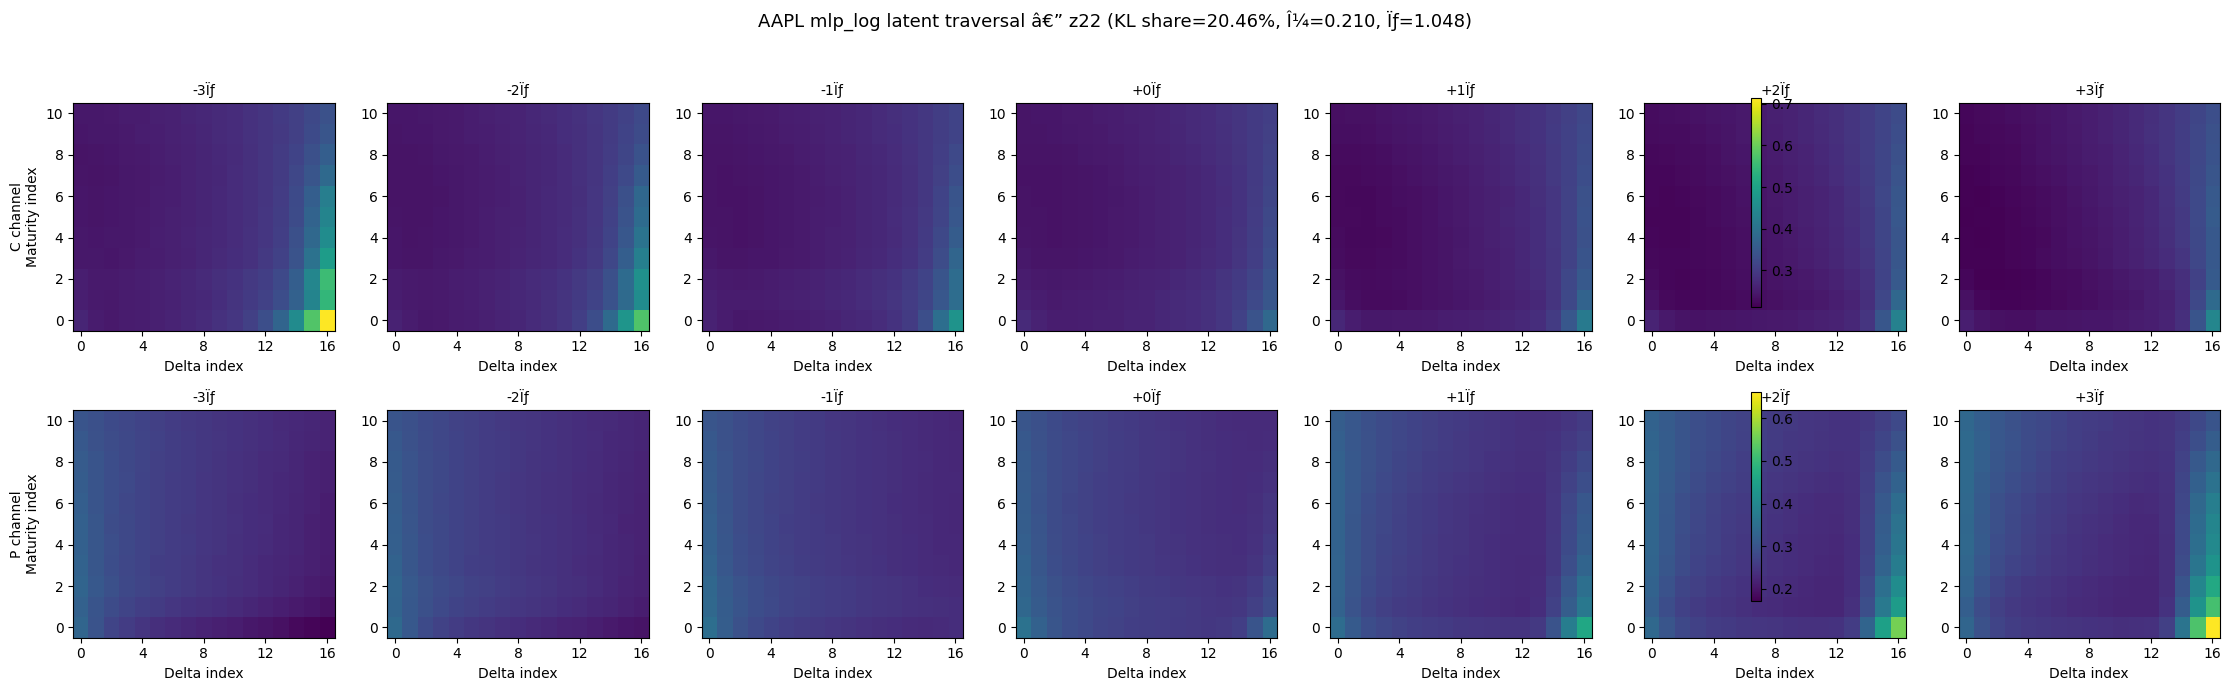

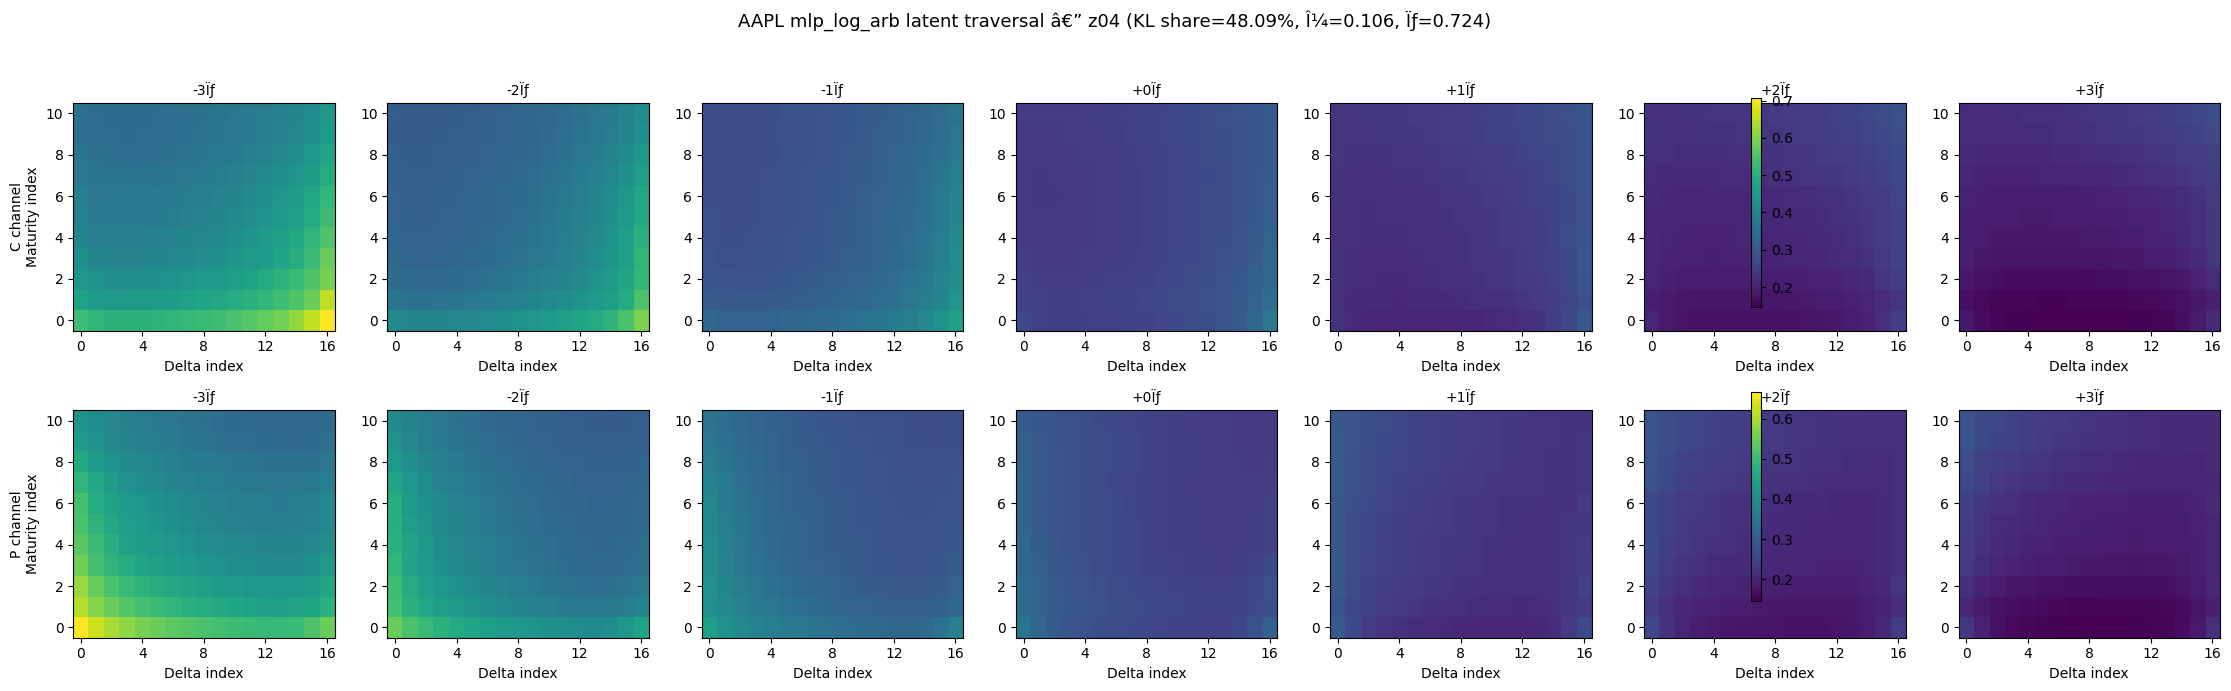

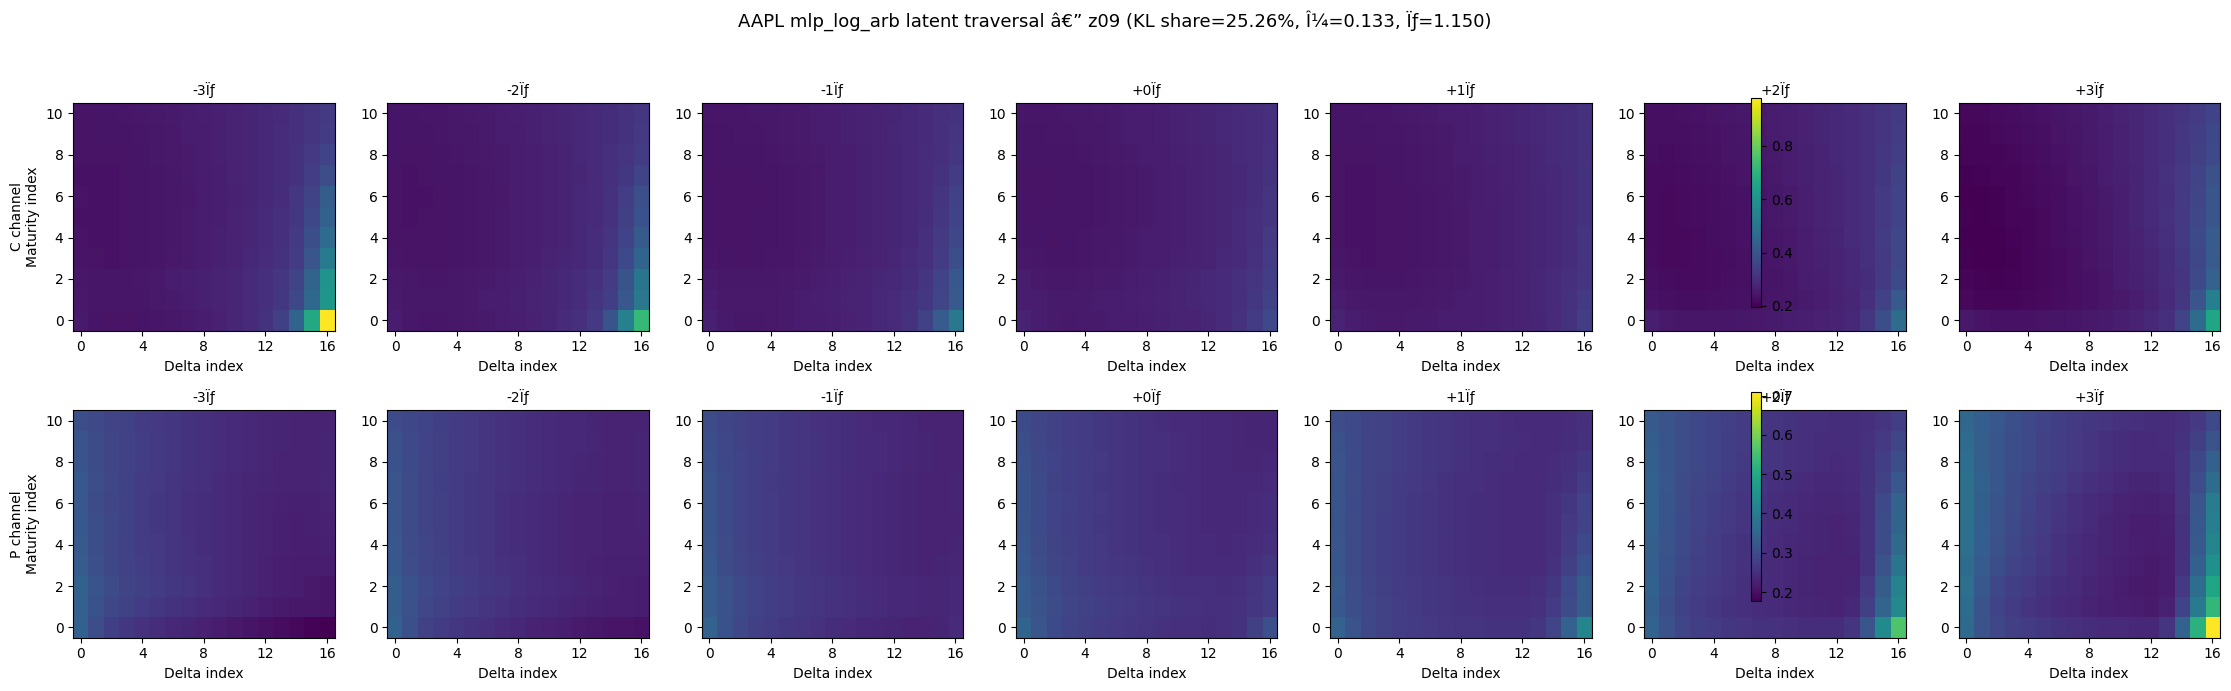

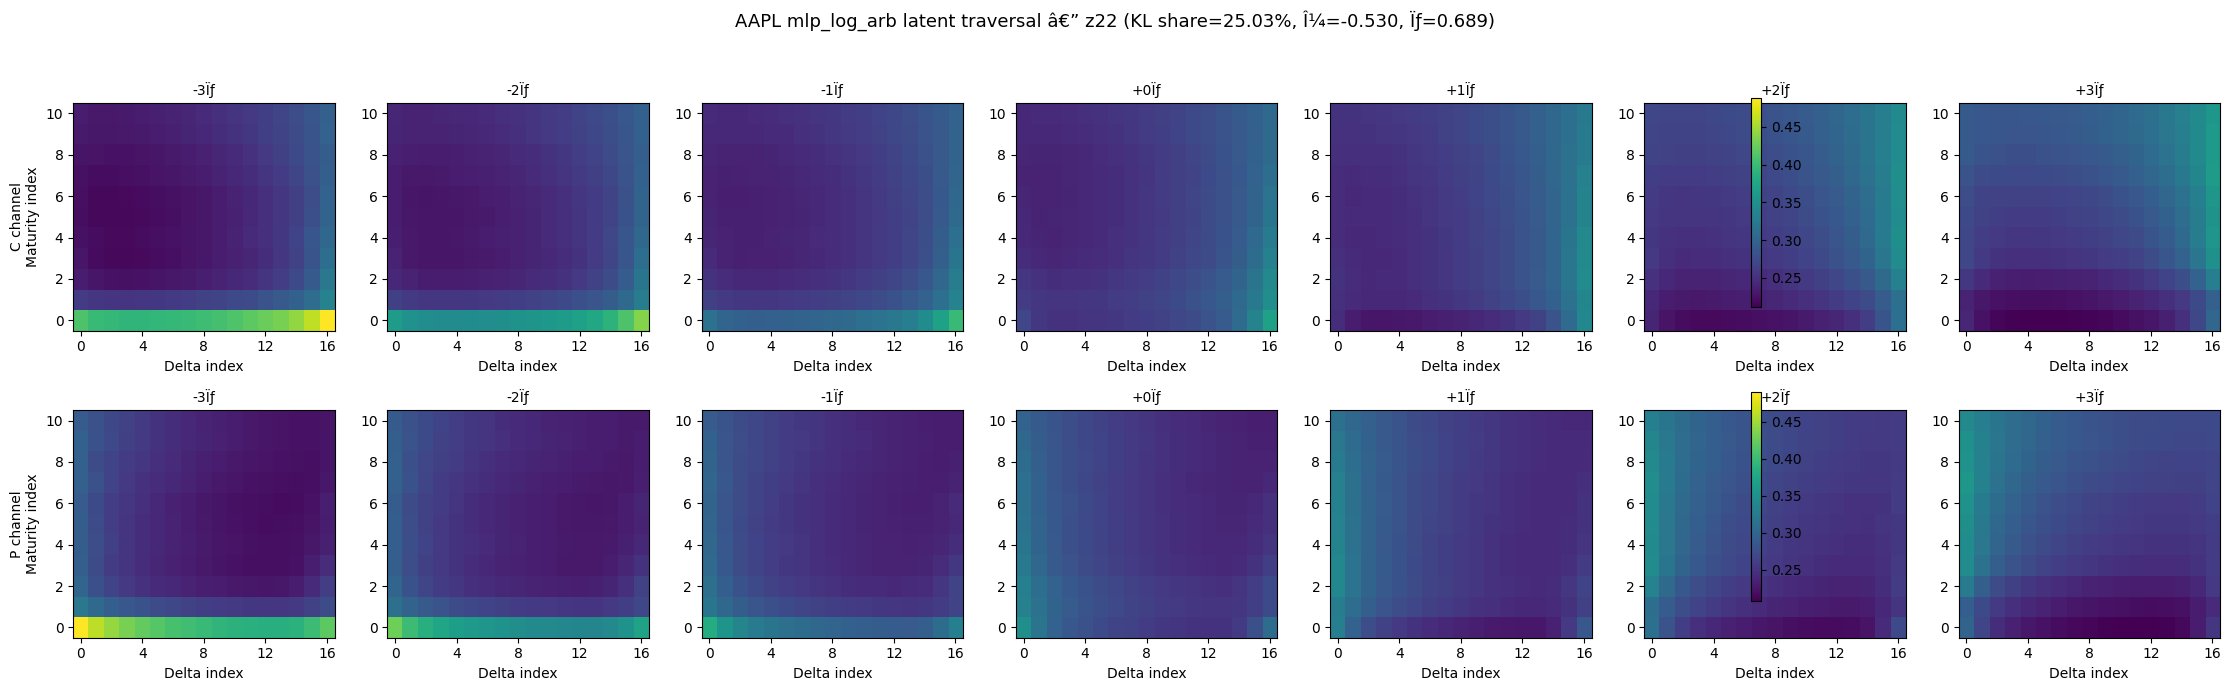

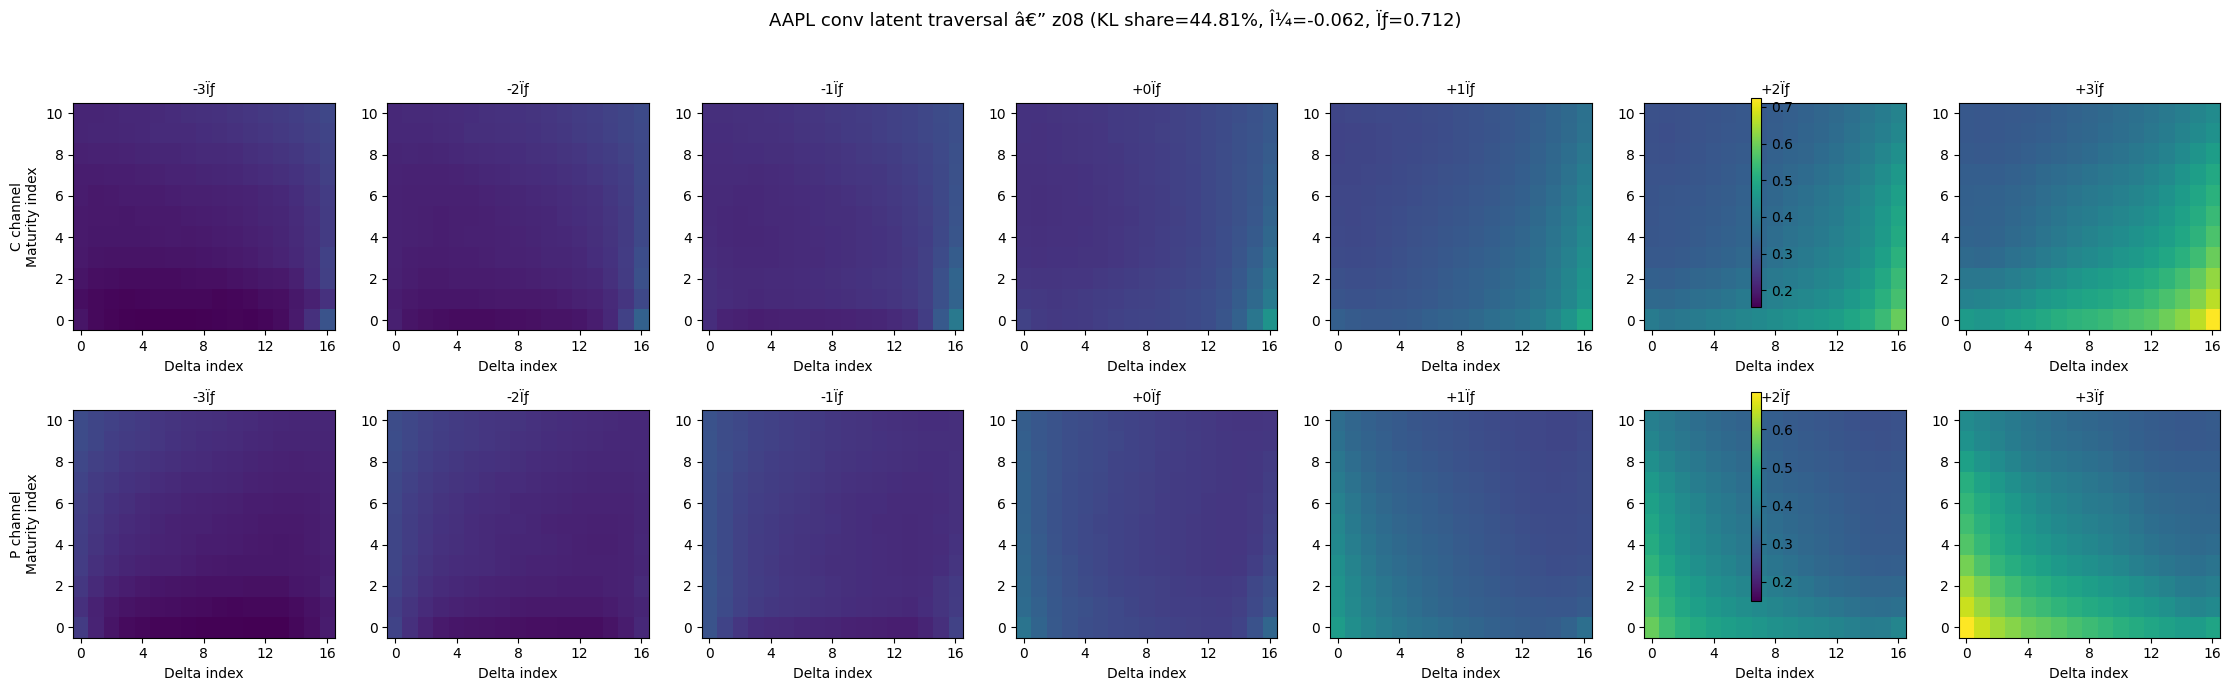

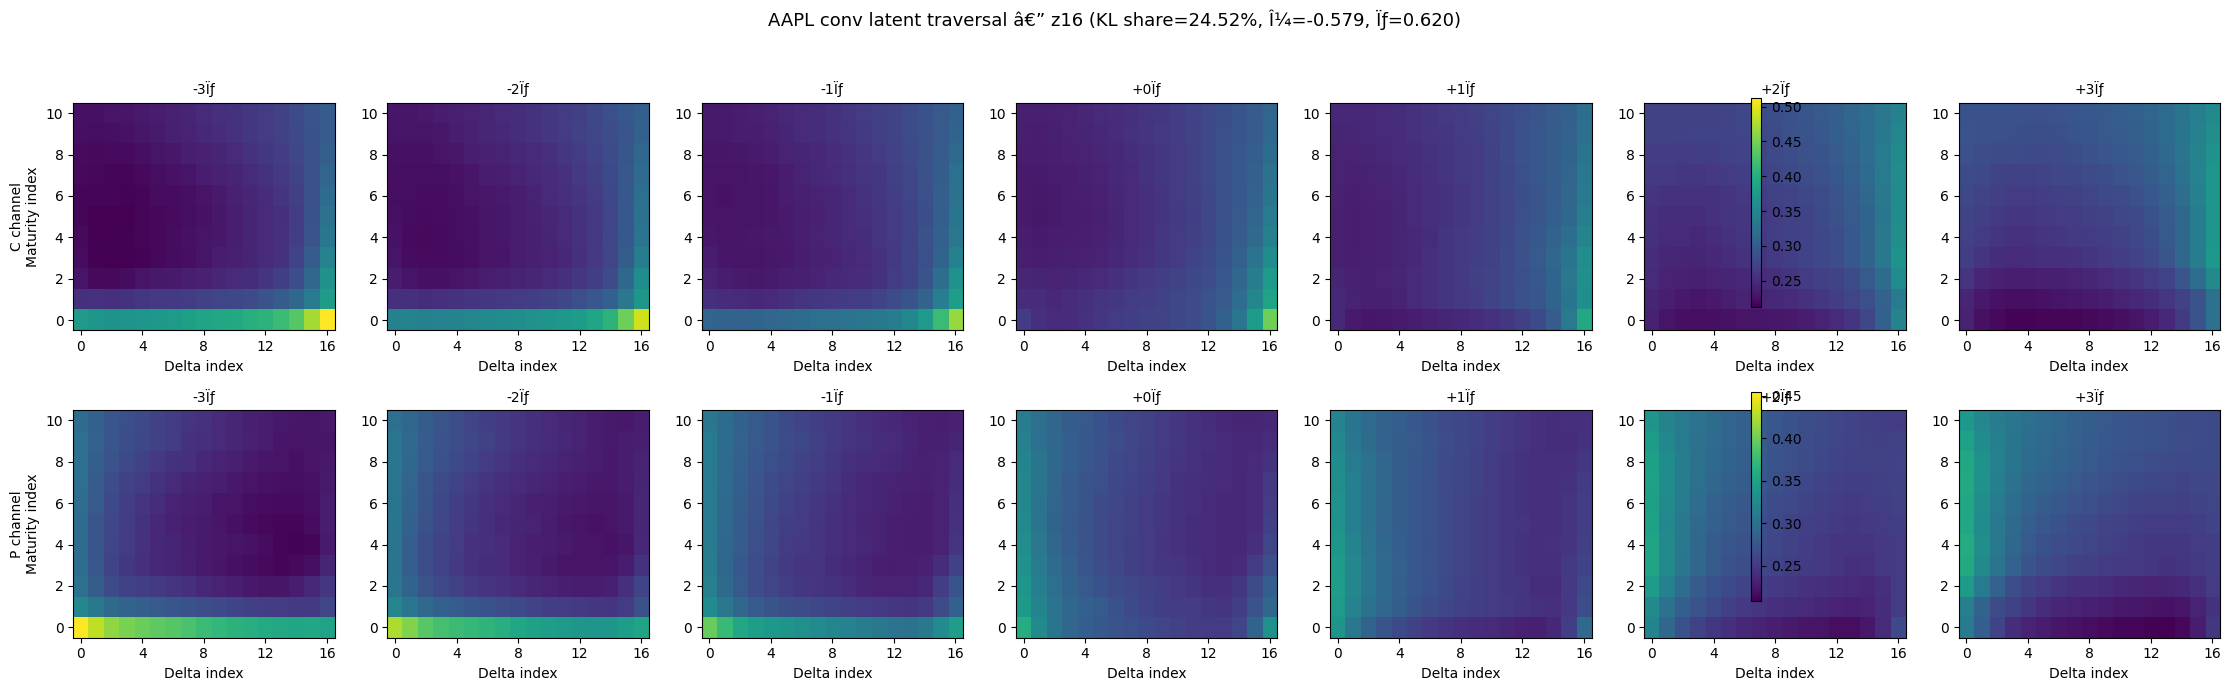

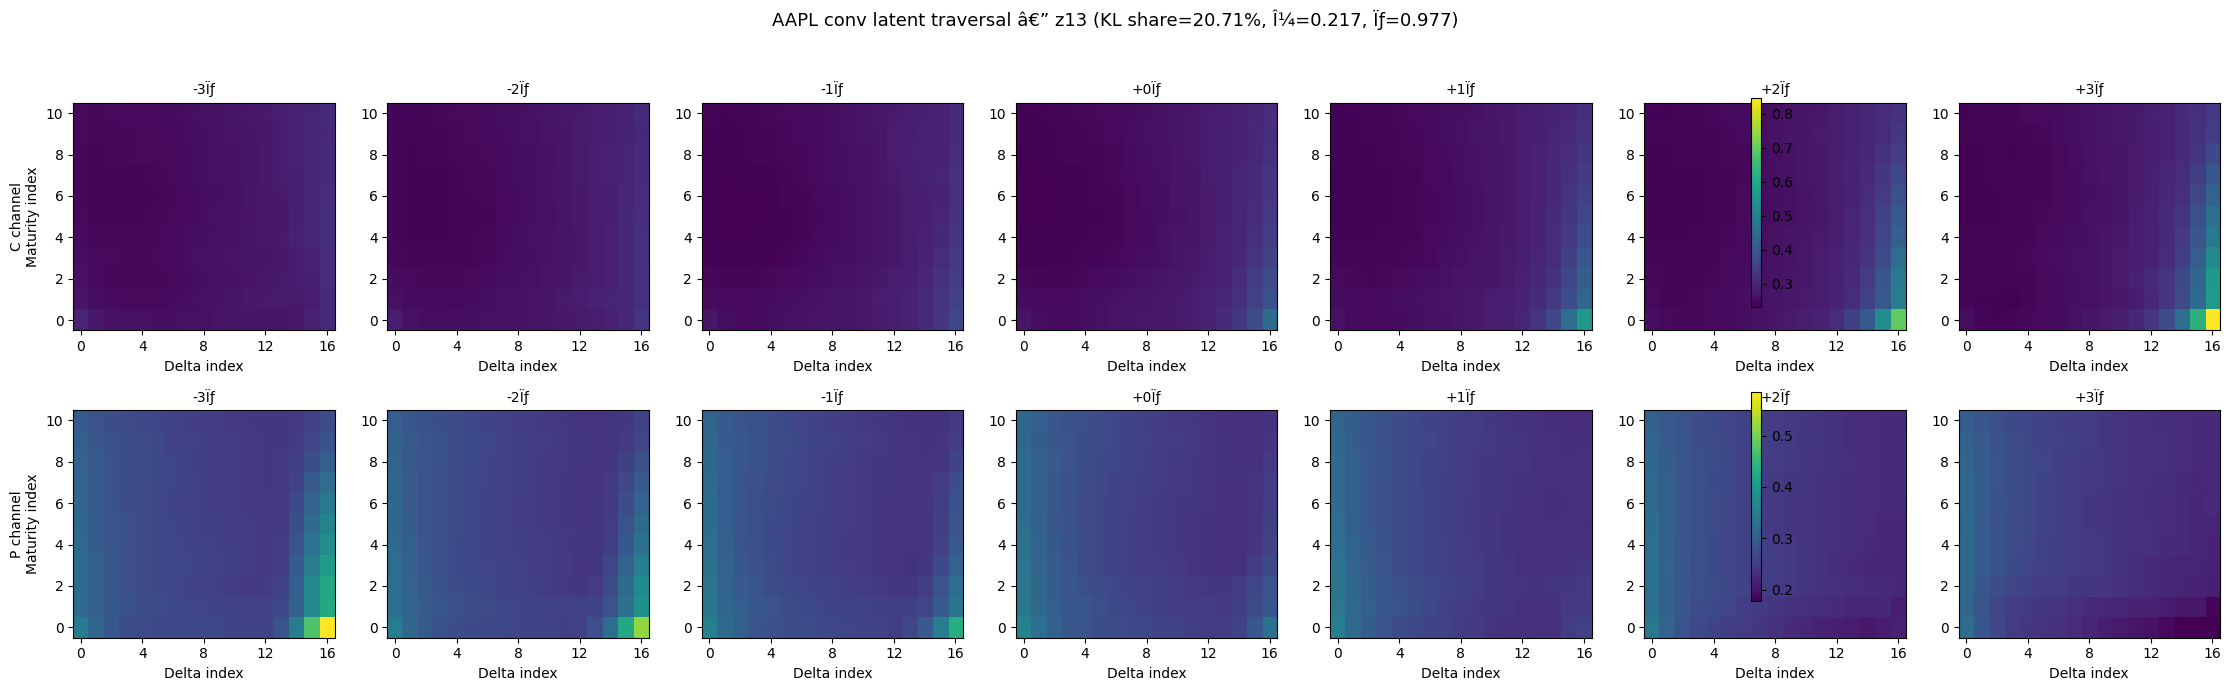

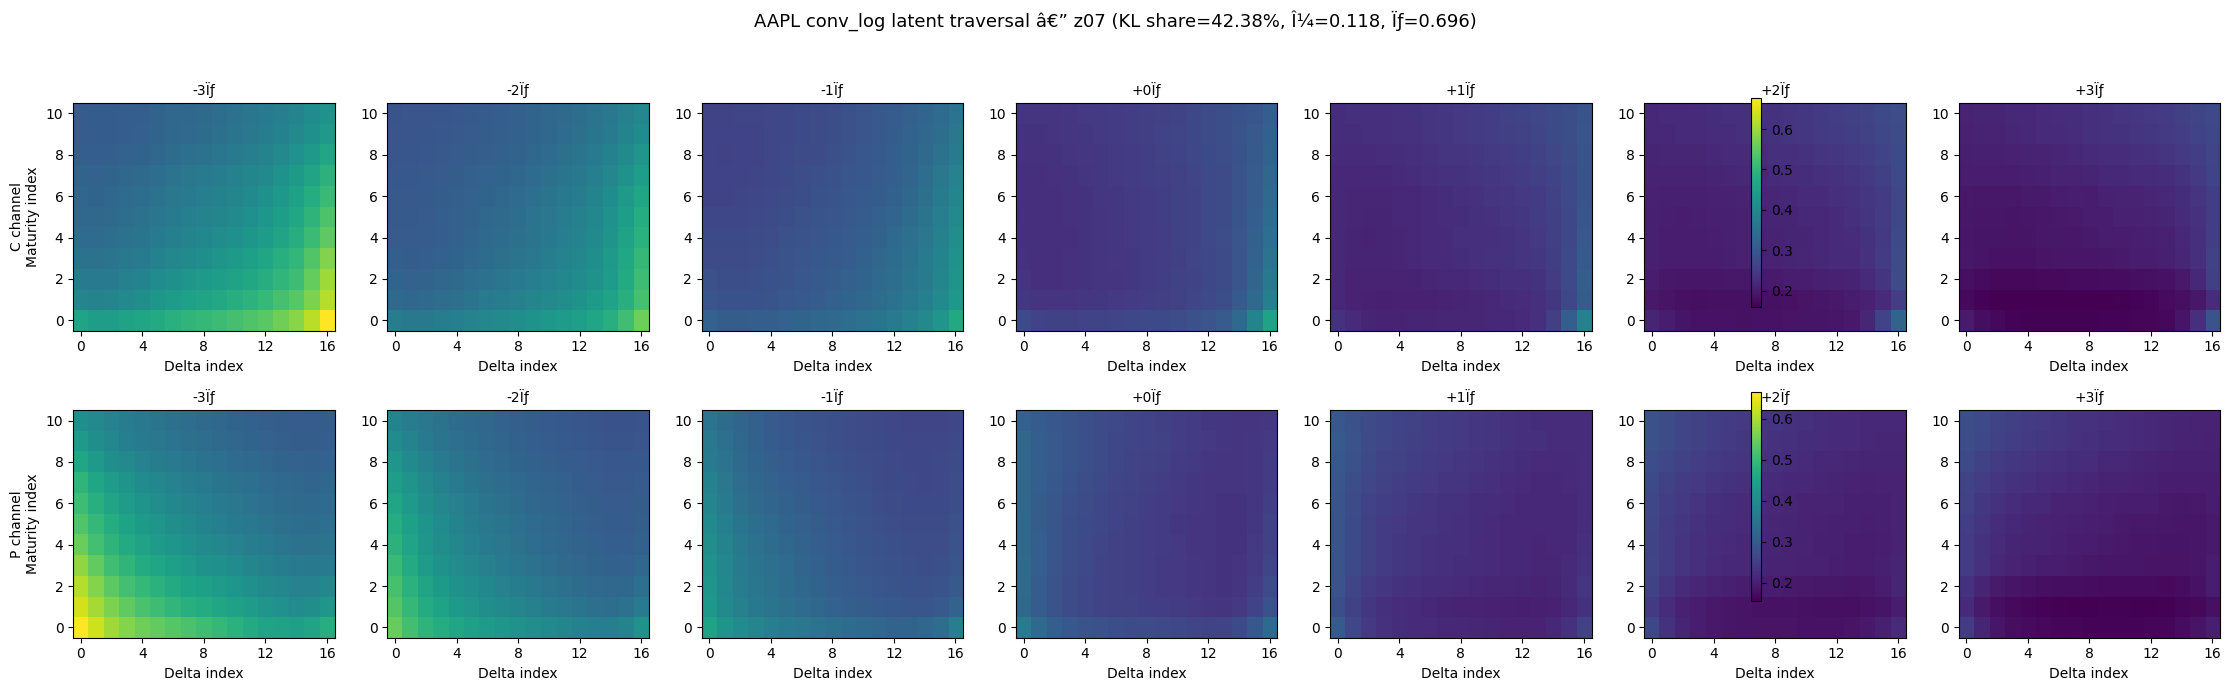

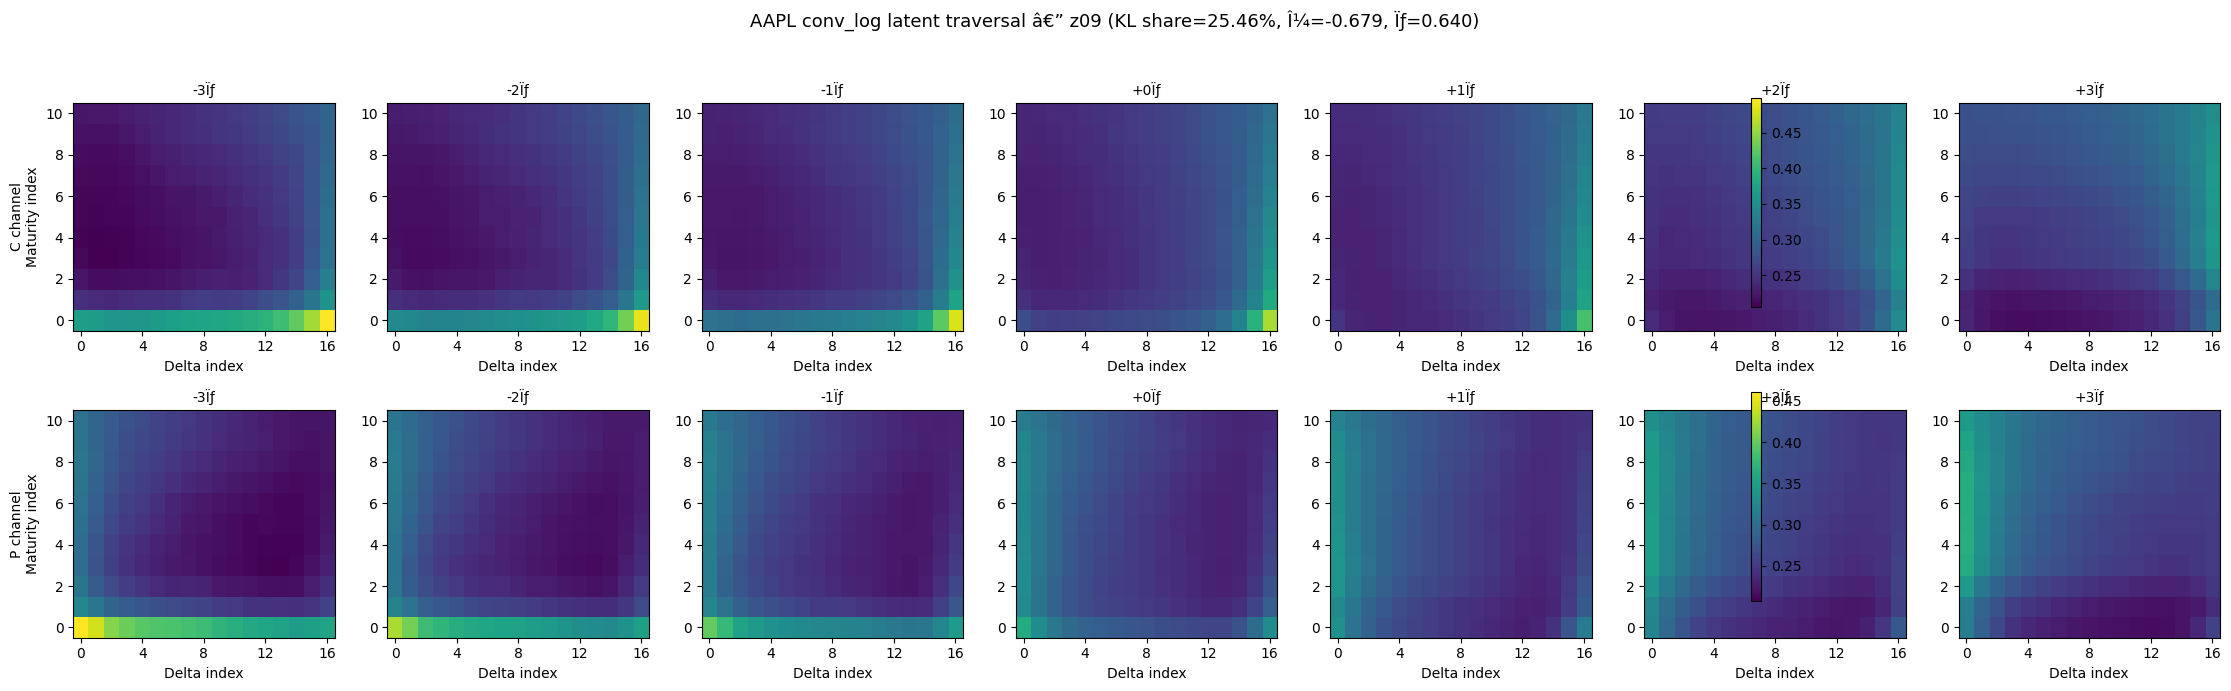

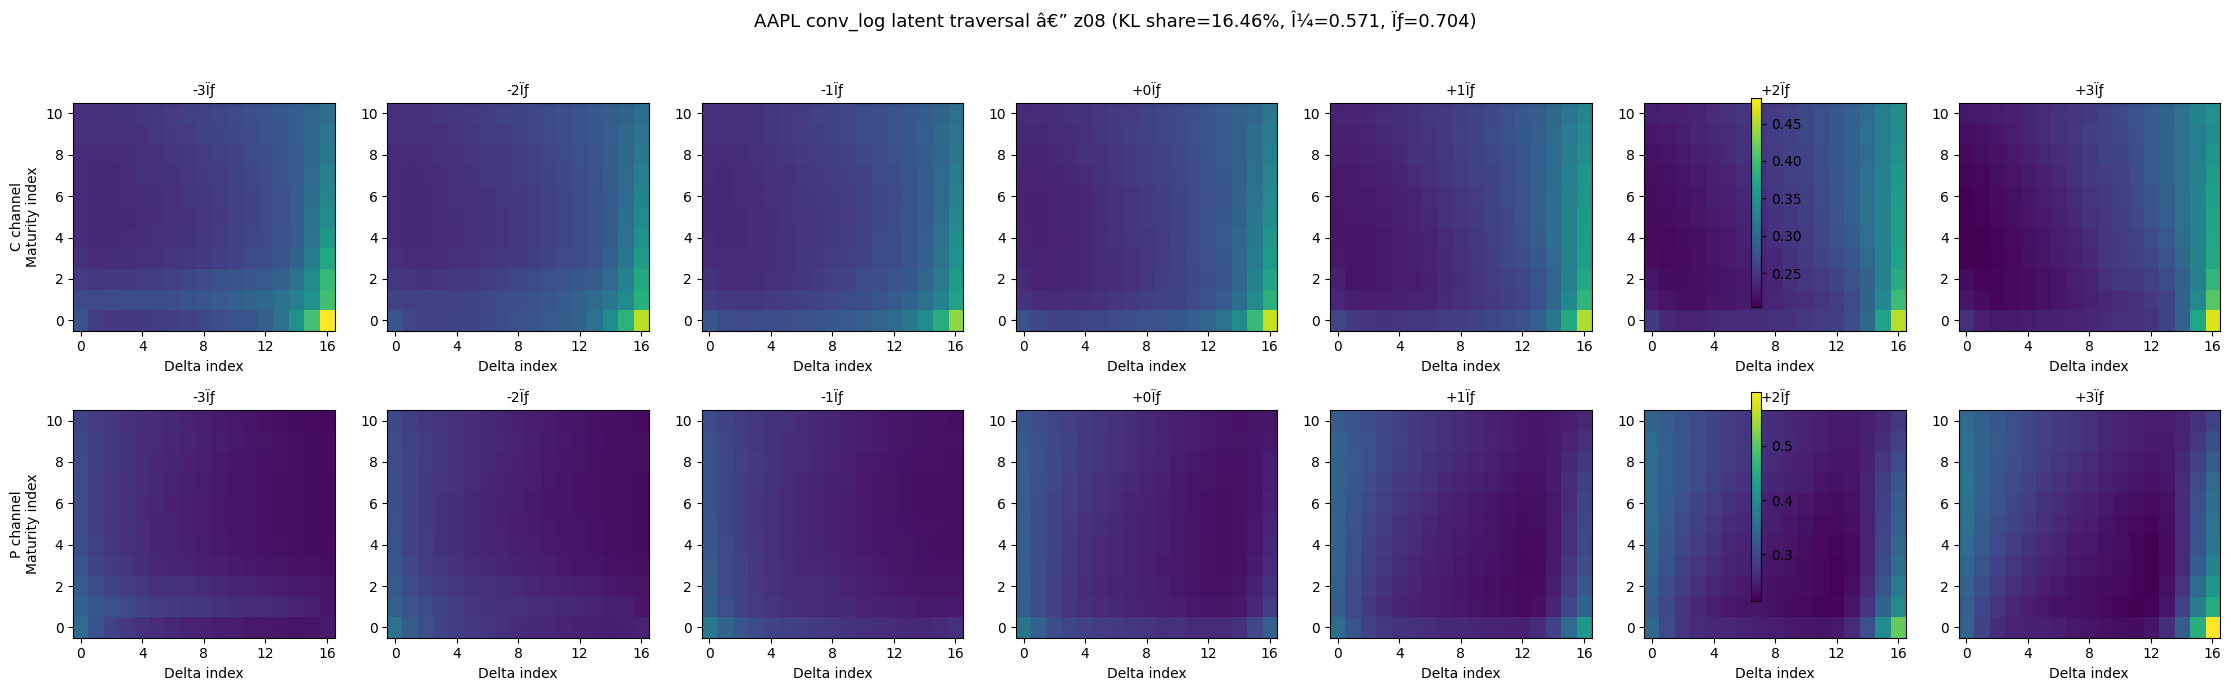

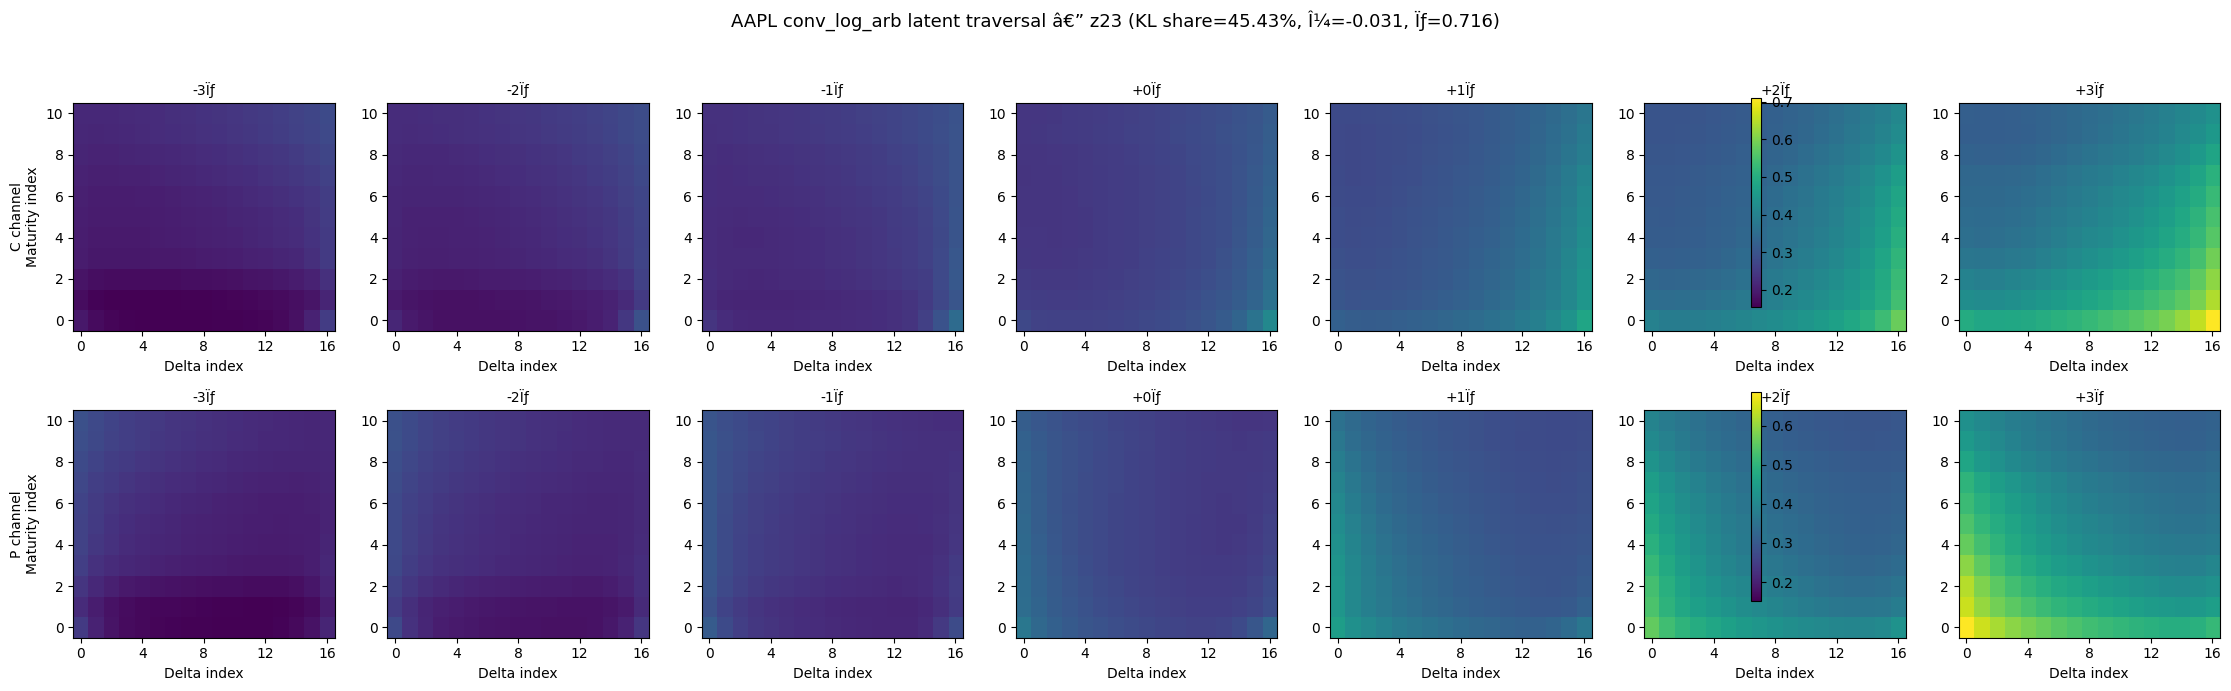

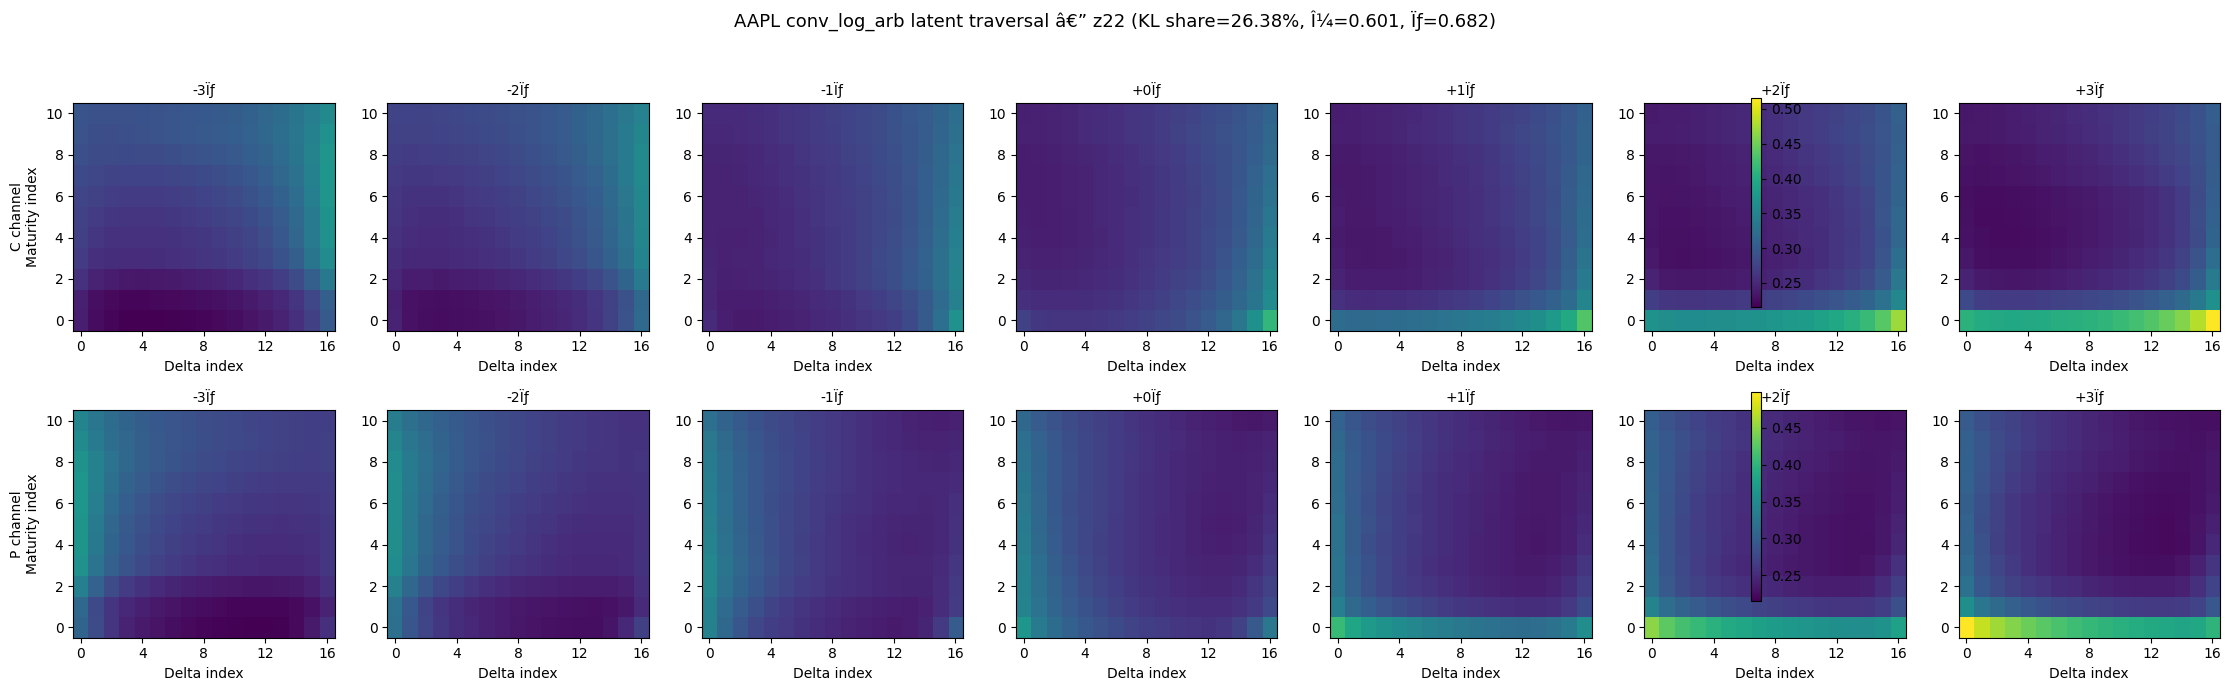

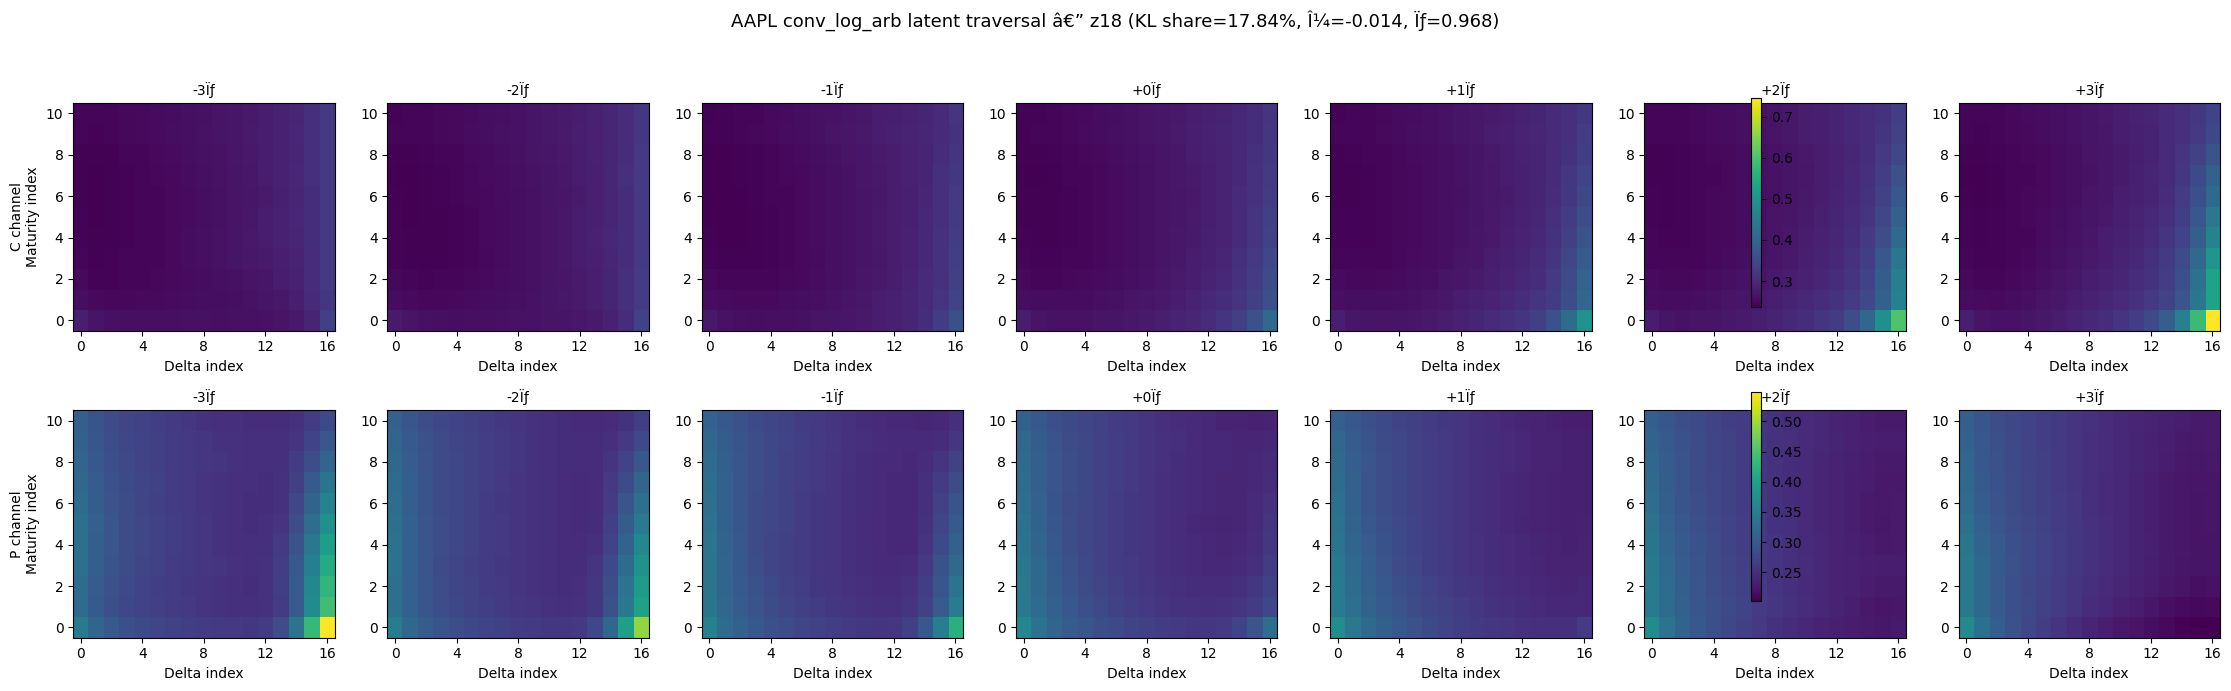

Saved traversal metadata table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\latent_traversal_dims_AAPL.csv
Saved traversal plots: 18 files
  C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_traversal_mlp_z16_AAPL.png
  C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_traversal_mlp_z13_AAPL.png
  C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_traversal_mlp_z22_AAPL.png
  C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_traversal_mlp_log_z16_AAPL.png
  C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\C

,variant,latent_dim_idx,latent_dim_label,mean_kl,share_of_total_kl,latent_mean,latent_std,sigma_steps
0,conv,7,z08,2.085939,0.448140,-0.061550,0.711627,"-3,-2,-1,0,1,2,3"
1,conv,15,z16,1.141489,0.245236,-0.579314,0.620042,"-3,-2,-1,0,1,2,3"
2,conv,12,z13,0.963805,0.207062,0.216805,0.976759,"-3,-2,-1,0,1,2,3"
3,conv_log,6,z07,2.109262,0.423774,0.118457,0.696300,"-3,-2,-1,0,1,2,3"
4,conv_log,8,z09,1.267310,0.254617,-0.678918,0.640459,"-3,-2,-1,0,1,2,3"
5,conv_log,7,z08,0.819023,0.164551,0.571352,0.704286,"-3,-2,-1,0,1,2,3"
6,conv_log_arb,22,z23,2.155415,0.454311,-0.030957,0.716147,"-3,-2,-1,0,1,2,3"
7,conv_log_arb,21,z22,1.251752,0.263840,0.600977,0.682152,"-3,-2,-1,0,1,2,3"
8,conv_log_arb,17,z18,0.846180,0.178355,-0.013640,0.968089,"-3,-2,-1,0,1,2,3"
9,mlp,15,z16,2.156971,0.453285,0.107638,0.722883,"-3,-2,-1,0,1,2,3"


In [11]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.models import create_model
from src.utils.scaler import ChannelStandardizer

TOP_K_DIMS = 3
TRAVERSAL_SIGMA_STEPS = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=np.float32)
TRAIN_ROOT = ROOT / "artifacts" / "train" / TICKER

if "days_grid" not in globals() or "delta_grid" not in globals() or "cp_order" not in globals():
    raise RuntimeError("Grid metadata is missing. Run the market-feature block first.")

traversal_records = []
traversal_plot_paths = []

for variant in VARIANTS:
    latent_path = EVAL_ROOT / variant / "test_latents.pt"
    checkpoint_path = TRAIN_ROOT / variant / "vae_checkpoint.pt"

    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found for {variant}: {checkpoint_path}")

    latent_payload = torch.load(latent_path, map_location="cpu", weights_only=False)
    mus_np = latent_payload["mus"].detach().cpu().numpy() if isinstance(latent_payload["mus"], torch.Tensor) else np.asarray(latent_payload["mus"])
    logvars_np = latent_payload["logvars"].detach().cpu().numpy() if isinstance(latent_payload["logvars"], torch.Tensor) else np.asarray(latent_payload["logvars"])

    if mus_np.ndim != 2 or logvars_np.ndim != 2:
        raise ValueError(f"{variant}: expected 2D mus/logvars, got {mus_np.shape} and {logvars_np.shape}")
    if mus_np.shape != logvars_np.shape:
        raise ValueError(f"{variant}: mus/logvars shape mismatch: {mus_np.shape} vs {logvars_np.shape}")

    kl_per_dim = 0.5 * (np.square(mus_np) + np.exp(logvars_np) - 1.0 - logvars_np)
    mean_kl_per_dim = kl_per_dim.mean(axis=0)
    total_kl = float(mean_kl_per_dim.sum())
    if total_kl <= 0.0:
        raise ValueError(f"{variant}: total mean KL is non-positive")

    top_dim_indices = np.argsort(mean_kl_per_dim)[::-1][:TOP_K_DIMS]

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    train_args = checkpoint["args"]
    input_shape = tuple(checkpoint["input_shape"])
    model_type = checkpoint.get("model_type", train_args.get("model_type", "mlp"))

    model = create_model(
        model_type=model_type,
        in_shape=input_shape,
        latent_dim=train_args.get("latent_dim", 24),
        hidden_dims=tuple(train_args.get("hidden_dims", [256, 128])),
        channels=tuple(train_args.get("channels", [32, 64, 128])),
        fc_dim=train_args.get("fc_dim", 256),
        batchnorm=not train_args.get("no_batchnorm", False),
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    scaler_state = checkpoint.get("scaler")
    if scaler_state is None or not isinstance(scaler_state, dict):
        raise ValueError(f"{variant}: checkpoint scaler state missing or invalid")

    scaler = ChannelStandardizer(
        log_transform=bool(scaler_state.get("log_transform", train_args.get("log_transform", False)))
    )
    scaler.mean = torch.tensor(scaler_state["mean"], dtype=torch.float32, device=DEVICE)
    scaler.std = torch.tensor(scaler_state["std"], dtype=torch.float32, device=DEVICE)

    latent_mean = mus_np.mean(axis=0).astype(np.float32)
    latent_std = mus_np.std(axis=0, ddof=0).astype(np.float32)

    for dim_idx in top_dim_indices:
        dim_label = f"z{dim_idx + 1:02d}"
        dim_std = float(latent_std[dim_idx])
        dim_mean = float(latent_mean[dim_idx])
        dim_kl = float(mean_kl_per_dim[dim_idx])
        dim_kl_share = dim_kl / total_kl

        if dim_std == 0.0:
            dim_std = 1e-6

        z_batch = np.repeat(latent_mean[None, :], len(TRAVERSAL_SIGMA_STEPS), axis=0)
        z_batch[:, dim_idx] = dim_mean + TRAVERSAL_SIGMA_STEPS * dim_std

        with torch.no_grad():
            z_tensor = torch.tensor(z_batch, dtype=torch.float32, device=DEVICE)
            recon = model.decode(z_tensor)
            recon_orig = scaler.inverse_transform(recon).detach().cpu().numpy()

        fig, axes = plt.subplots(2, len(TRAVERSAL_SIGMA_STEPS), figsize=(3.2 * len(TRAVERSAL_SIGMA_STEPS), 7.0), squeeze=False)
        for c in range(2):
            channel_min = float(np.nanmin(recon_orig[:, c, :, :]))
            channel_max = float(np.nanmax(recon_orig[:, c, :, :]))
            for j, step in enumerate(TRAVERSAL_SIGMA_STEPS):
                ax = axes[c, j]
                im = ax.imshow(
                    recon_orig[j, c],
                    origin="lower",
                    aspect="auto",
                    cmap="viridis",
                    vmin=channel_min,
                    vmax=channel_max,
                )
                ax.set_title(f"{step:+.0f}σ", fontsize=10)
                if j == 0:
                    ax.set_ylabel(f"{cp_order[c].upper()} channel\nMaturity index")
                ax.set_xlabel("Delta index")
                ax.set_xticks(range(0, len(delta_grid), 4))
                ax.set_yticks(range(0, len(days_grid), 2))
            fig.colorbar(im, ax=axes[c, :], shrink=0.85, pad=0.01)

        fig.suptitle(
            (
                f"{TICKER} {variant} latent traversal — {dim_label} "
                f"(KL share={dim_kl_share:.2%}, μ={dim_mean:.3f}, σ={dim_std:.3f})"
            ),
            fontsize=13,
        )
        fig.tight_layout(rect=[0, 0, 1, 0.95])

        plot_path = PLOTS_DIR / f"latent_traversal_{variant}_{dim_label}_{TICKER}.png"
        fig.savefig(plot_path, dpi=200, bbox_inches="tight")
        traversal_plot_paths.append(plot_path)
        plt.show()

        traversal_records.append(
            {
                "variant": variant,
                "latent_dim_idx": int(dim_idx),
                "latent_dim_label": dim_label,
                "mean_kl": dim_kl,
                "share_of_total_kl": float(dim_kl_share),
                "latent_mean": dim_mean,
                "latent_std": dim_std,
                "sigma_steps": ",".join([str(int(s)) for s in TRAVERSAL_SIGMA_STEPS]),
            }
        )

traversal_df = pd.DataFrame(traversal_records).sort_values(["variant", "share_of_total_kl"], ascending=[True, False]).reset_index(drop=True)
traversal_csv = TABLES_DIR / f"latent_traversal_dims_{TICKER}.csv"
traversal_df.to_csv(traversal_csv, index=False)

print(f"Saved traversal metadata table to: {traversal_csv}")
print(f"Saved traversal plots: {len(traversal_plot_paths)} files")
for path in traversal_plot_paths:
    print(f"  {path}")

display(traversal_df)

## 8. PCA Component Traversals (D2)

This block traverses the latent space along principal-component directions (PC1, PC2, PC3)
for each variant. It complements single-dimension traversals by showing coordinated movements
across latent coordinates and their decoded surface impact in original IV space.

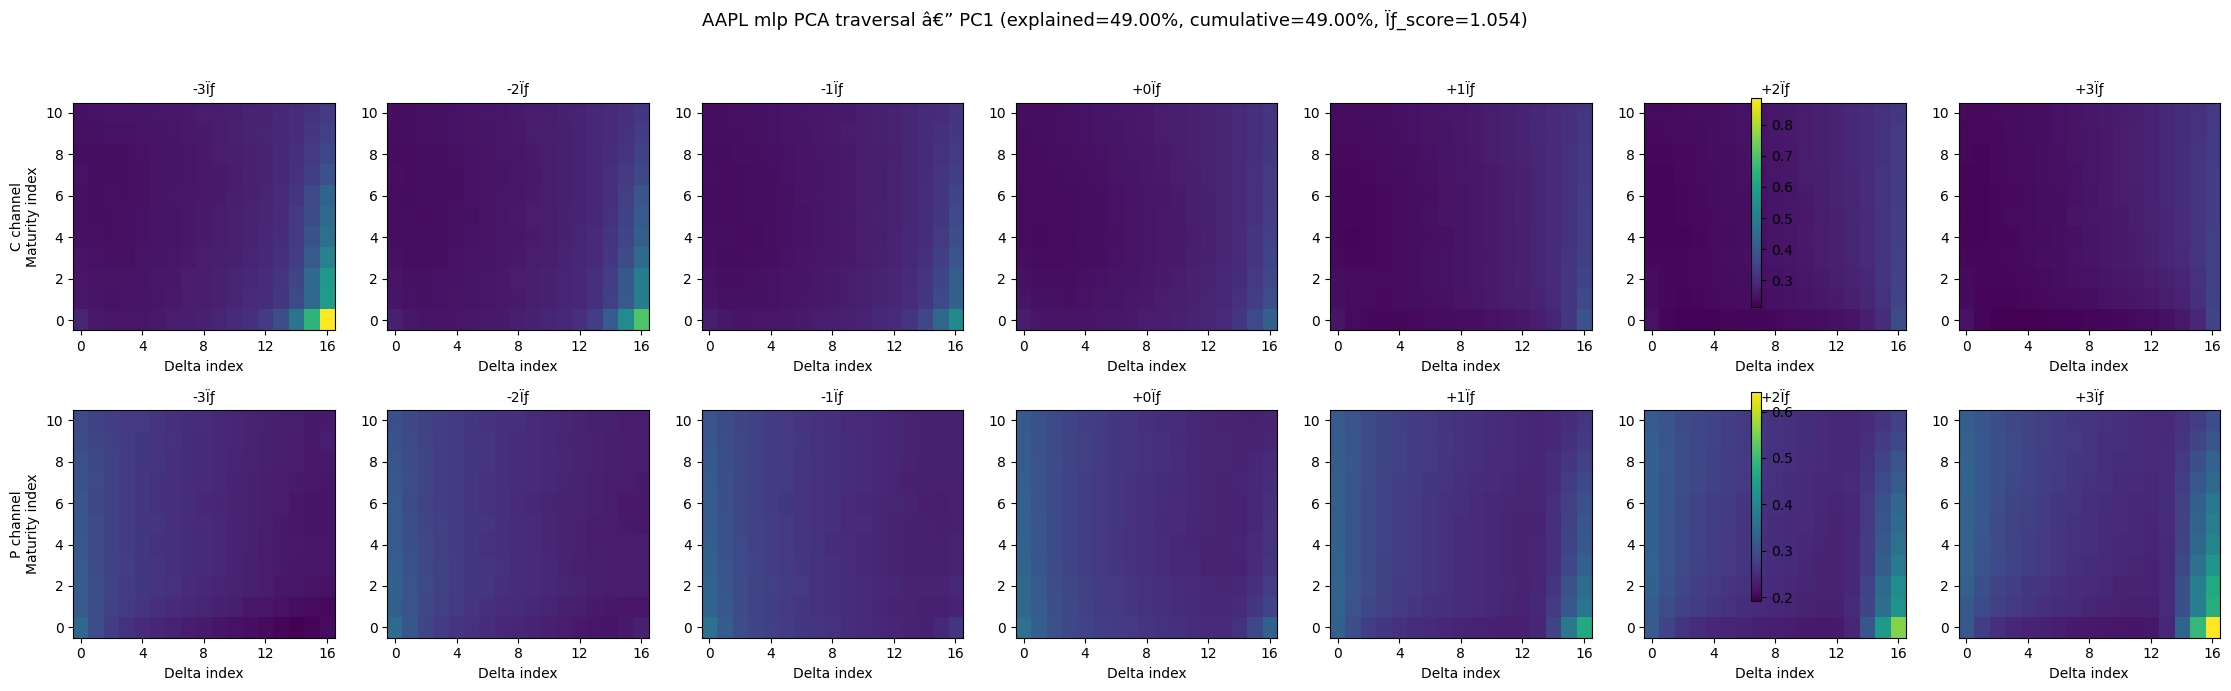

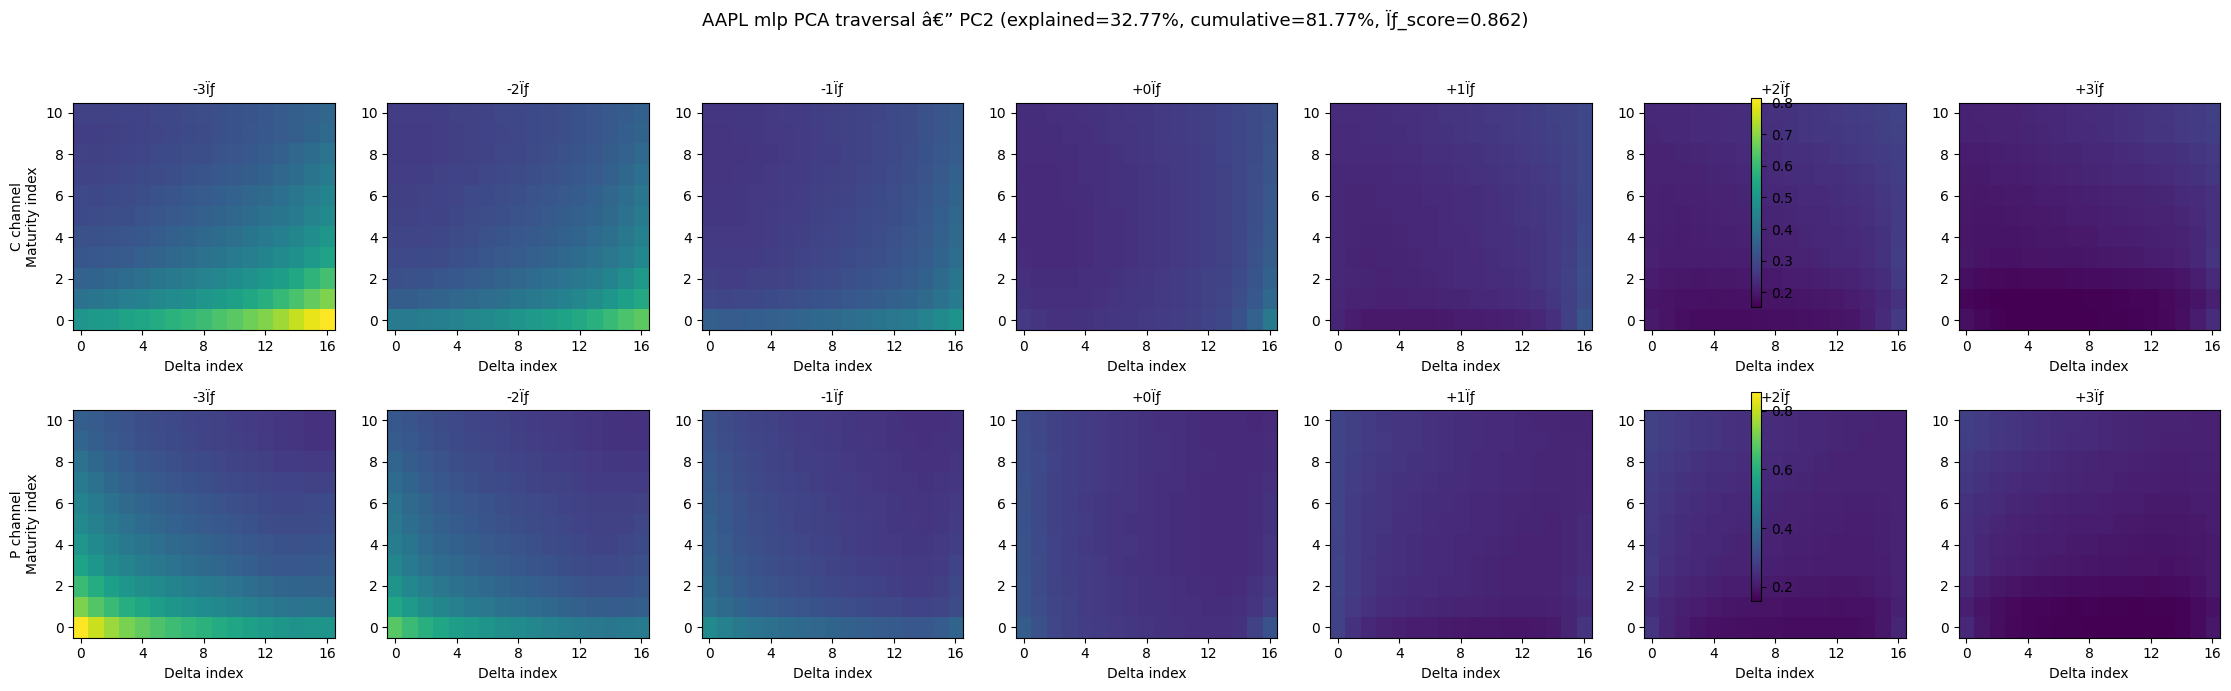

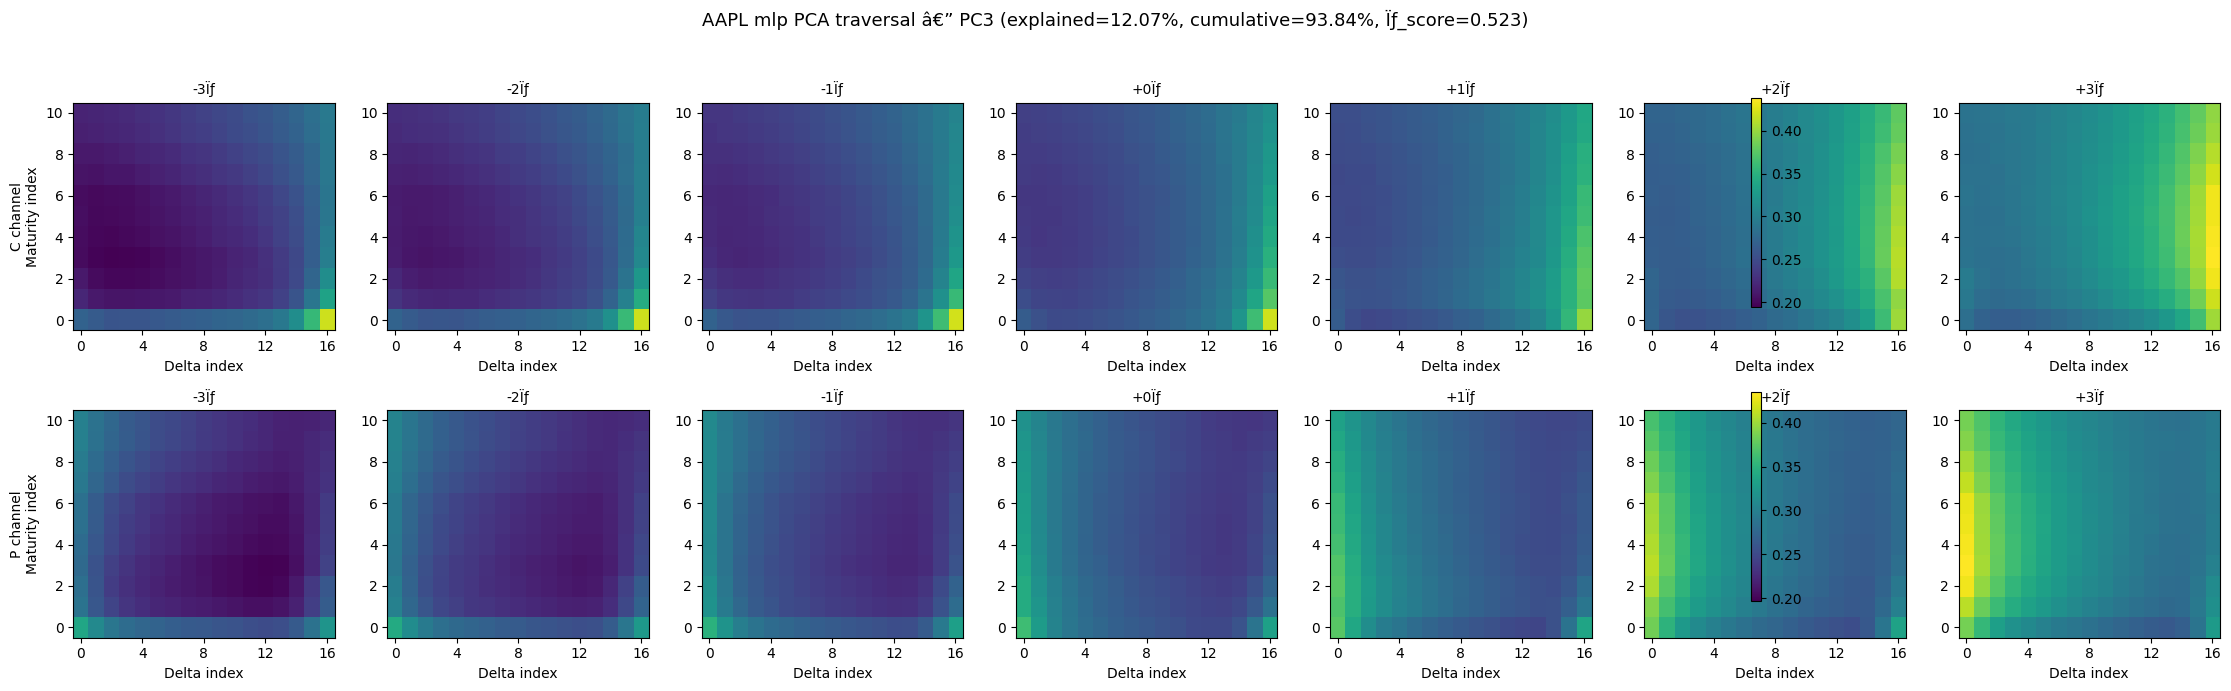

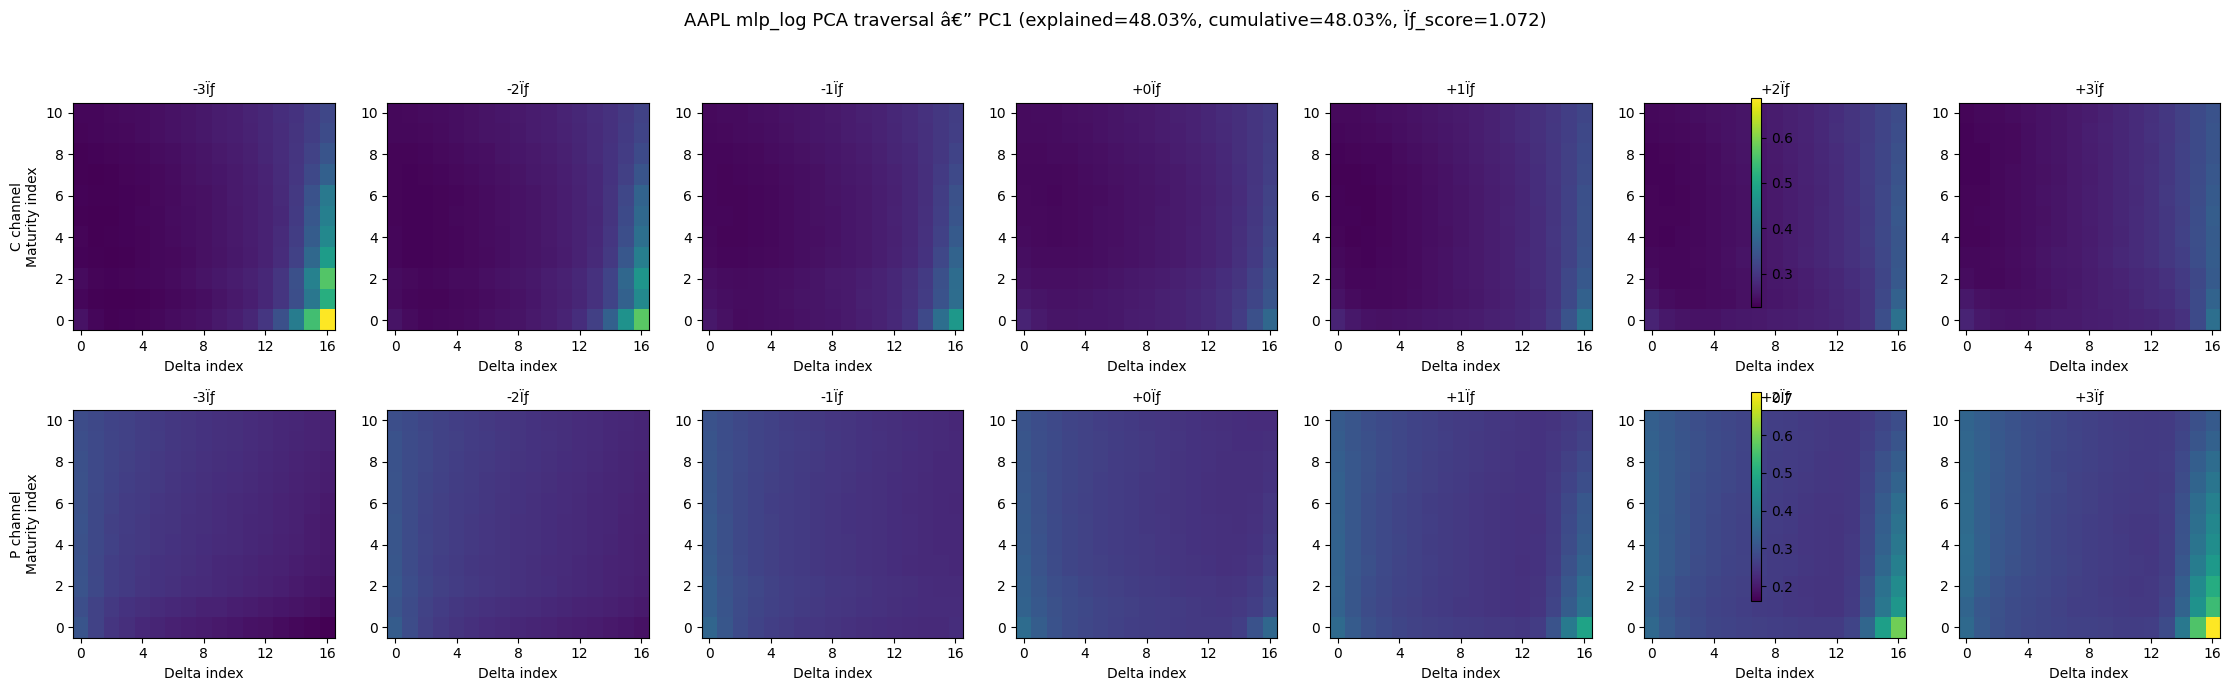

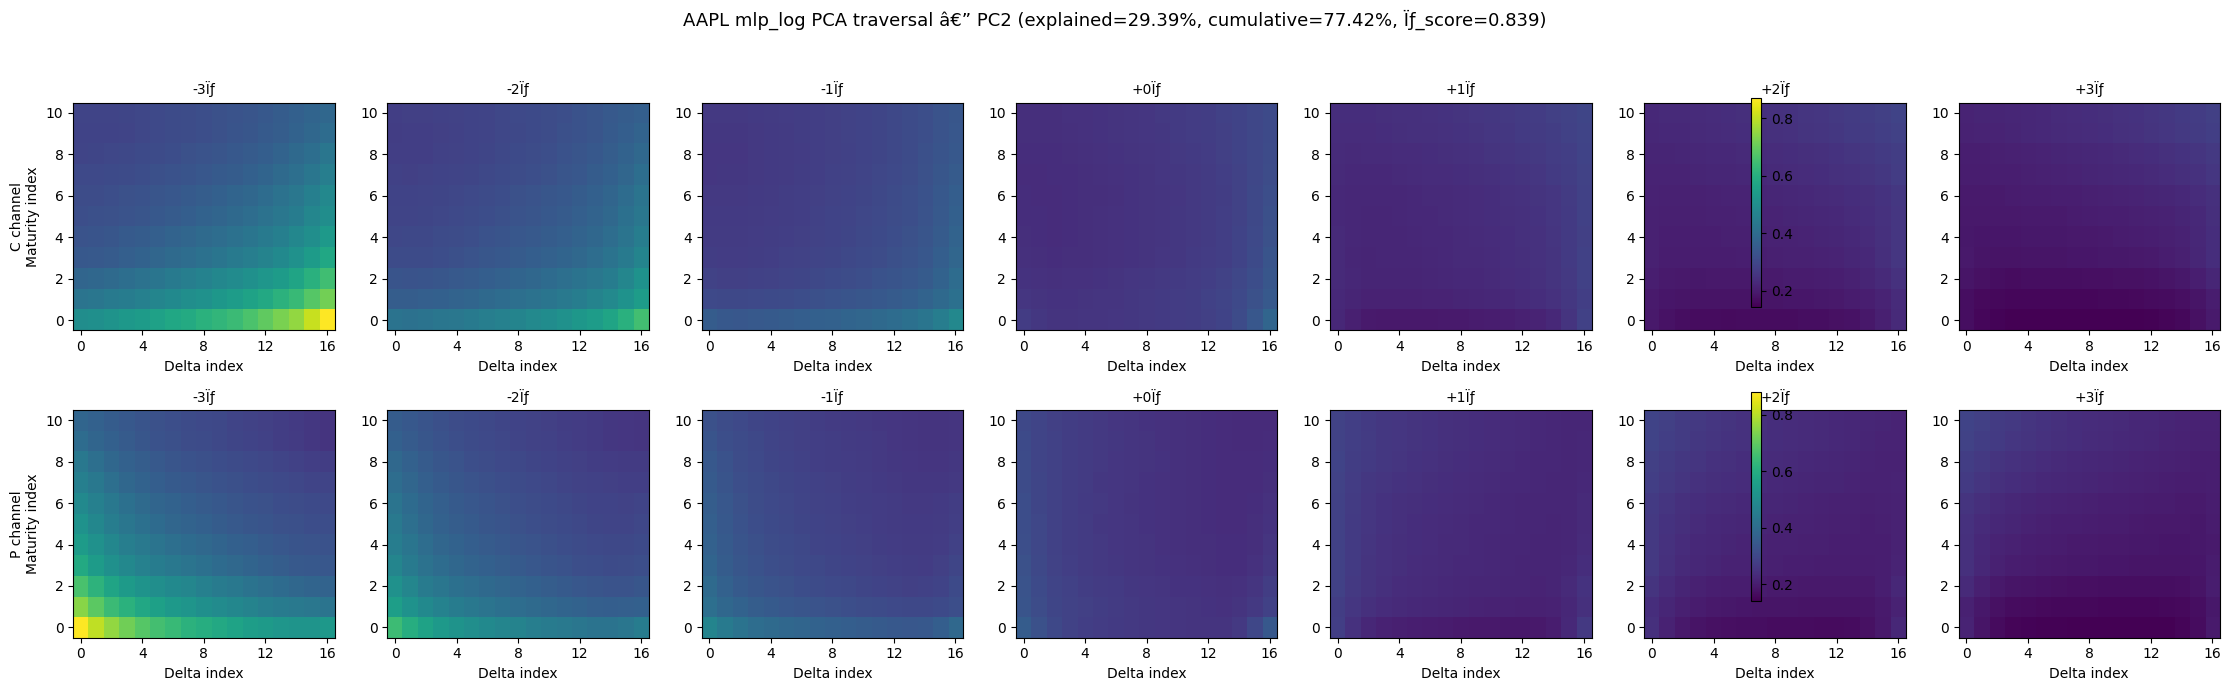

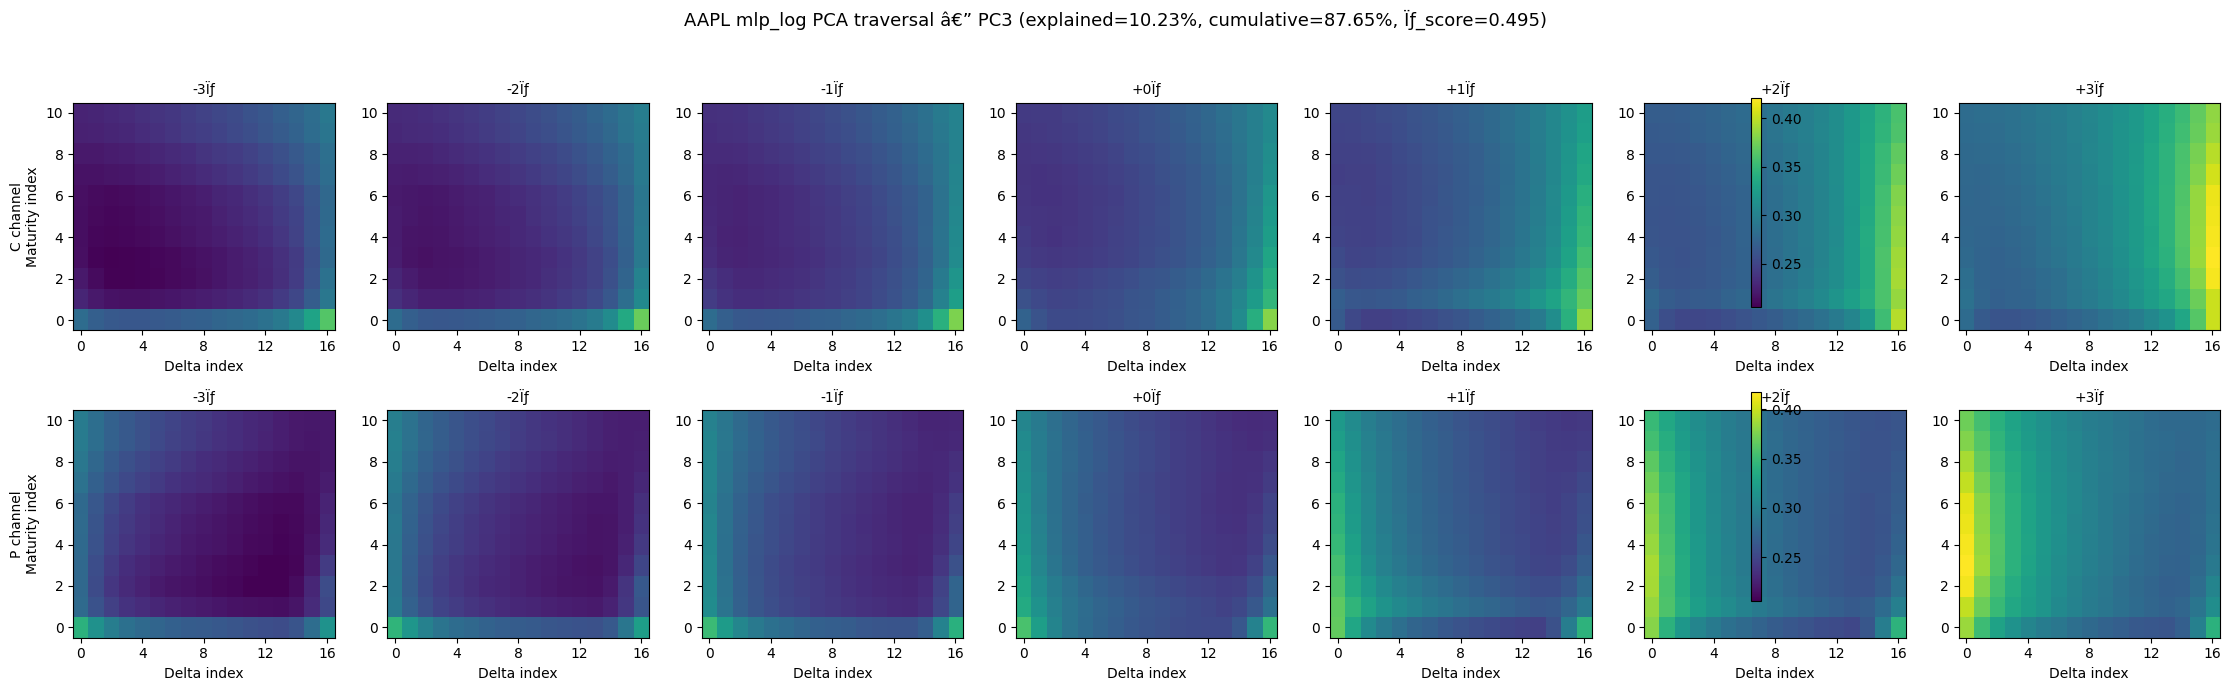

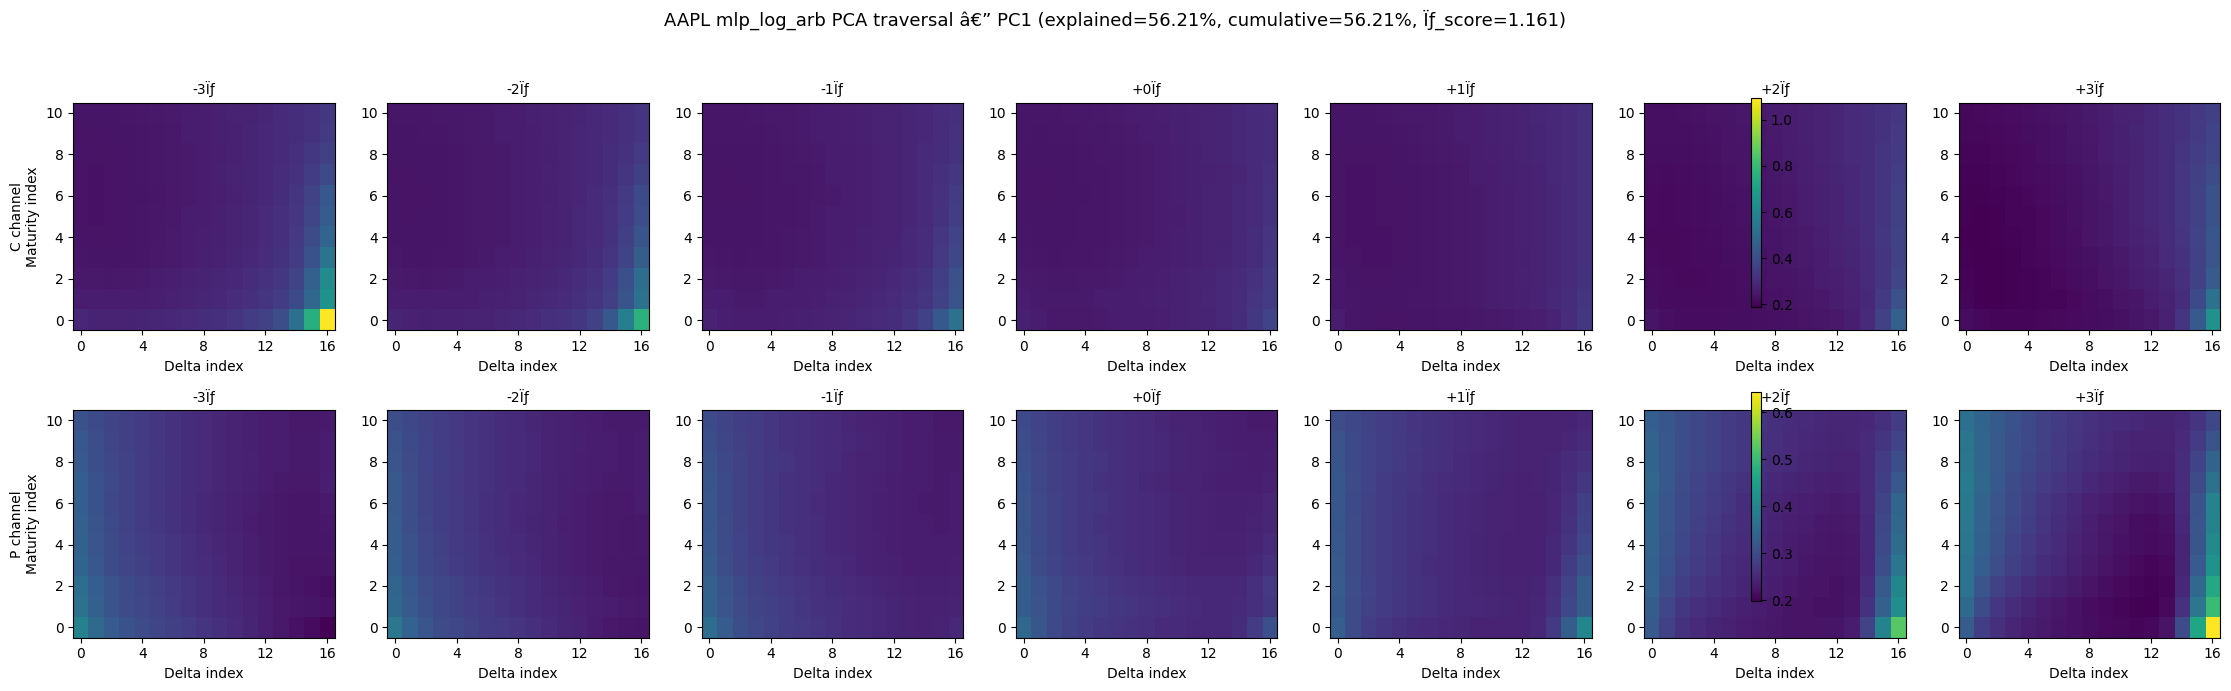

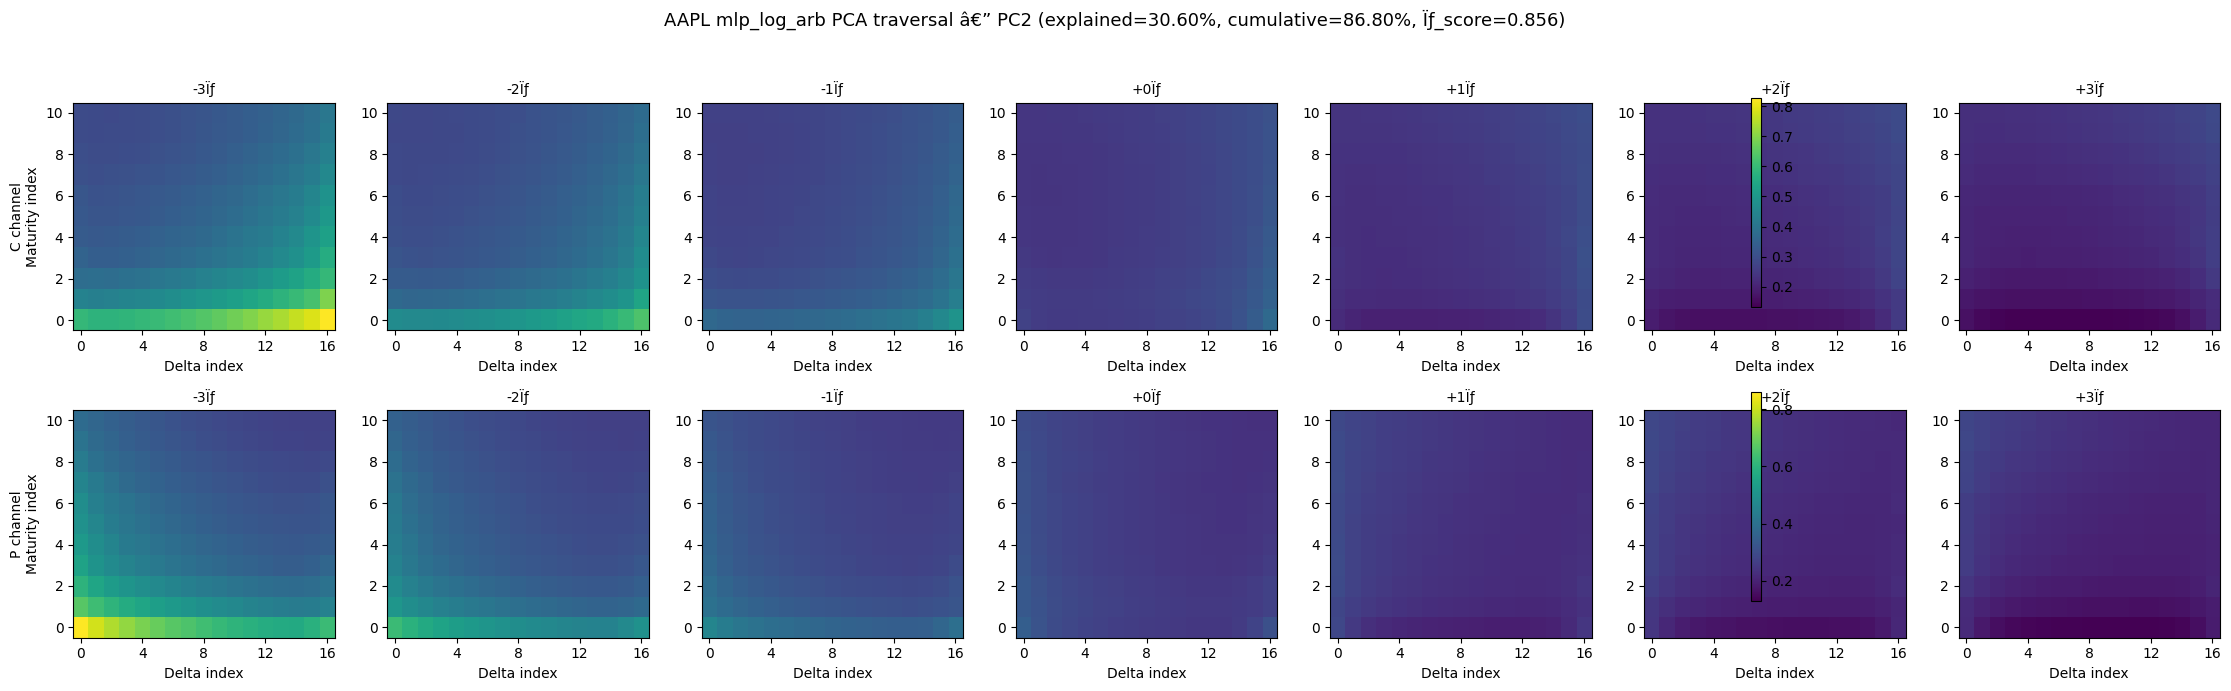

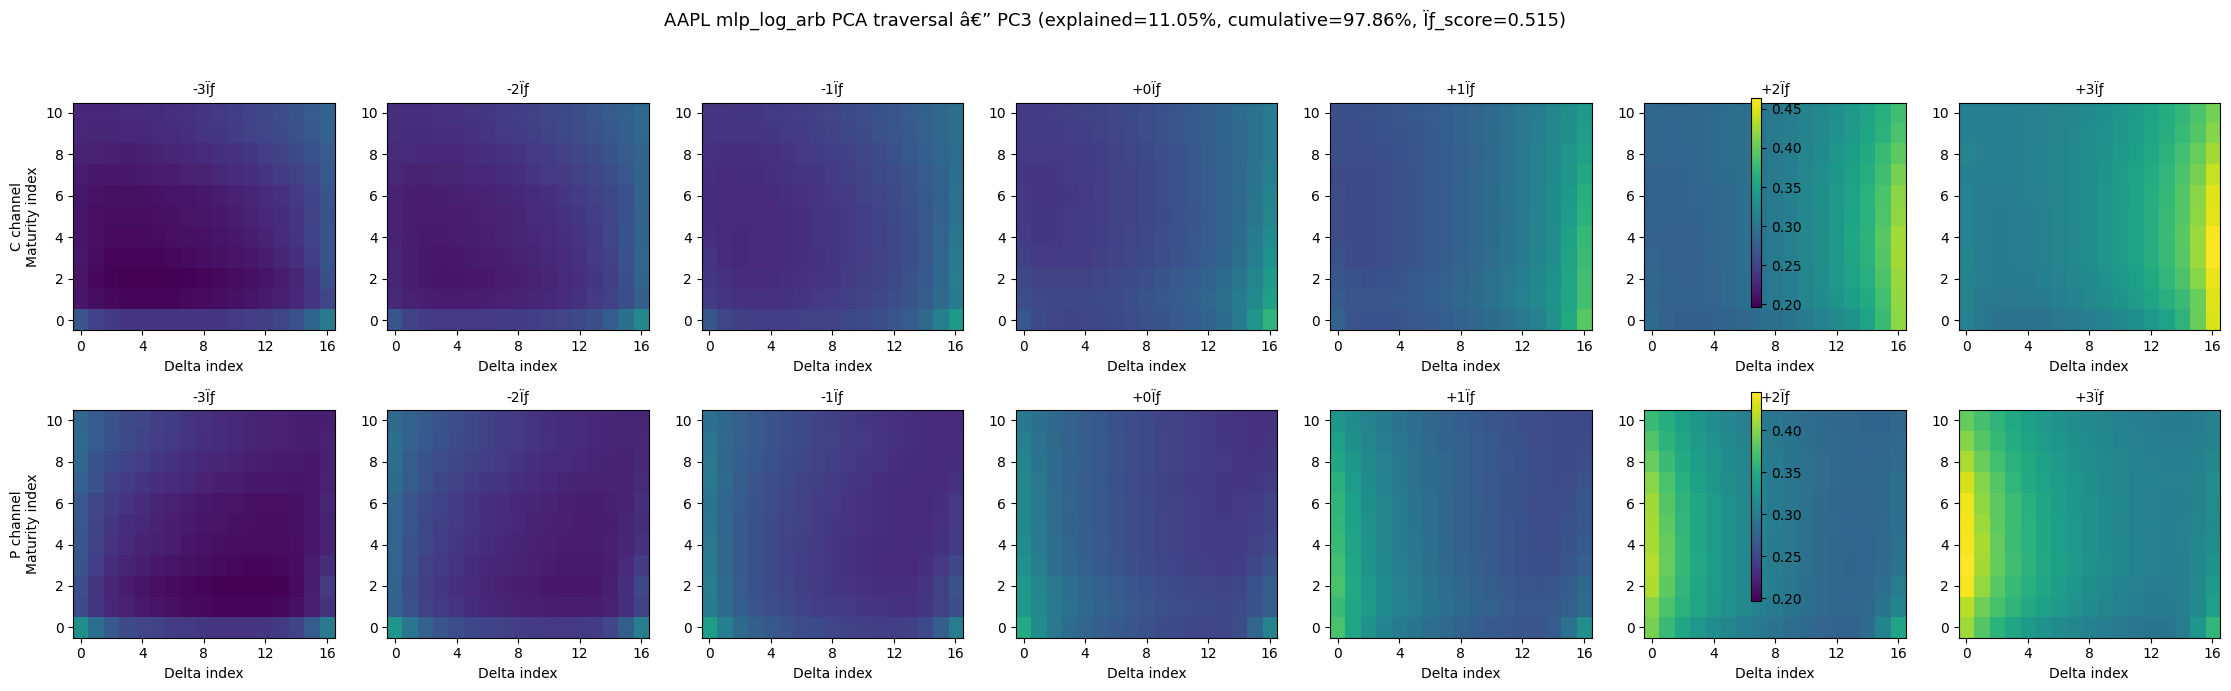

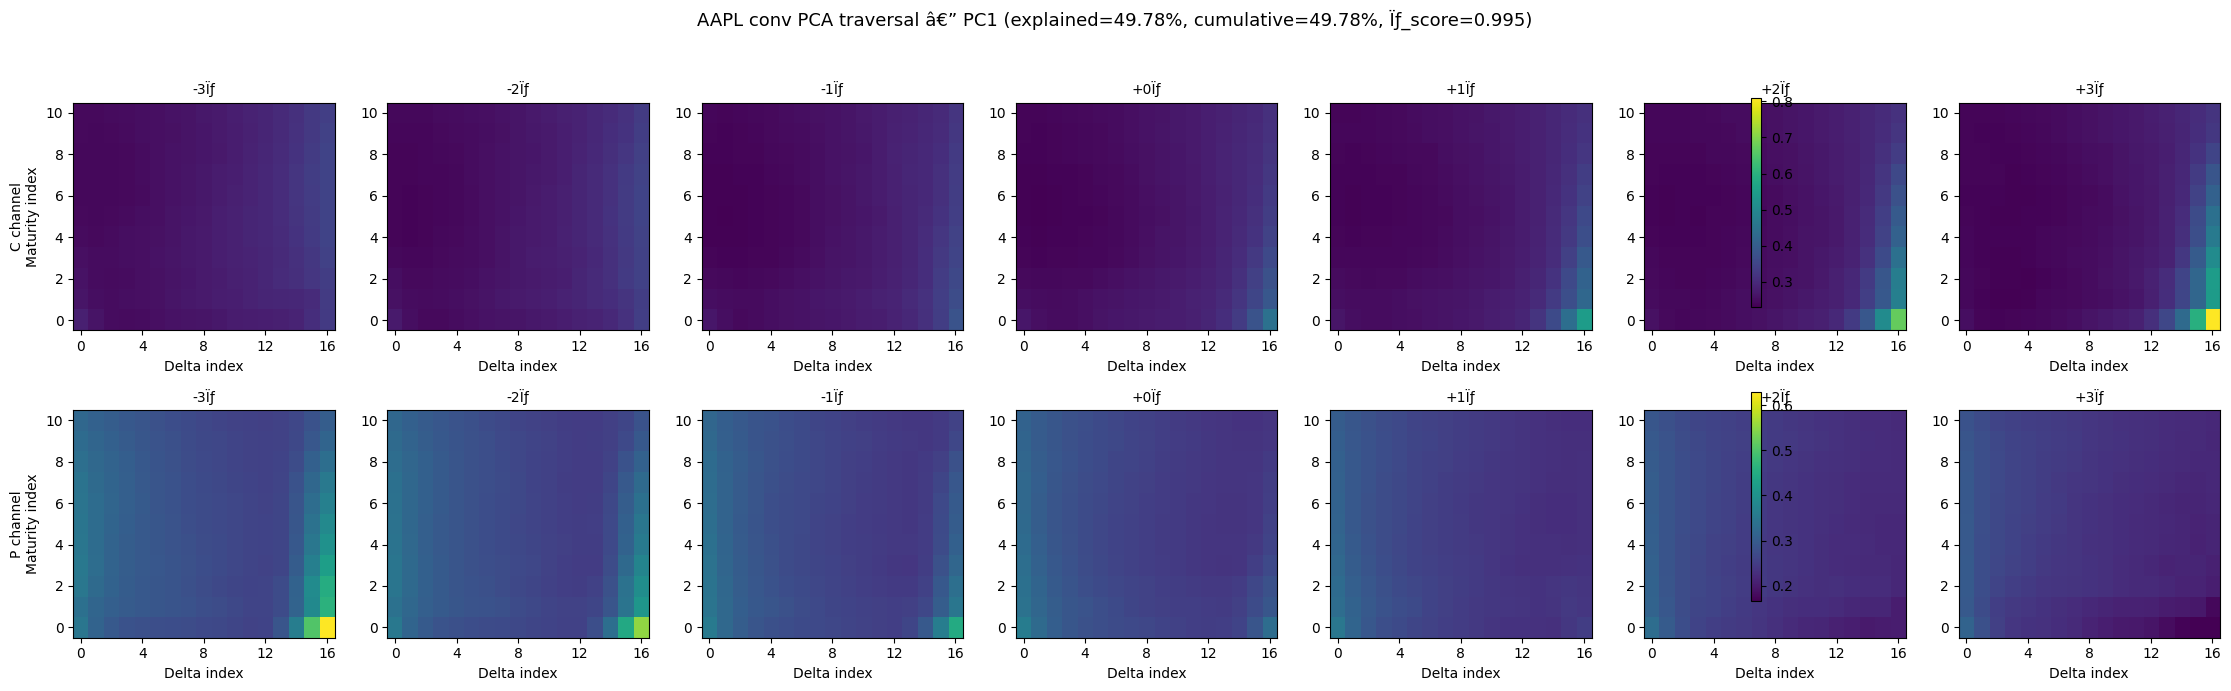

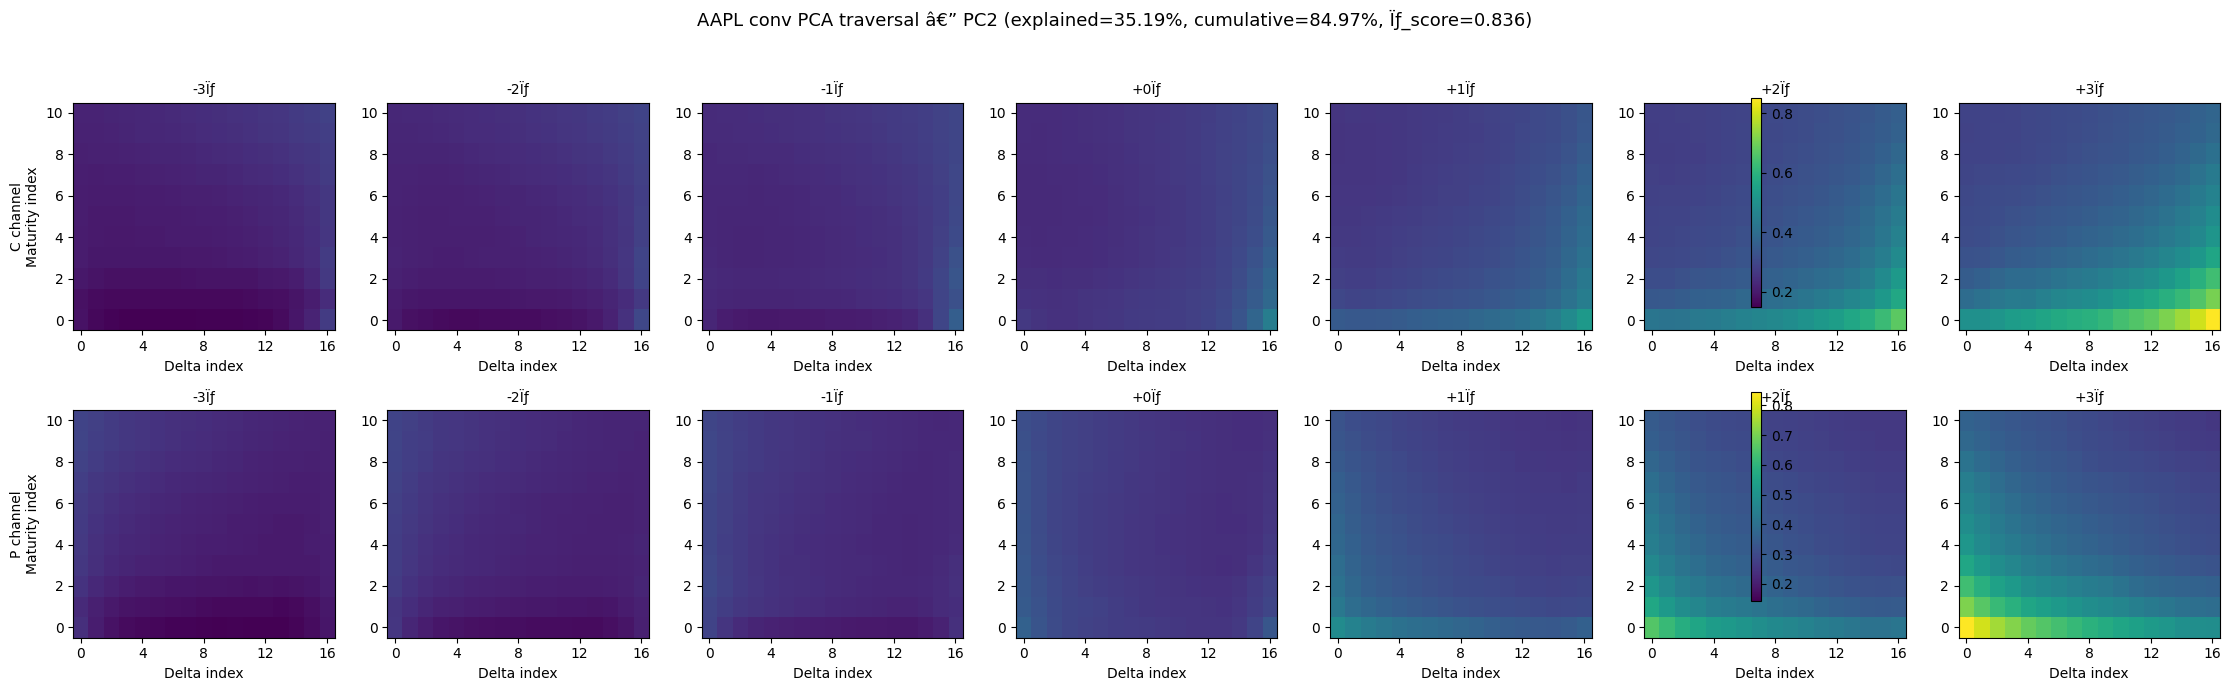

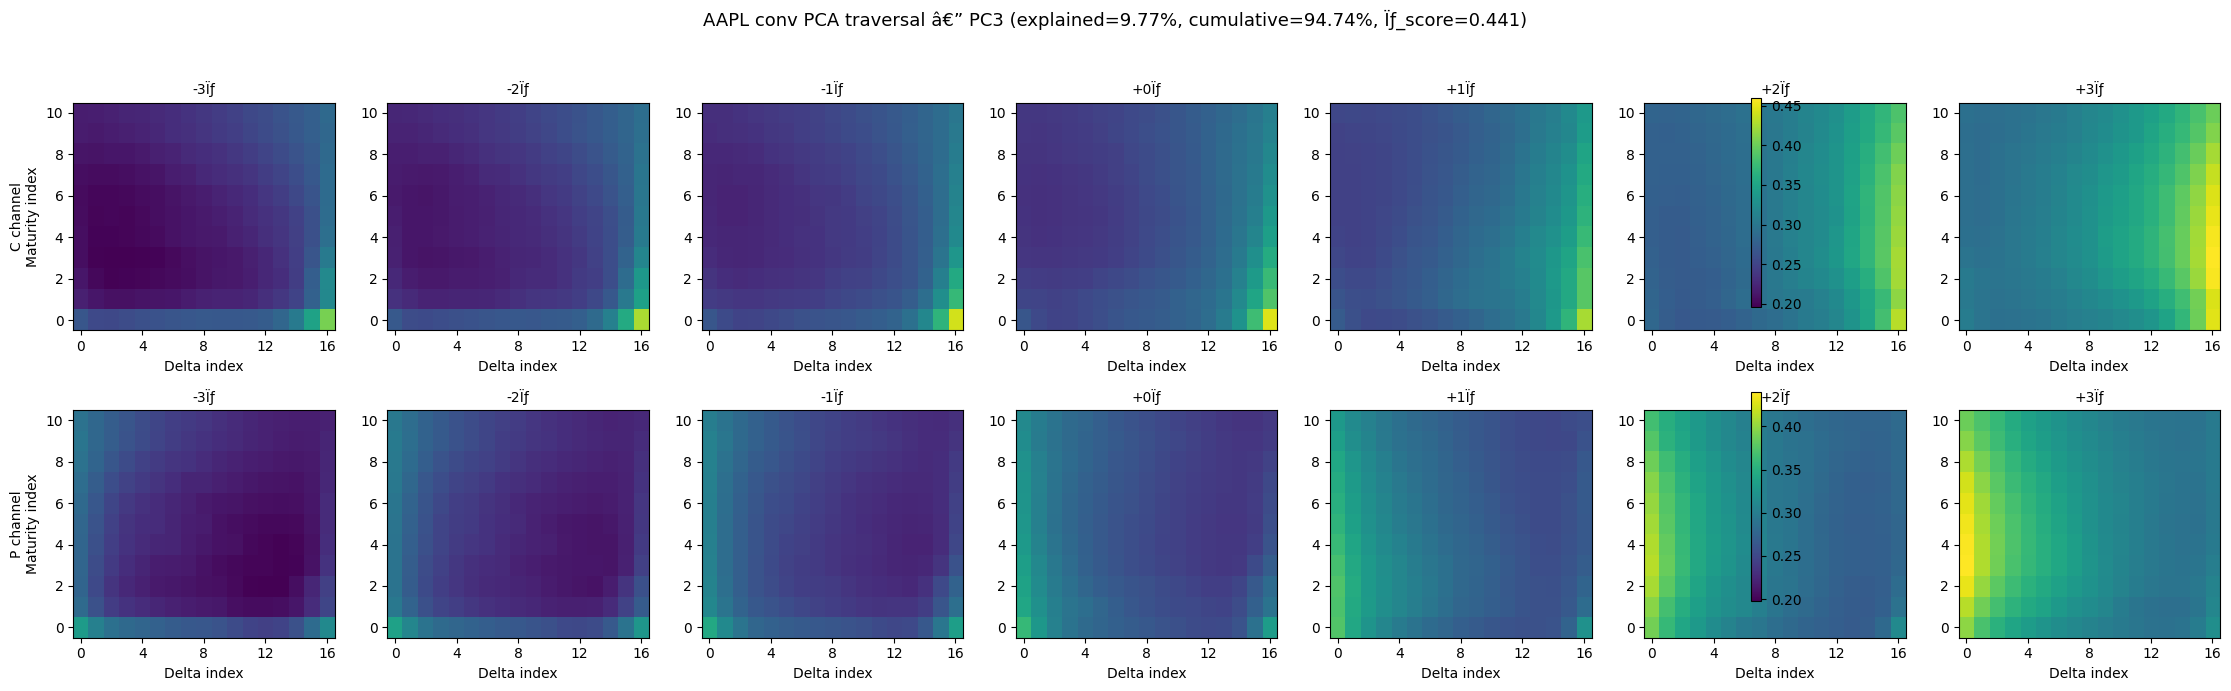

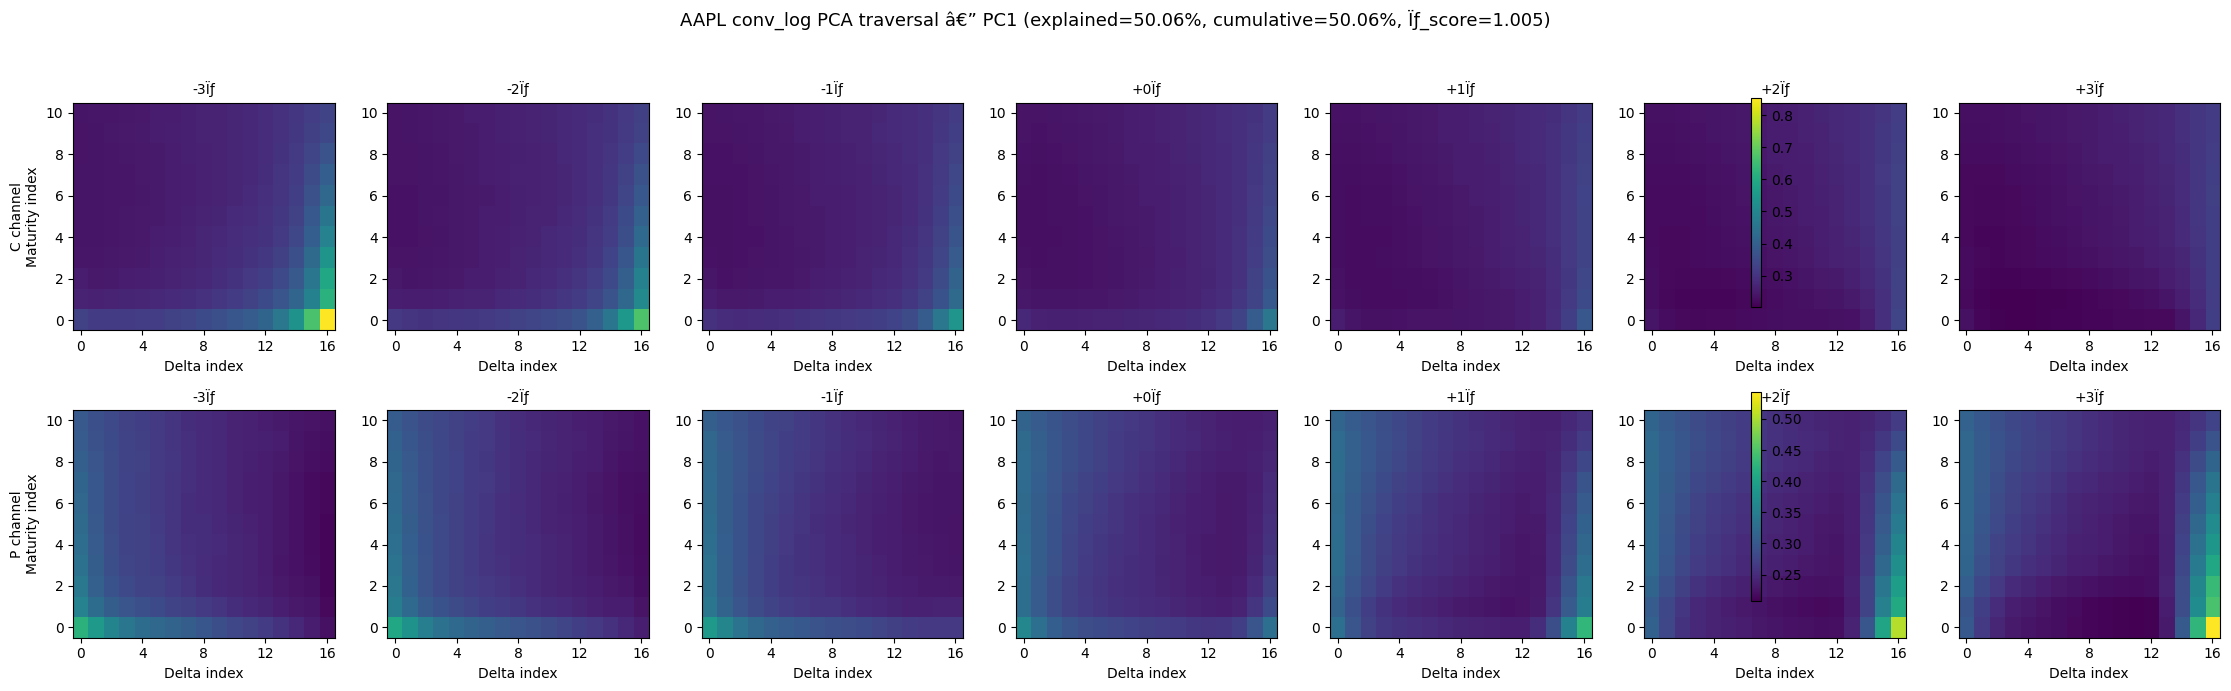

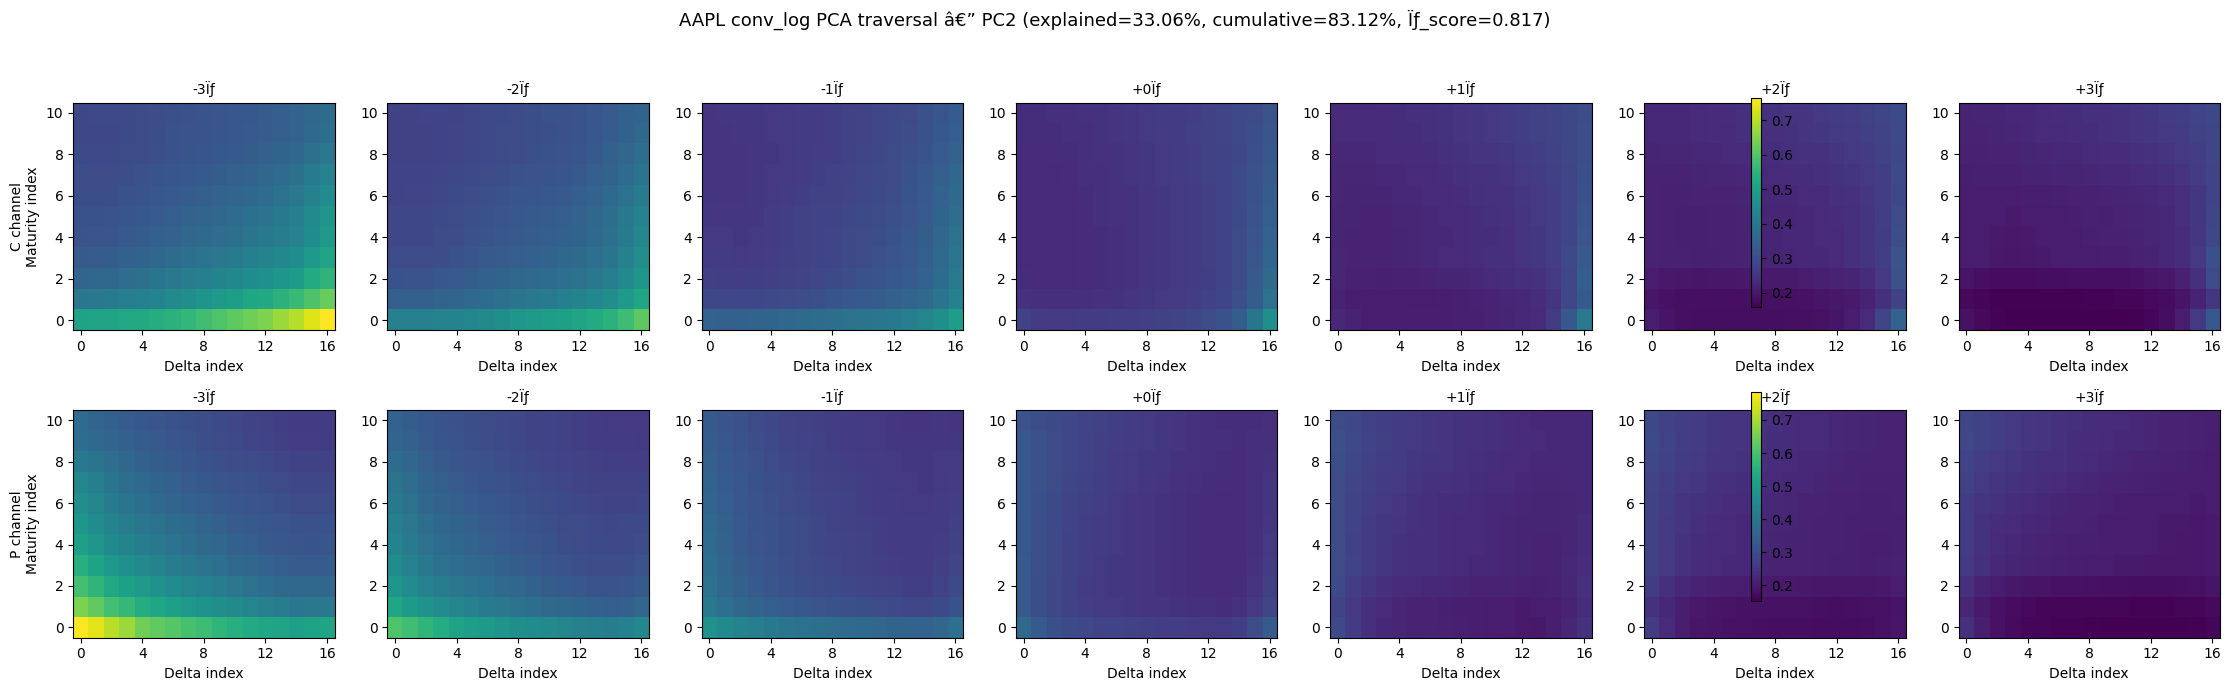

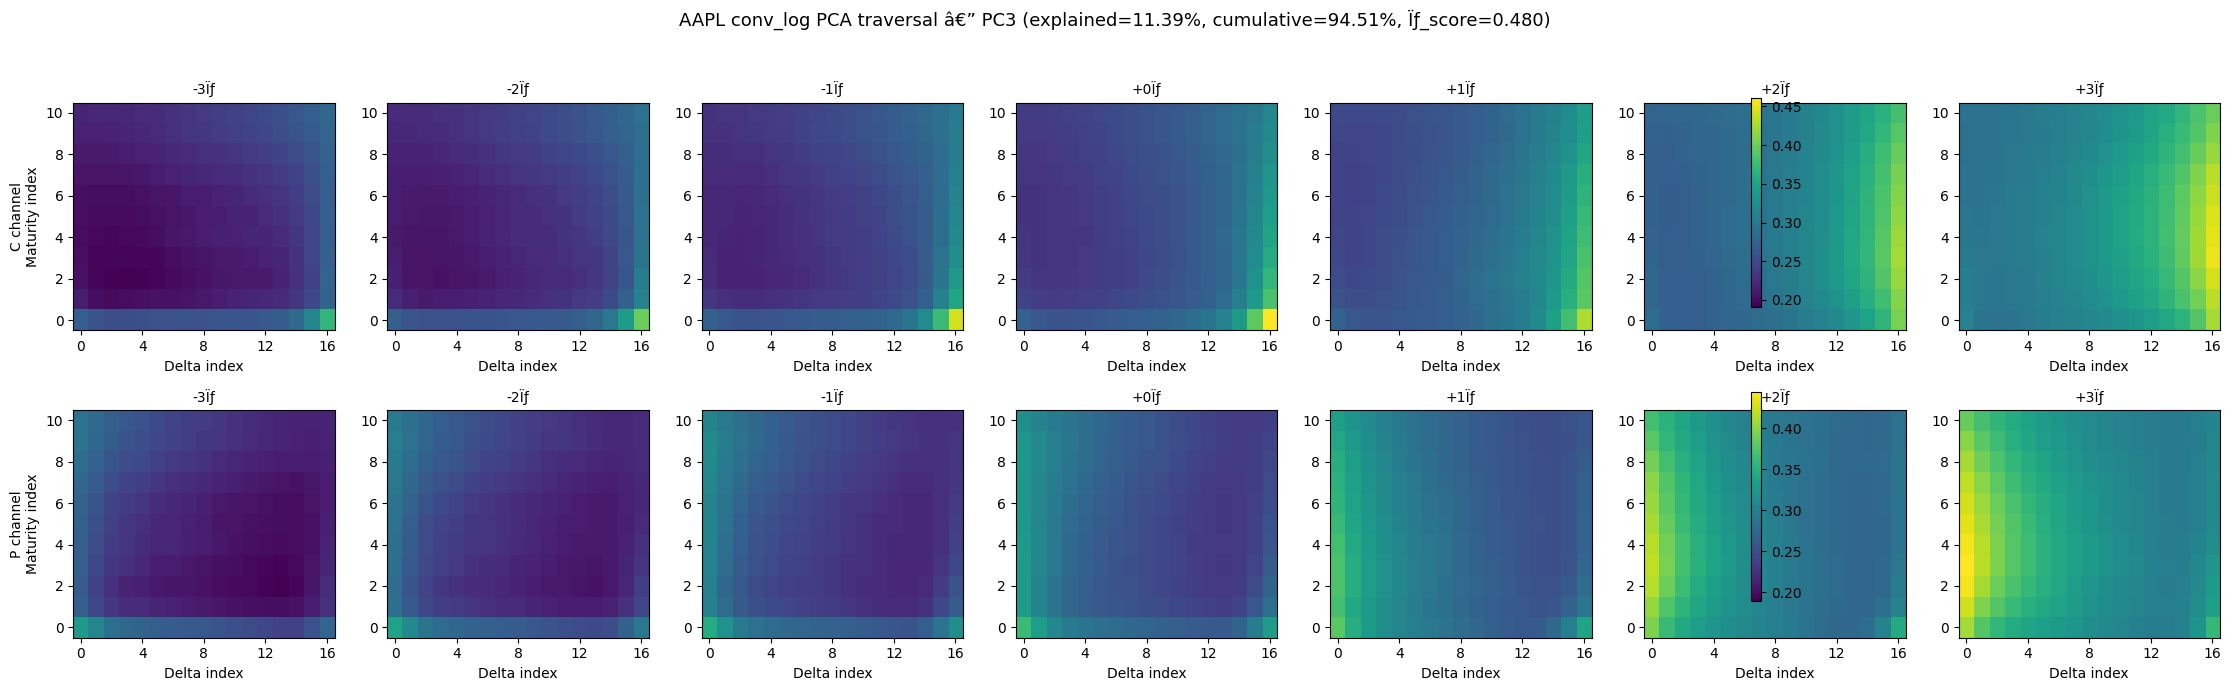

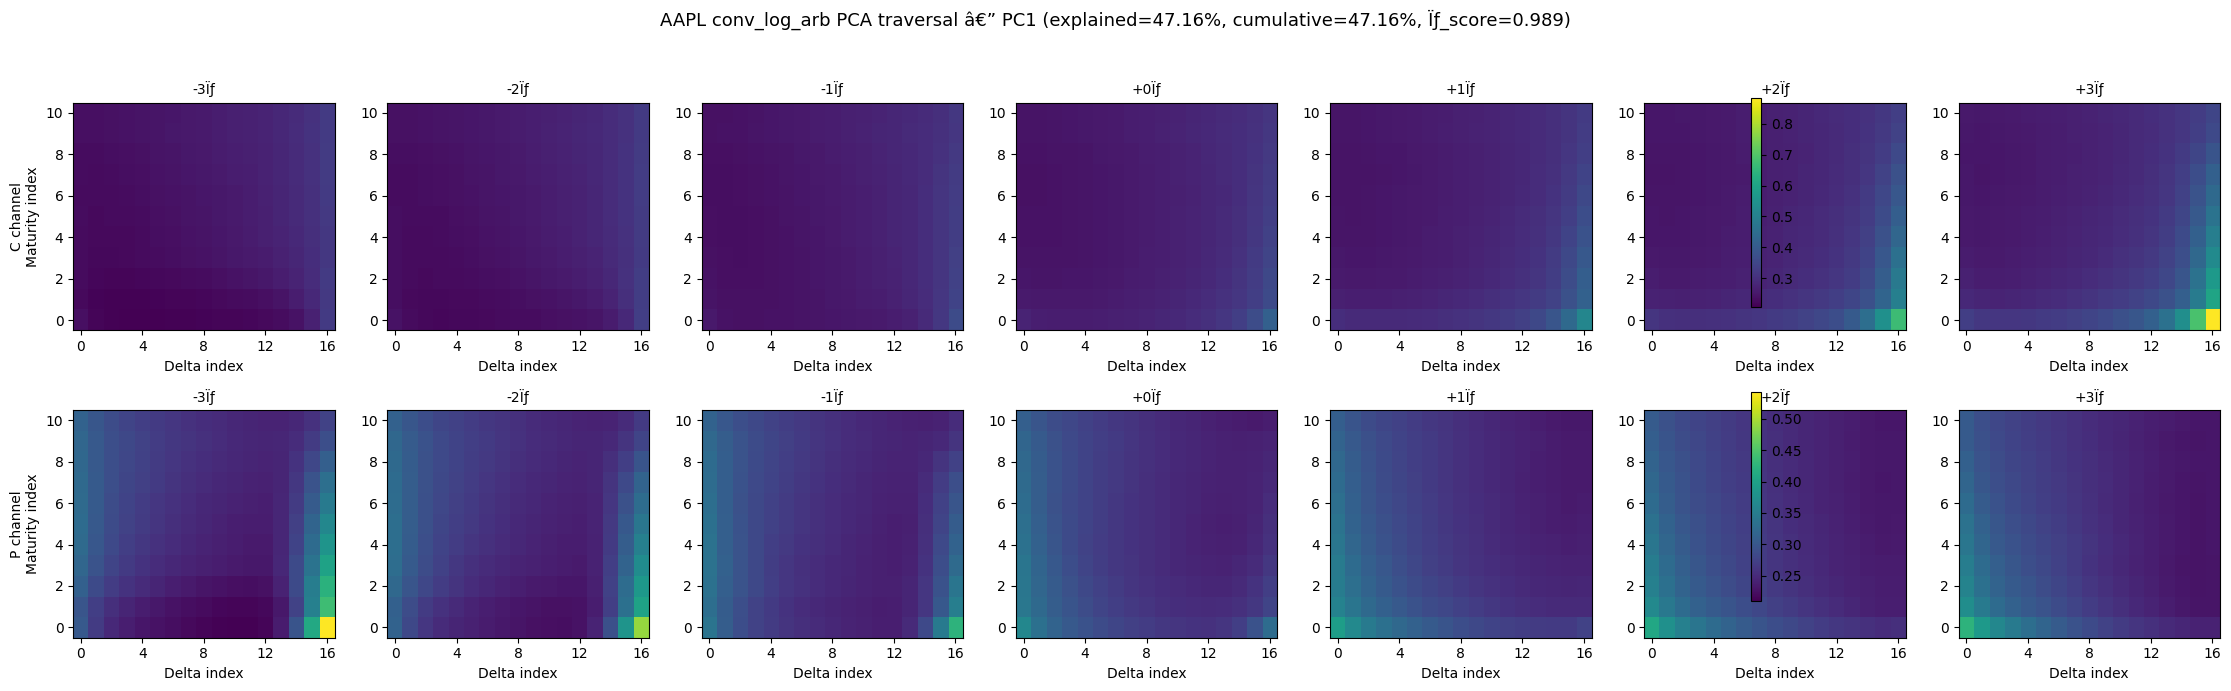

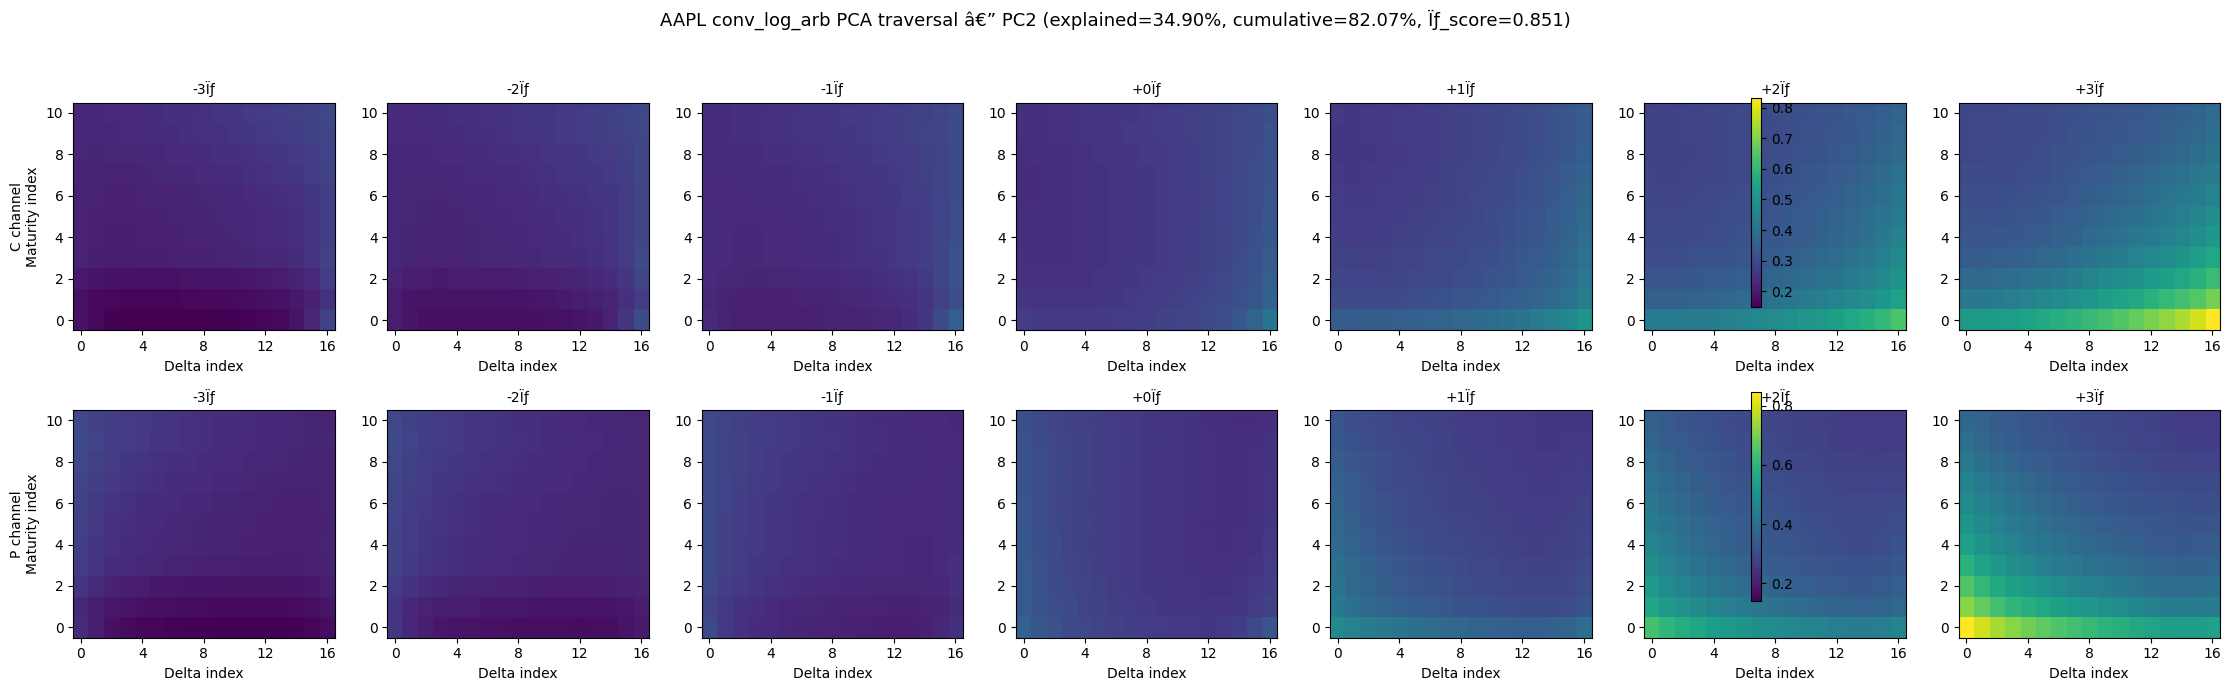

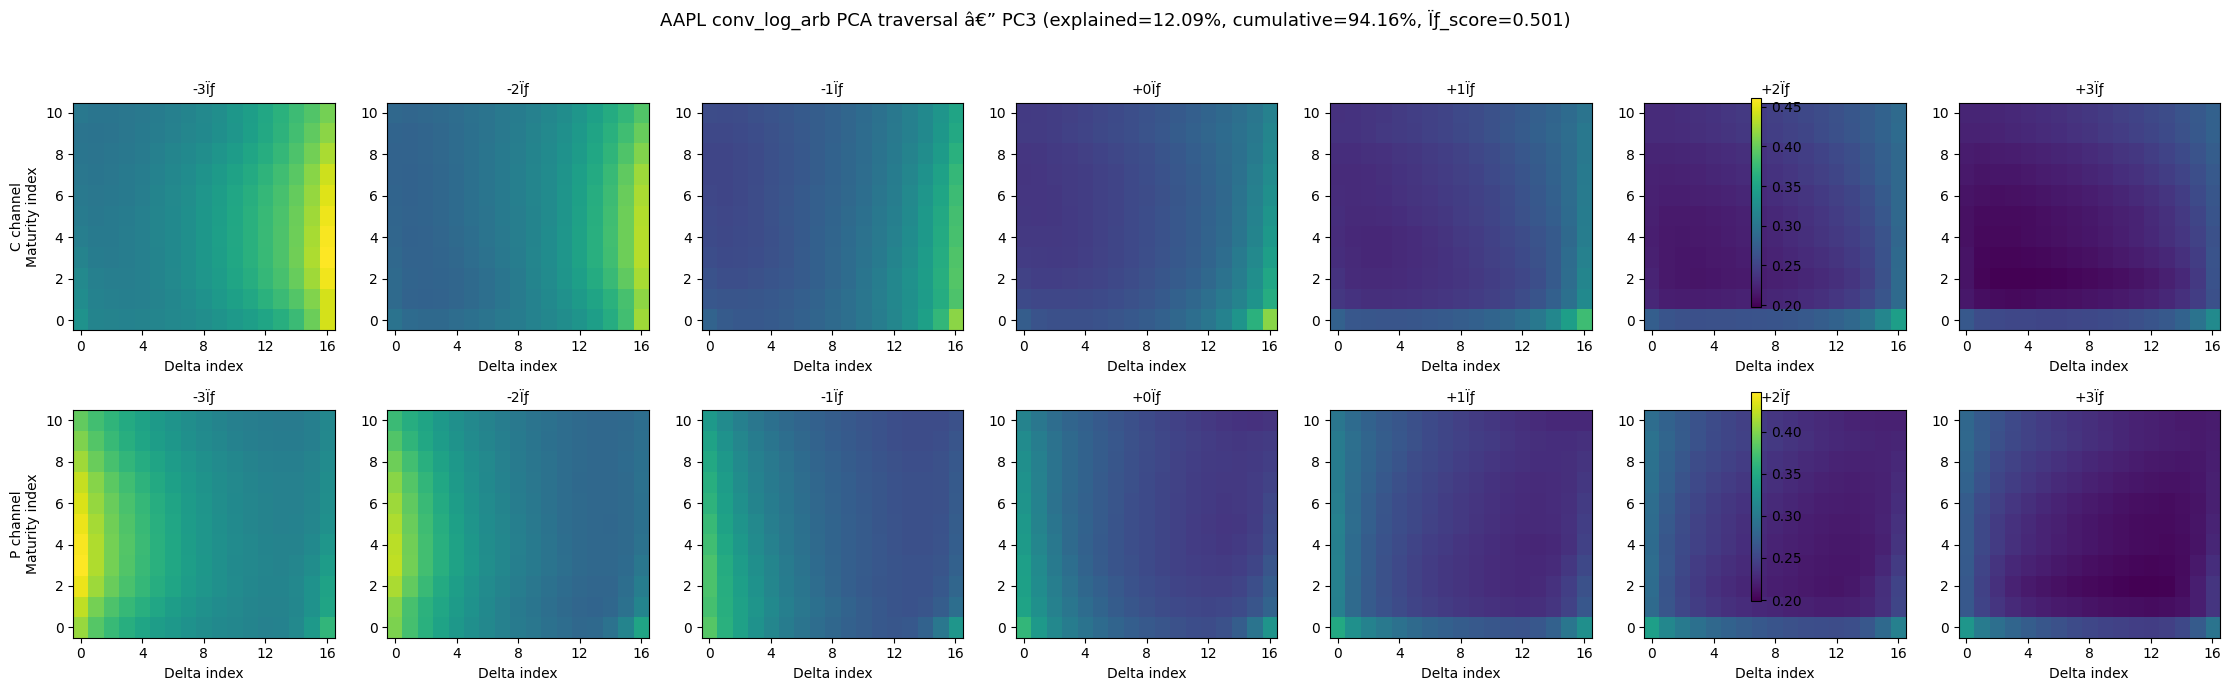

Saved PCA traversal metadata table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\latent_pca_traversal_axes_AAPL.csv
Saved PCA traversal plots: 18 files
  C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_pca_traversal_mlp_pc1_AAPL.png
  C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_pca_traversal_mlp_pc2_AAPL.png
  C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_pca_traversal_mlp_pc3_AAPL.png
  C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_pca_traversal_mlp_log_pc1_AAPL.png
  C:\Users\Admin\OneDrive\Desktop\F

,variant,pc,pc_idx,explained_variance_ratio,cumulative_explained_variance_ratio,pc_score_std,sigma_steps,plot_file
0,conv,PC1,1,0.497822,0.497822,0.994808,"-3,-2,-1,0,1,2,3",artifacts\validation\latent_analysis\AAPL\plot...
1,conv,PC2,2,0.351880,0.849702,0.836372,"-3,-2,-1,0,1,2,3",artifacts\validation\latent_analysis\AAPL\plot...
2,conv,PC3,3,0.097713,0.947416,0.440737,"-3,-2,-1,0,1,2,3",artifacts\validation\latent_analysis\AAPL\plot...
3,conv_log,PC1,1,0.500596,0.500596,1.005451,"-3,-2,-1,0,1,2,3",artifacts\validation\latent_analysis\AAPL\plot...
4,conv_log,PC2,2,0.330620,0.831216,0.817111,"-3,-2,-1,0,1,2,3",artifacts\validation\latent_analysis\AAPL\plot...
5,conv_log,PC3,3,0.113892,0.945108,0.479584,"-3,-2,-1,0,1,2,3",artifacts\validation\latent_analysis\AAPL\plot...
6,conv_log_arb,PC1,1,0.471635,0.471635,0.989338,"-3,-2,-1,0,1,2,3",artifacts\validation\latent_analysis\AAPL\plot...
7,conv_log_arb,PC2,2,0.349047,0.820682,0.851107,"-3,-2,-1,0,1,2,3",artifacts\validation\latent_analysis\AAPL\plot...
8,conv_log_arb,PC3,3,0.120931,0.941613,0.500968,"-3,-2,-1,0,1,2,3",artifacts\validation\latent_analysis\AAPL\plot...
9,mlp,PC1,1,0.490034,0.490034,1.053802,"-3,-2,-1,0,1,2,3",artifacts\validation\latent_analysis\AAPL\plot...


In [12]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from src.models import create_model
from src.utils.scaler import ChannelStandardizer

PCA_TRAVERSAL_STEPS = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=np.float32)
PCA_TRAVERSAL_PC_IDXS = [0, 1, 2]


def _load_model_scaler_and_latents(variant: str):
    checkpoint_path = TRAIN_ROOT / variant / "vae_checkpoint.pt"
    latent_path = EVAL_ROOT / variant / "test_latents.pt"

    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint not found for {variant}: {checkpoint_path}")
    if not latent_path.exists():
        raise FileNotFoundError(f"Latent artifact not found for {variant}: {latent_path}")

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    train_args = checkpoint["args"]
    input_shape = tuple(checkpoint["input_shape"])
    model_type = checkpoint.get("model_type", train_args.get("model_type", "mlp"))

    model = create_model(
        model_type=model_type,
        in_shape=input_shape,
        latent_dim=train_args.get("latent_dim", 24),
        hidden_dims=tuple(train_args.get("hidden_dims", [384, 192])),
        channels=tuple(train_args.get("channels", [32, 64, 128])),
        fc_dim=train_args.get("fc_dim", 128),
        batchnorm=not train_args.get("no_batchnorm", False),
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    scaler_state = checkpoint.get("scaler")
    if scaler_state is None or not isinstance(scaler_state, dict):
        raise ValueError(f"{variant}: checkpoint scaler state missing or invalid")

    scaler = ChannelStandardizer(
        log_transform=bool(scaler_state.get("log_transform", train_args.get("log_transform", False)))
    )
    scaler.mean = torch.tensor(scaler_state["mean"], dtype=torch.float32, device=DEVICE)
    scaler.std = torch.tensor(scaler_state["std"], dtype=torch.float32, device=DEVICE)

    latent_payload = torch.load(latent_path, map_location="cpu", weights_only=False)
    mus_np = latent_payload["mus"].detach().cpu().numpy() if isinstance(latent_payload["mus"], torch.Tensor) else np.asarray(latent_payload["mus"])
    logvars_np = latent_payload["logvars"].detach().cpu().numpy() if isinstance(latent_payload["logvars"], torch.Tensor) else np.asarray(latent_payload["logvars"])
    latent_dates = pd.to_datetime(pd.Series(latent_payload["dates"])).dt.normalize()

    if mus_np.ndim != 2 or logvars_np.ndim != 2:
        raise ValueError(f"{variant}: expected 2D mus/logvars, got {mus_np.shape} and {logvars_np.shape}")
    if mus_np.shape != logvars_np.shape:
        raise ValueError(f"{variant}: mus/logvars shape mismatch: {mus_np.shape} vs {logvars_np.shape}")

    return model, scaler, mus_np, logvars_np, latent_dates


if "features_df" not in globals():
    raise RuntimeError("features_df is not available. Run earlier blocks first.")
if "days_grid" not in globals() or "delta_grid" not in globals() or "cp_order" not in globals():
    raise RuntimeError("Grid metadata is missing. Run the market-feature block first.")

expected_dates = pd.to_datetime(features_df["date"]).dt.normalize()
pca_traversal_records = []
pca_traversal_plot_paths = []

for variant in VARIANTS:
    model, scaler, mus_np, _, latent_dates = _load_model_scaler_and_latents(variant)

    if not latent_dates.equals(expected_dates):
        raise ValueError(f"{variant}: latent dates are not aligned with feature dates")

    pca = PCA(n_components=mus_np.shape[1])
    scores = pca.fit_transform(mus_np)
    latent_mean = mus_np.mean(axis=0).astype(np.float32)

    for pc_idx in PCA_TRAVERSAL_PC_IDXS:
        pc_label = f"PC{pc_idx + 1}"
        explained_ratio = float(pca.explained_variance_ratio_[pc_idx])
        cumulative_ratio = float(np.cumsum(pca.explained_variance_ratio_)[pc_idx])

        component = pca.components_[pc_idx].astype(np.float32)
        component_norm = float(np.linalg.norm(component))
        if component_norm == 0.0:
            raise ValueError(f"{variant} {pc_label}: zero-norm PCA component")
        component = component / component_norm

        pc_std = float(scores[:, pc_idx].std(ddof=0))
        if pc_std == 0.0:
            pc_std = 1e-6

        z_batch = np.repeat(latent_mean[None, :], len(PCA_TRAVERSAL_STEPS), axis=0)
        for j, step in enumerate(PCA_TRAVERSAL_STEPS):
            z_batch[j] = latent_mean + float(step) * pc_std * component

        with torch.no_grad():
            z_tensor = torch.tensor(z_batch, dtype=torch.float32, device=DEVICE)
            recon = model.decode(z_tensor)
            recon_orig = scaler.inverse_transform(recon).detach().cpu().numpy()

        fig, axes = plt.subplots(
            2, len(PCA_TRAVERSAL_STEPS),
            figsize=(3.2 * len(PCA_TRAVERSAL_STEPS), 7.0),
            squeeze=False,
        )

        for c in range(2):
            channel_min = float(np.nanmin(recon_orig[:, c, :, :]))
            channel_max = float(np.nanmax(recon_orig[:, c, :, :]))
            for j, step in enumerate(PCA_TRAVERSAL_STEPS):
                ax = axes[c, j]
                im = ax.imshow(
                    recon_orig[j, c],
                    origin="lower",
                    aspect="auto",
                    cmap="viridis",
                    vmin=channel_min,
                    vmax=channel_max,
                )
                ax.set_title(f"{step:+.0f}σ", fontsize=10)
                if j == 0:
                    channel_name = cp_order[c].upper() if c < len(cp_order) else f"CH{c}"
                    ax.set_ylabel(f"{channel_name} channel\nMaturity index")
                ax.set_xlabel("Delta index")
                ax.set_xticks(range(0, len(delta_grid), 4))
                ax.set_yticks(range(0, len(days_grid), 2))
            fig.colorbar(im, ax=axes[c, :], shrink=0.85, pad=0.01)

        fig.suptitle(
            (
                f"{TICKER} {variant} PCA traversal — {pc_label} "
                f"(explained={explained_ratio:.2%}, cumulative={cumulative_ratio:.2%}, σ_score={pc_std:.3f})"
            ),
            fontsize=13,
        )
        fig.tight_layout(rect=[0, 0, 1, 0.95])

        plot_path = PLOTS_DIR / f"latent_pca_traversal_{variant}_{pc_label.lower()}_{TICKER}.png"
        fig.savefig(plot_path, dpi=200, bbox_inches="tight")
        pca_traversal_plot_paths.append(plot_path)
        plt.show()

        pca_traversal_records.append(
            {
                "variant": variant,
                "pc": pc_label,
                "pc_idx": pc_idx + 1,
                "explained_variance_ratio": explained_ratio,
                "cumulative_explained_variance_ratio": cumulative_ratio,
                "pc_score_std": pc_std,
                "sigma_steps": ",".join([str(int(s)) for s in PCA_TRAVERSAL_STEPS]),
                "plot_file": str(plot_path.relative_to(ROOT)),
            }
        )

pca_traversal_df = pd.DataFrame(pca_traversal_records).sort_values(["variant", "pc_idx"]).reset_index(drop=True)
pca_traversal_csv = TABLES_DIR / f"latent_pca_traversal_axes_{TICKER}.csv"
pca_traversal_df.to_csv(pca_traversal_csv, index=False)

print(f"Saved PCA traversal metadata table to: {pca_traversal_csv}")
print(f"Saved PCA traversal plots: {len(pca_traversal_plot_paths)} files")
for path in pca_traversal_plot_paths:
    print(f"  {path}")

display(pca_traversal_df)

## 9. Decoder Jacobian Sensitivity Maps (D3)

This block computes local decoder sensitivity maps
$\partial \sigma_{c,h,w} / \partial z_j$ at the empirical latent mean for each variant,
focused on the top KL-active dimensions.

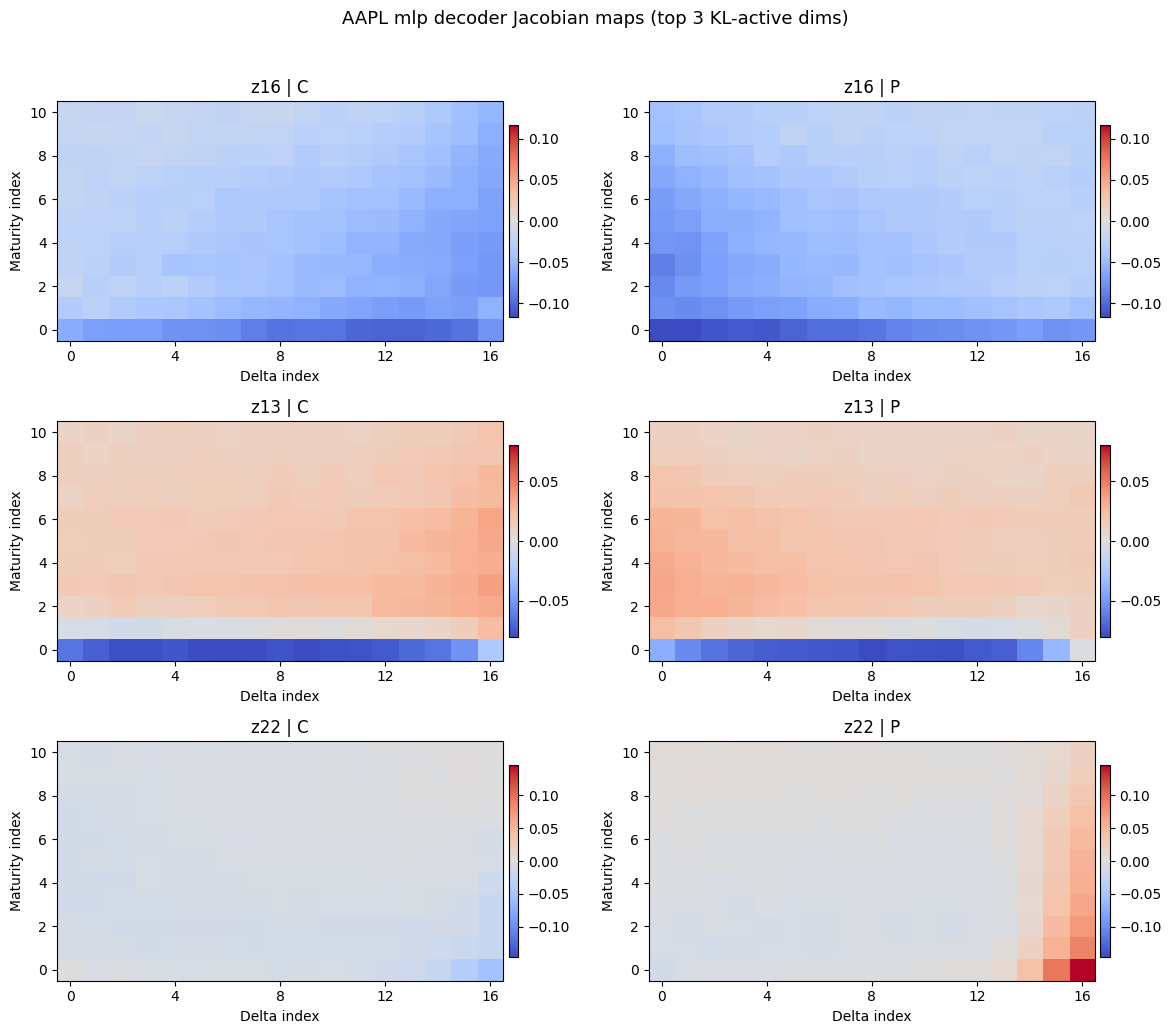

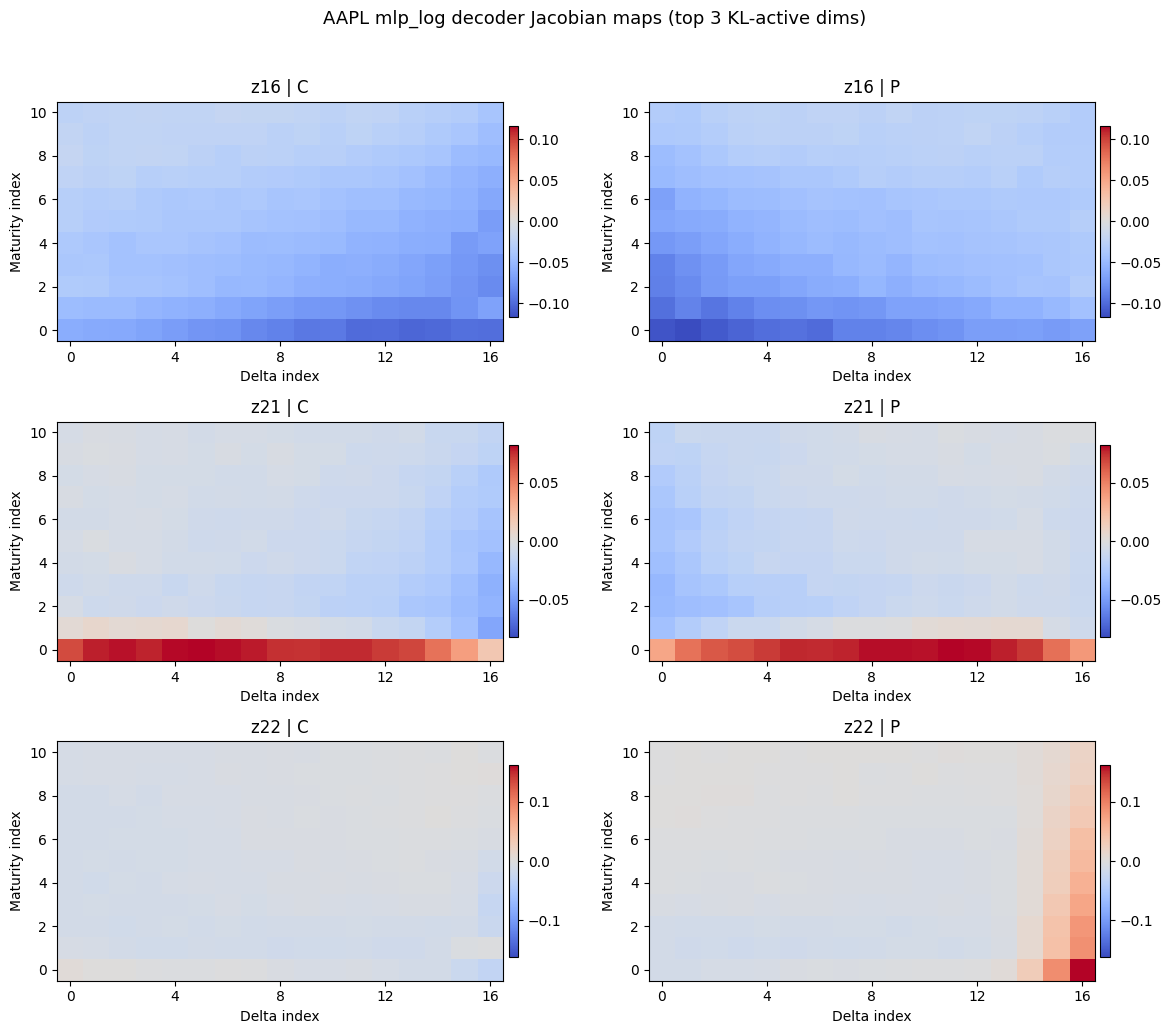

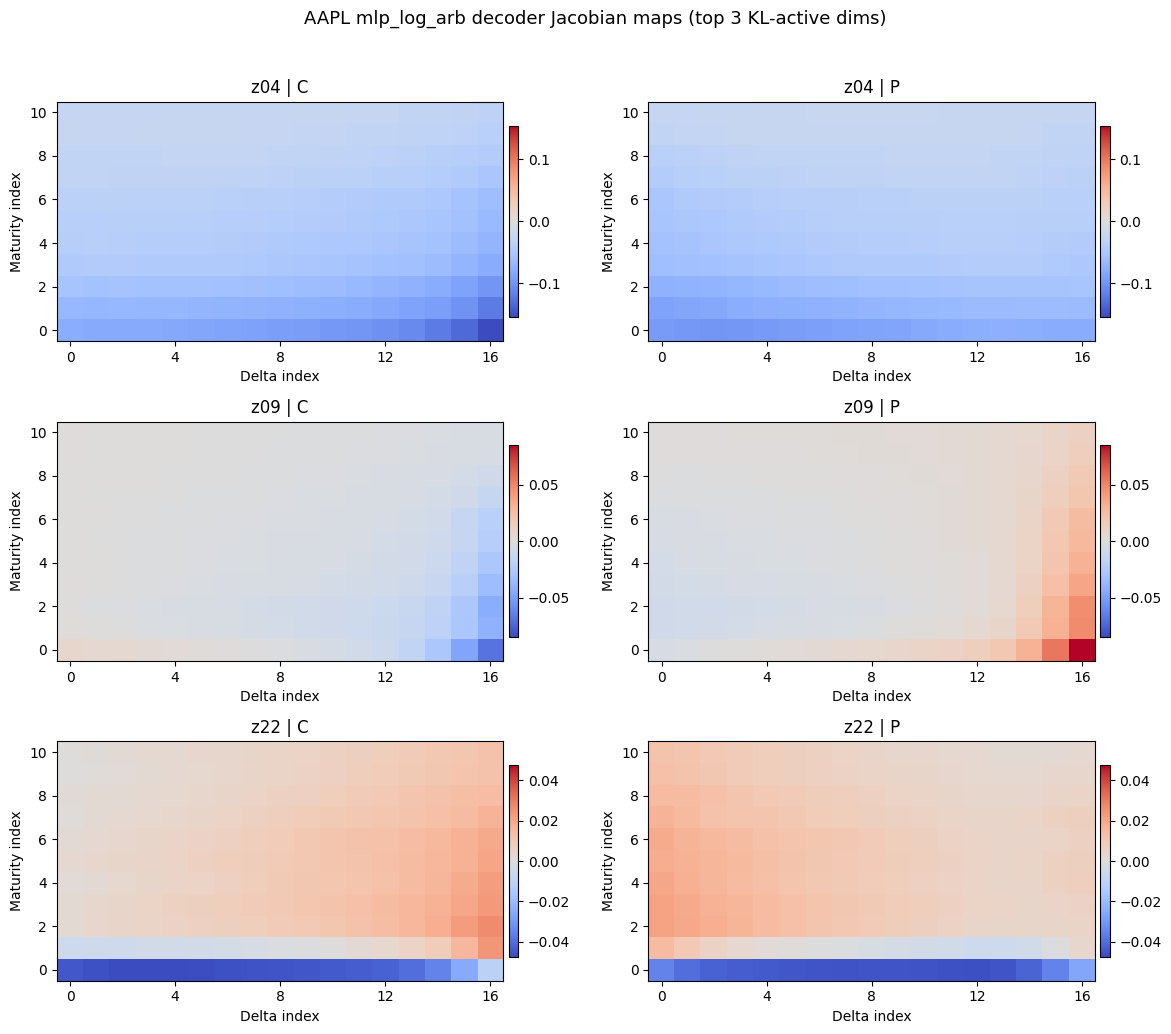

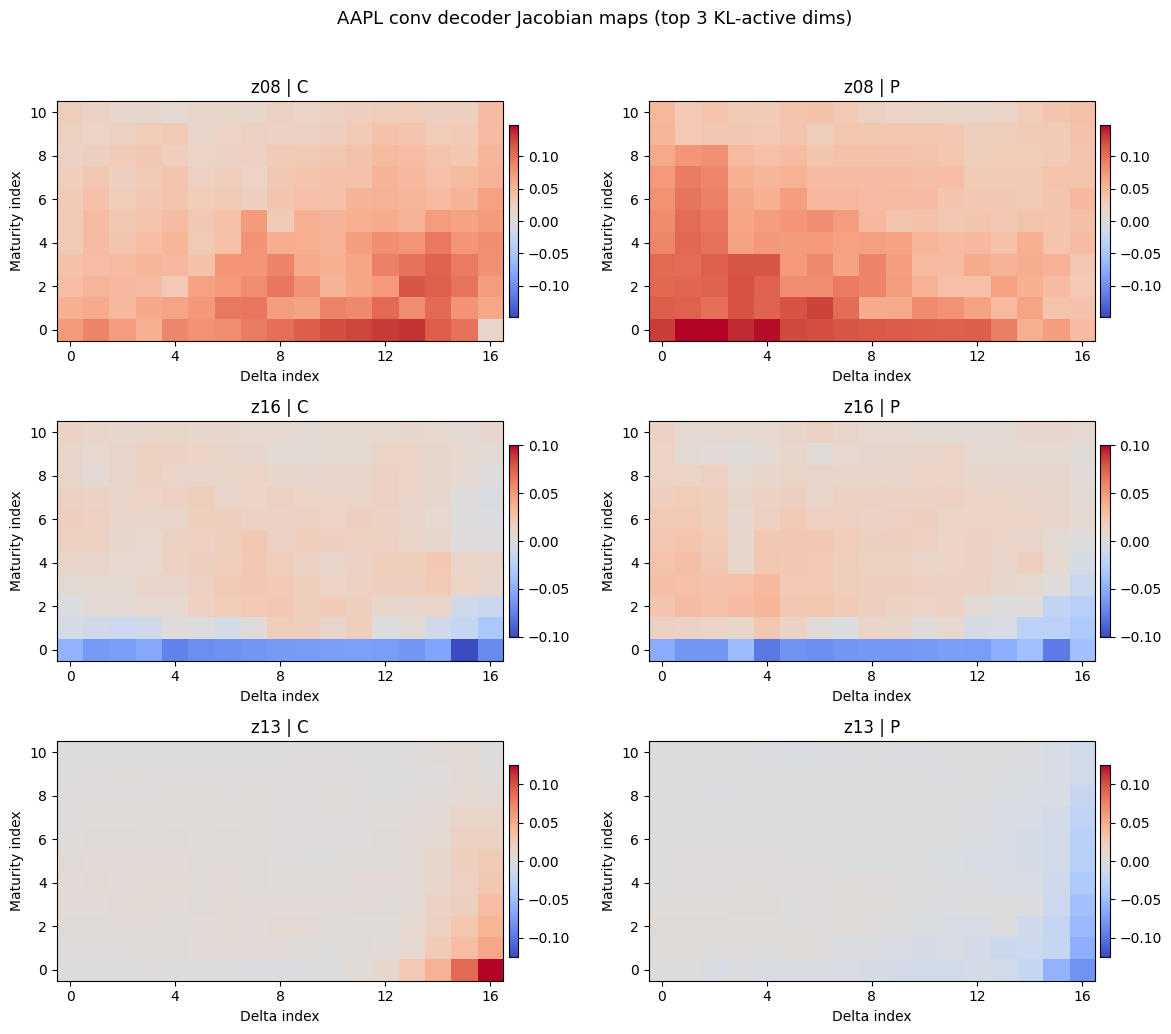

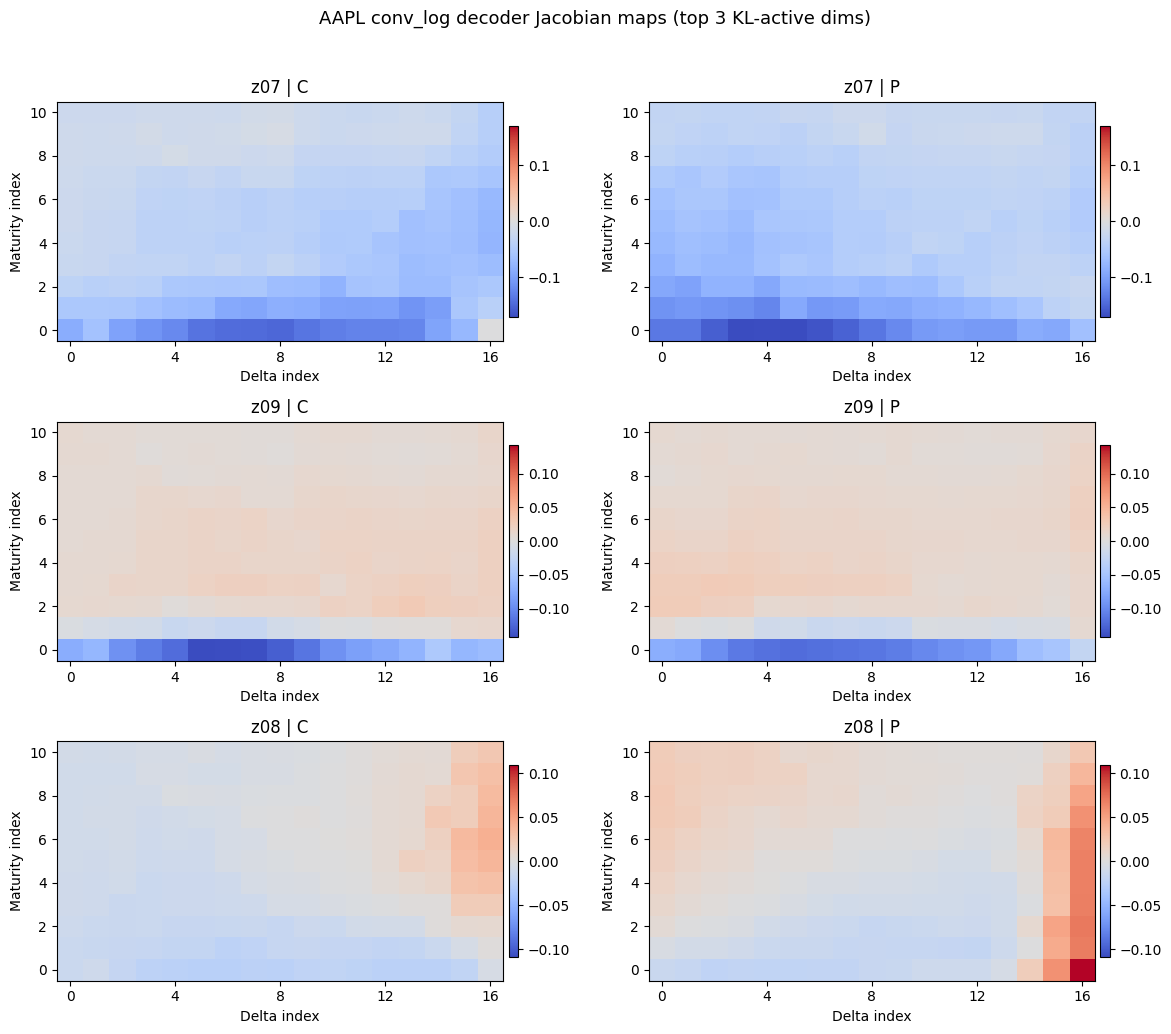

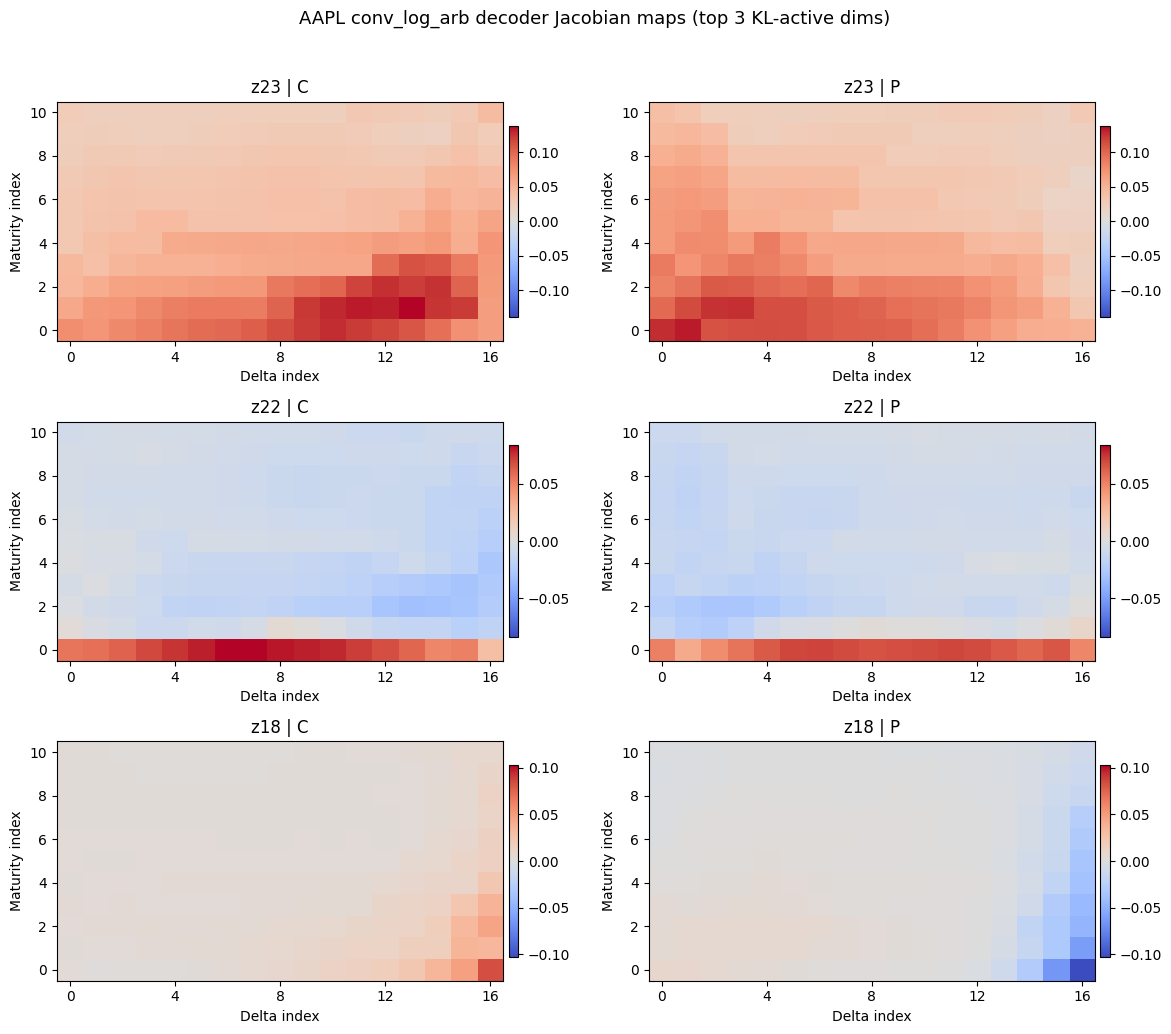

Saved Jacobian summary table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\latent_jacobian_summary_AAPL.csv
Saved Jacobian cell-level table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\latent_jacobian_cells_AAPL.csv
Saved Jacobian plot panels: 6 files
  C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_jacobian_topdims_mlp_AAPL.png
  C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_jacobian_topdims_mlp_log_AAPL.png
  C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\latent_jacobian_topdims_mlp_log_arb_AAPL.png
  C:\Users

,variant,latent_dim_idx,latent_dim_label,channel_idx,channel,mean_kl,share_of_total_kl,mean_abs_grad,max_abs_grad,max_grad_signed,max_grad_maturity_idx,max_grad_delta_idx
0,conv,7,z08,0,c,2.085939,0.448140,0.051917,0.133814,0.133814,0,13
1,conv,7,z08,1,p,2.085939,0.448140,0.061652,0.148082,0.148082,0,1
2,conv,12,z13,0,c,0.963805,0.207062,0.006463,0.125111,0.125111,0,16
3,conv,12,z13,1,p,0.963805,0.207062,0.005569,0.082502,-0.082502,0,16
4,conv,15,z16,0,c,1.141489,0.245236,0.015867,0.100064,-0.100064,0,15
5,conv,15,z16,1,p,1.141489,0.245236,0.017178,0.078408,-0.078408,0,4
6,conv_log,6,z07,0,c,2.109262,0.423774,0.047438,0.149393,-0.149393,0,8
7,conv_log,6,z07,1,p,2.109262,0.423774,0.055390,0.170992,-0.170992,0,3
8,conv_log,7,z08,0,c,0.819023,0.164551,0.011200,0.040982,0.040982,6,16
9,conv_log,7,z08,1,p,0.819023,0.164551,0.013275,0.108765,0.108765,0,16


In [13]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

JACOBIAN_TOP_K = 3

if "_load_model_scaler_and_latents" not in globals():
    raise RuntimeError("Model/scaler loader helper not available. Run the PCA traversal block first.")
if "days_grid" not in globals() or "delta_grid" not in globals() or "cp_order" not in globals():
    raise RuntimeError("Grid metadata is missing. Run the market-feature block first.")
if "features_df" not in globals():
    raise RuntimeError("features_df is not available. Run earlier blocks first.")

expected_dates = pd.to_datetime(features_df["date"]).dt.normalize()
jacobian_summary_rows = []
jacobian_cell_rows = []
jacobian_plot_paths = []

for variant in VARIANTS:
    model, scaler, mus_np, logvars_np, latent_dates = _load_model_scaler_and_latents(variant)

    if not latent_dates.equals(expected_dates):
        raise ValueError(f"{variant}: latent dates are not aligned with feature dates")

    kl_per_dim = 0.5 * (np.square(mus_np) + np.exp(logvars_np) - 1.0 - logvars_np)
    mean_kl_per_dim = kl_per_dim.mean(axis=0)
    total_mean_kl = float(mean_kl_per_dim.sum())
    if total_mean_kl <= 0.0:
        raise ValueError(f"{variant}: total KL is non-positive")

    top_dim_indices = np.argsort(mean_kl_per_dim)[::-1][:JACOBIAN_TOP_K]
    latent_mean = mus_np.mean(axis=0).astype(np.float32)
    z0 = torch.tensor(latent_mean, dtype=torch.float32, device=DEVICE, requires_grad=True)

    def decode_to_original(z_vec: torch.Tensor) -> torch.Tensor:
        recon = model.decode(z_vec.unsqueeze(0))
        recon_orig = scaler.inverse_transform(recon)
        return recon_orig.squeeze(0)  # [C, H, W]

    jac = torch.autograd.functional.jacobian(decode_to_original, z0, create_graph=False)
    jac_np = jac.detach().cpu().numpy()  # [C, H, W, latent_dim]

    fig, axes = plt.subplots(
        len(top_dim_indices), 2,
        figsize=(12, 3.5 * len(top_dim_indices)),
        squeeze=False,
    )

    for row_idx, dim_idx in enumerate(top_dim_indices):
        dim_label = f"z{dim_idx + 1:02d}"
        dim_kl = float(mean_kl_per_dim[dim_idx])
        dim_kl_share = float(dim_kl / total_mean_kl)

        grad_map = jac_np[:, :, :, dim_idx]  # [C, H, W]
        abs_grad = np.abs(grad_map)
        vlim = float(abs_grad.max())
        if vlim == 0.0:
            vlim = 1e-12

        for c in range(2):
            ax = axes[row_idx, c]
            channel_name = cp_order[c].upper() if c < len(cp_order) else f"CH{c}"
            im = ax.imshow(
                grad_map[c],
                origin="lower",
                aspect="auto",
                cmap="coolwarm",
                vmin=-vlim,
                vmax=vlim,
            )
            ax.set_title(f"{dim_label} | {channel_name}")
            ax.set_xlabel("Delta index")
            ax.set_ylabel("Maturity index")
            ax.set_xticks(range(0, len(delta_grid), 4))
            ax.set_yticks(range(0, len(days_grid), 2))
            fig.colorbar(im, ax=ax, shrink=0.8, pad=0.01)

        for c in range(grad_map.shape[0]):
            channel_abs = np.abs(grad_map[c])
            max_flat_idx = int(np.argmax(channel_abs))
            h_idx, w_idx = np.unravel_index(max_flat_idx, channel_abs.shape)
            jacobian_summary_rows.append(
                {
                    "variant": variant,
                    "latent_dim_idx": int(dim_idx),
                    "latent_dim_label": dim_label,
                    "channel_idx": c,
                    "channel": cp_order[c] if c < len(cp_order) else f"ch{c}",
                    "mean_kl": dim_kl,
                    "share_of_total_kl": dim_kl_share,
                    "mean_abs_grad": float(channel_abs.mean()),
                    "max_abs_grad": float(channel_abs.max()),
                    "max_grad_signed": float(grad_map[c, h_idx, w_idx]),
                    "max_grad_maturity_idx": int(h_idx),
                    "max_grad_delta_idx": int(w_idx),
                }
            )

            for h_idx in range(grad_map.shape[1]):
                for w_idx in range(grad_map.shape[2]):
                    jacobian_cell_rows.append(
                        {
                            "variant": variant,
                            "latent_dim_idx": int(dim_idx),
                            "latent_dim_label": dim_label,
                            "channel_idx": c,
                            "channel": cp_order[c] if c < len(cp_order) else f"ch{c}",
                            "maturity_idx": int(h_idx),
                            "delta_idx": int(w_idx),
                            "grad": float(grad_map[c, h_idx, w_idx]),
                            "abs_grad": float(abs(grad_map[c, h_idx, w_idx])),
                        }
                    )

    fig.suptitle(f"{TICKER} {variant} decoder Jacobian maps (top {JACOBIAN_TOP_K} KL-active dims)", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plot_path = PLOTS_DIR / f"latent_jacobian_topdims_{variant}_{TICKER}.png"
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    jacobian_plot_paths.append(plot_path)
    plt.show()

jacobian_summary_df = pd.DataFrame(jacobian_summary_rows).sort_values(
    ["variant", "latent_dim_idx", "channel_idx"]
).reset_index(drop=True)
jacobian_cells_df = pd.DataFrame(jacobian_cell_rows).sort_values(
    ["variant", "latent_dim_idx", "channel_idx", "maturity_idx", "delta_idx"]
).reset_index(drop=True)

jacobian_summary_csv = TABLES_DIR / f"latent_jacobian_summary_{TICKER}.csv"
jacobian_cells_csv = TABLES_DIR / f"latent_jacobian_cells_{TICKER}.csv"
jacobian_summary_df.to_csv(jacobian_summary_csv, index=False)
jacobian_cells_df.to_csv(jacobian_cells_csv, index=False)

print(f"Saved Jacobian summary table to: {jacobian_summary_csv}")
print(f"Saved Jacobian cell-level table to: {jacobian_cells_csv}")
print(f"Saved Jacobian plot panels: {len(jacobian_plot_paths)} files")
for path in jacobian_plot_paths:
    print(f"  {path}")

display(jacobian_summary_df.head(12))

## 10. Heston Parameters vs Latent Dimensions (F3)

This block correlates calibrated Heston parameters
(`v0`, `kappa`, `theta`, `sigma`, `rho`) with latent dimensions for each variant,
to compare parametric factors against learned VAE factors.

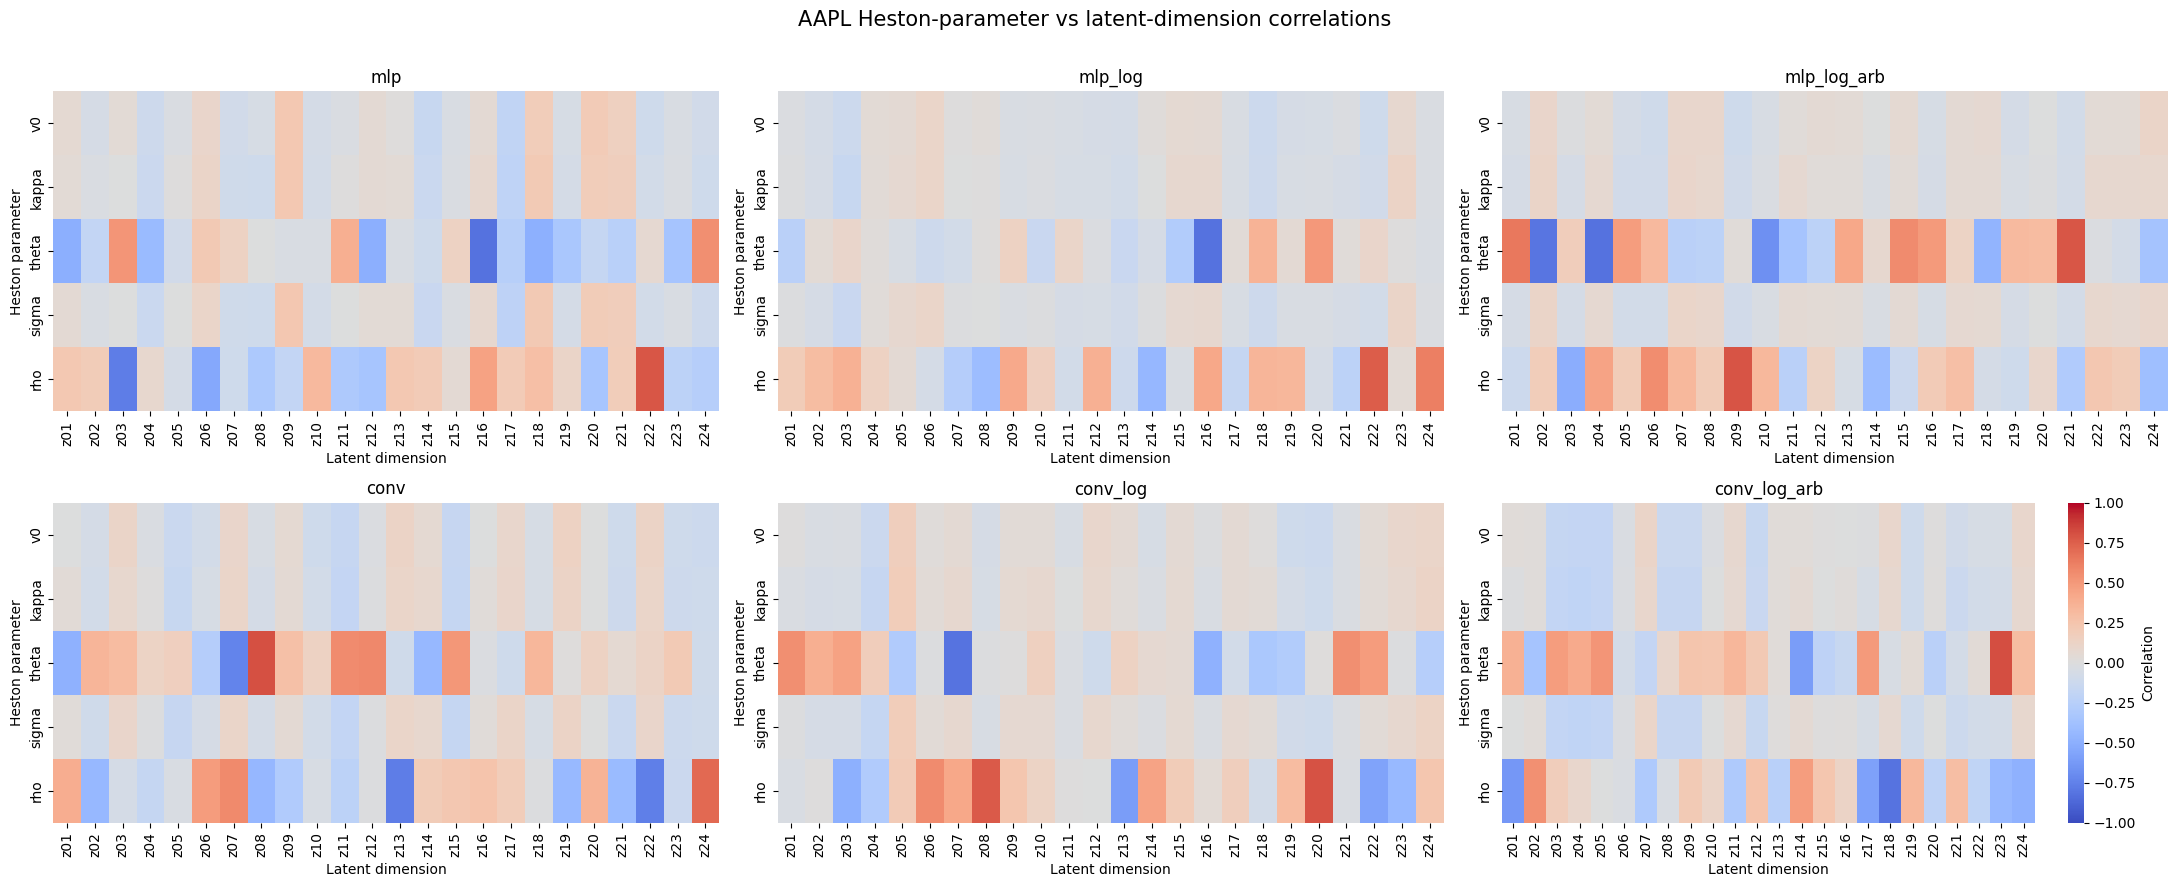

Saved Heston-latent full correlation table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\heston_latent_correlations_AAPL.csv
Saved Heston-latent best-match table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\heston_latent_best_match_AAPL.csv
Saved Heston-latent heatmap panel to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\plots\heston_latent_correlation_heatmaps_AAPL.png


heston_param,kappa,rho,sigma,theta,v0
variant,,,,,
mlp,z09 (+0.22),z22 (+0.79),z09 (+0.23),z16 (-0.83),z09 (+0.22)
mlp_log,z03 (-0.15),z22 (+0.76),z03 (-0.14),z16 (-0.83),z03 (-0.12)
mlp_log_arb,z02 (+0.11),z09 (+0.79),z02 (+0.11),z04 (-0.82),z24 (+0.11)
conv,z11 (-0.18),z13 (-0.77),z11 (-0.19),z08 (+0.81),z15 (-0.16)
conv_log,z05 (+0.18),z20 (+0.80),z05 (+0.18),z07 (-0.82),z05 (+0.17)
conv_log_arb,z04 (-0.20),z18 (-0.82),z04 (-0.20),z23 (+0.82),z05 (-0.18)


In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt

HESTON_PARAMS = ["v0", "kappa", "theta", "sigma", "rho"]
heston_params_path = ROOT / "data" / "processed" / "heston" / "surfaces" / f"{TICKER}_heston_params.csv"

if not heston_params_path.exists():
    raise FileNotFoundError(f"Missing Heston parameter file: {heston_params_path}")
if "features_df" not in globals():
    raise RuntimeError("features_df is not available. Run earlier blocks first.")

heston_df = pd.read_csv(heston_params_path)
required_cols = ["date", *HESTON_PARAMS]
missing_cols = [col for col in required_cols if col not in heston_df.columns]
if missing_cols:
    raise KeyError(f"Heston params file missing columns: {missing_cols}")

heston_df = heston_df[required_cols].copy()
heston_df["date"] = pd.to_datetime(heston_df["date"]).dt.normalize()
heston_df = heston_df.sort_values("date").reset_index(drop=True)

if heston_df["date"].duplicated().any():
    dup_dates = heston_df.loc[heston_df["date"].duplicated(), "date"].astype(str).tolist()
    raise ValueError(f"Duplicate dates in Heston params file: {dup_dates[:5]}")

expected_dates = pd.to_datetime(features_df["date"]).dt.normalize()
heston_corr_rows = []

for variant in VARIANTS:
    latent_path = EVAL_ROOT / variant / "test_latents.pt"
    payload = torch.load(latent_path, map_location="cpu", weights_only=False)

    mus = payload["mus"].detach().cpu().numpy() if isinstance(payload["mus"], torch.Tensor) else np.asarray(payload["mus"] )
    latent_dates = pd.to_datetime(pd.Series(payload["dates"])).dt.normalize()

    if mus.ndim != 2:
        raise ValueError(f"{variant}: expected 2D latent means, got {mus.shape}")
    if not latent_dates.equals(expected_dates):
        raise ValueError(f"{variant}: latent dates are not aligned with feature dates")

    latent_date_df = pd.DataFrame({"date": latent_dates})
    merged = latent_date_df.merge(heston_df, on="date", how="left", validate="one_to_one")

    if merged[HESTON_PARAMS].isna().any().any():
        na_counts = merged[HESTON_PARAMS].isna().sum()
        raise ValueError(
            f"{variant}: missing Heston params after date merge:\n"
            + na_counts[na_counts > 0].to_string()
        )

    for dim_idx in range(mus.shape[1]):
        latent_values = mus[:, dim_idx]
        latent_std = float(np.std(latent_values))

        for param in HESTON_PARAMS:
            param_values = merged[param].to_numpy()
            param_std = float(np.std(param_values))
            if param_std == 0.0:
                corr = 0.0
            elif latent_std == 0.0:
                corr = 0.0
            else:
                corr = float(np.corrcoef(latent_values, param_values)[0, 1])

            heston_corr_rows.append(
                {
                    "variant": variant,
                    "latent_dim_idx": dim_idx,
                    "latent_dim_label": f"z{dim_idx + 1:02d}",
                    "heston_param": param,
                    "correlation": corr,
                    "abs_correlation": abs(corr),
                }
            )

heston_latent_corr_df = pd.DataFrame(heston_corr_rows).sort_values(
    ["variant", "heston_param", "abs_correlation"],
    ascending=[True, True, False],
).reset_index(drop=True)

heston_corr_csv = TABLES_DIR / f"heston_latent_correlations_{TICKER}.csv"
heston_latent_corr_df.to_csv(heston_corr_csv, index=False)

heston_best_match_df = (
    heston_latent_corr_df.groupby(["variant", "heston_param"], as_index=False)
    .first()
    .sort_values(["heston_param", "variant"])
    .reset_index(drop=True)
)
heston_best_match_csv = TABLES_DIR / f"heston_latent_best_match_{TICKER}.csv"
heston_best_match_df.to_csv(heston_best_match_csv, index=False)

fig, axes = plt.subplots(2, 3, figsize=(22, 9))
for ax, variant in zip(axes.flat, VARIANTS):
    matrix = (
        heston_latent_corr_df[heston_latent_corr_df["variant"] == variant]
        .pivot(index="heston_param", columns="latent_dim_label", values="correlation")
        .reindex(HESTON_PARAMS)
    )
    sns.heatmap(
        matrix,
        cmap="coolwarm",
        center=0.0,
        vmin=-1.0,
        vmax=1.0,
        ax=ax,
        cbar=ax is axes.flat[-1],
        cbar_kws={"label": "Correlation"},
    )
    ax.set_title(variant)
    ax.set_xlabel("Latent dimension")
    ax.set_ylabel("Heston parameter")

fig.suptitle(f"{TICKER} Heston-parameter vs latent-dimension correlations", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.97])
heston_heatmap_path = PLOTS_DIR / f"heston_latent_correlation_heatmaps_{TICKER}.png"
fig.savefig(heston_heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

best_display = heston_best_match_df.copy()
best_display["best_latent_match"] = best_display.apply(
    lambda row: f"{row['latent_dim_label']} ({row['correlation']:+.2f})",
    axis=1,
)
best_pivot = best_display.pivot(index="variant", columns="heston_param", values="best_latent_match").reindex(VARIANTS)

print(f"Saved Heston-latent full correlation table to: {heston_corr_csv}")
print(f"Saved Heston-latent best-match table to: {heston_best_match_csv}")
print(f"Saved Heston-latent heatmap panel to: {heston_heatmap_path}")

display(best_pivot)

## 11. 3D Pilot Gate Check (E1/E2 pilot)

This block summarizes the staged 3D pilot for `mlp_log_3d` and `conv_log_arb_3d`,
comparing 24D vs 3D accuracy/arbitrage metrics and checking 3D latent-dimension KL activity.
It exports pilot tables to support the expansion decision for full Phase E.

In [15]:
import json
import numpy as np
import pandas as pd
import torch

from src.utils.arbitrage import count_calendar_violations, count_butterfly_violations

PILOT_PAIRS = [
    ("mlp_log", "mlp_log_3d"),
    ("conv_log_arb", "conv_log_arb_3d"),
]
KL_MIN_SHARE_THRESHOLD = 0.05

pilot_rows = []
pilot_kl_rows = []
pilot_gate_rows = []

for base_variant, pilot_variant in PILOT_PAIRS:
    base_eval_dir = EVAL_ROOT / base_variant
    pilot_eval_dir = EVAL_ROOT / pilot_variant

    base_metrics_path = base_eval_dir / "test_metrics.json"
    pilot_metrics_path = pilot_eval_dir / "test_metrics.json"
    pilot_latent_path = pilot_eval_dir / "test_latents.pt"
    base_surfaces_path = base_eval_dir / "surfaces" / "vae_surfaces.npy"
    pilot_surfaces_path = pilot_eval_dir / "surfaces" / "vae_surfaces.npy"

    for path in [base_metrics_path, pilot_metrics_path, pilot_latent_path, base_surfaces_path, pilot_surfaces_path]:
        if not path.exists():
            raise FileNotFoundError(f"Required pilot file missing: {path}")

    with open(base_metrics_path, "r", encoding="utf-8") as f:
        base_metrics = json.load(f)
    with open(pilot_metrics_path, "r", encoding="utf-8") as f:
        pilot_metrics = json.load(f)

    base_surfaces = np.load(base_surfaces_path)
    pilot_surfaces = np.load(pilot_surfaces_path)

    base_cal_v, base_cal_total = count_calendar_violations(base_surfaces, days_grid)
    base_but_v, base_but_total = count_butterfly_violations(base_surfaces)
    pilot_cal_v, pilot_cal_total = count_calendar_violations(pilot_surfaces, days_grid)
    pilot_but_v, pilot_but_total = count_butterfly_violations(pilot_surfaces)

    base_mae_vp = float(base_metrics["mae_original"] * 100.0)
    pilot_mae_vp = float(pilot_metrics["mae_original"] * 100.0)
    base_rmse_vp = float(base_metrics["rmse_original"] * 100.0)
    pilot_rmse_vp = float(pilot_metrics["rmse_original"] * 100.0)

    base_cal_rate = float(base_cal_v / base_cal_total) if base_cal_total > 0 else 0.0
    pilot_cal_rate = float(pilot_cal_v / pilot_cal_total) if pilot_cal_total > 0 else 0.0
    base_but_rate = float(base_but_v / base_but_total) if base_but_total > 0 else 0.0
    pilot_but_rate = float(pilot_but_v / pilot_but_total) if pilot_but_total > 0 else 0.0

    latent_payload = torch.load(pilot_latent_path, map_location="cpu", weights_only=False)
    mus_np = latent_payload["mus"].detach().cpu().numpy() if isinstance(latent_payload["mus"], torch.Tensor) else np.asarray(latent_payload["mus"] )
    logvars_np = latent_payload["logvars"].detach().cpu().numpy() if isinstance(latent_payload["logvars"], torch.Tensor) else np.asarray(latent_payload["logvars"] )

    kl_per_sample_dim = 0.5 * (np.square(mus_np) + np.exp(logvars_np) - 1.0 - logvars_np)
    mean_kl_per_dim = kl_per_sample_dim.mean(axis=0)
    total_kl = float(mean_kl_per_dim.sum())
    shares = mean_kl_per_dim / total_kl if total_kl > 0 else np.zeros_like(mean_kl_per_dim)

    all_dims_active = bool(np.all(shares >= KL_MIN_SHARE_THRESHOLD))
    min_share = float(np.min(shares)) if shares.size else 0.0

    pilot_rows.append(
        {
            "base_variant_24d": base_variant,
            "pilot_variant_3d": pilot_variant,
            "mae_24d_vp": base_mae_vp,
            "mae_3d_vp": pilot_mae_vp,
            "mae_delta_vp_3d_minus_24d": pilot_mae_vp - base_mae_vp,
            "rmse_24d_vp": base_rmse_vp,
            "rmse_3d_vp": pilot_rmse_vp,
            "rmse_delta_vp_3d_minus_24d": pilot_rmse_vp - base_rmse_vp,
            "calendar_rate_24d": base_cal_rate,
            "calendar_rate_3d": pilot_cal_rate,
            "butterfly_rate_24d": base_but_rate,
            "butterfly_rate_3d": pilot_but_rate,
        }
    )

    for dim_idx, (mean_kl, share) in enumerate(zip(mean_kl_per_dim, shares), start=1):
        pilot_kl_rows.append(
            {
                "pilot_variant_3d": pilot_variant,
                "latent_dim_label": f"z{dim_idx:02d}",
                "mean_kl": float(mean_kl),
                "share_of_total_kl": float(share),
                "is_active_share_ge_5pct": bool(share >= KL_MIN_SHARE_THRESHOLD),
            }
        )

    pilot_gate_rows.append(
        {
            "pilot_variant_3d": pilot_variant,
            "total_mean_kl": total_kl,
            "min_dim_share": min_share,
            "all_3_dims_share_ge_5pct": all_dims_active,
        }
    )

pilot_summary_df = pd.DataFrame(pilot_rows).sort_values("pilot_variant_3d").reset_index(drop=True)
pilot_kl_df = pd.DataFrame(pilot_kl_rows).sort_values(["pilot_variant_3d", "latent_dim_label"]).reset_index(drop=True)
pilot_gate_df = pd.DataFrame(pilot_gate_rows).sort_values("pilot_variant_3d").reset_index(drop=True)

pilot_summary_csv = TABLES_DIR / f"pilot_3d_vs_24d_metrics_{TICKER}.csv"
pilot_kl_csv = TABLES_DIR / f"pilot_3d_kl_dims_{TICKER}.csv"
pilot_gate_csv = TABLES_DIR / f"pilot_3d_gate_{TICKER}.csv"

pilot_summary_df.to_csv(pilot_summary_csv, index=False)
pilot_kl_df.to_csv(pilot_kl_csv, index=False)
pilot_gate_df.to_csv(pilot_gate_csv, index=False)

print(f"Saved pilot 24D-vs-3D metrics to: {pilot_summary_csv}")
print(f"Saved pilot 3D KL-dimension table to: {pilot_kl_csv}")
print(f"Saved pilot gate table to: {pilot_gate_csv}")

display(pilot_summary_df)
display(pilot_gate_df)

Saved pilot 24D-vs-3D metrics to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\pilot_3d_vs_24d_metrics_AAPL.csv
Saved pilot 3D KL-dimension table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\pilot_3d_kl_dims_AAPL.csv
Saved pilot gate table to: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\latent_analysis\AAPL\tables\pilot_3d_gate_AAPL.csv


,base_variant_24d,pilot_variant_3d,mae_24d_vp,mae_3d_vp,mae_delta_vp_3d_minus_24d,rmse_24d_vp,rmse_3d_vp,rmse_delta_vp_3d_minus_24d,calendar_rate_24d,calendar_rate_3d,butterfly_rate_24d,butterfly_rate_3d
0,conv_log_arb,conv_log_arb_3d,1.287381,1.749272,0.461891,1.768667,2.778356,1.009689,0.0,0.0,0.010805,0.011302
1,mlp_log,mlp_log_3d,1.087157,1.912388,0.825231,1.706442,2.907707,1.201265,0.0,0.0,0.237531,0.273733


,pilot_variant_3d,total_mean_kl,min_dim_share,all_3_dims_share_ge_5pct
0,conv_log_arb_3d,1.377500,0.000543,False
1,mlp_log_3d,1.269615,0.020316,False


## 12. Interactive Latent Walk (Top-3 KL Dimensions)

This interactive block turns the latent interpretation into a live exploration tool.

What it does:
- Select a trained 24D variant.
- Automatically pick that variant's top-3 KL-active dimensions.
- Move three sliders in standardized units (σ) around each dim's empirical mean.
- Decode the latent point and render the generated IV surface in 3D.
- Toggle between call/put channels.

Interpretation semantics:
- Slider value = latent offset in standard deviations for that dimension.
- `0` = empirical latent mean for the selected variant.
- Top-3 dimensions are chosen by KL share (not PCA), consistent with the P5 claim.

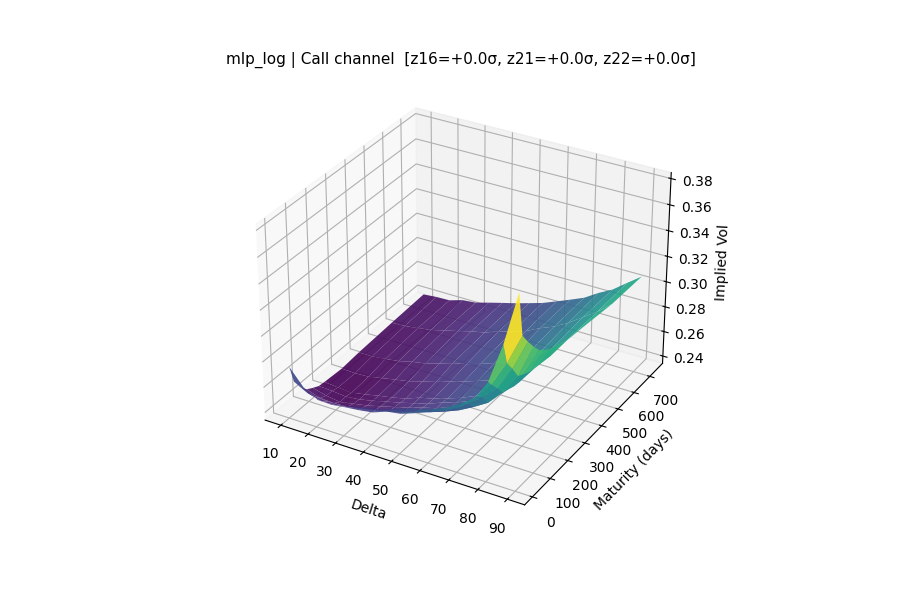

In [16]:
%matplotlib widget

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import ipywidgets as widgets
from IPython.display import display

if "_load_model_scaler_and_latents" not in globals():
    raise RuntimeError("Model/scaler loader helper missing. Run the PCA traversal block first.")
if "days_grid" not in globals() or "delta_grid" not in globals() or "cp_order" not in globals():
    raise RuntimeError("Grid metadata missing. Run the market-feature block first.")
if "VARIANTS" not in globals():
    raise RuntimeError("VARIANTS list not found in kernel.")

X_grid = np.asarray(delta_grid, dtype=float)
if np.nanmax(X_grid) <= 1.0:
    X_grid = X_grid * 100.0
Y_grid = np.asarray(days_grid, dtype=float)
X_mesh, Y_mesh = np.meshgrid(X_grid, Y_grid)

variant_cache: dict[str, dict] = {}


def _prepare_variant(variant: str) -> dict:
    if variant in variant_cache:
        return variant_cache[variant]

    model, scaler, mus_np, logvars_np, _ = _load_model_scaler_and_latents(variant)

    kl_per_sample_dim = 0.5 * (np.square(mus_np) + np.exp(logvars_np) - 1.0 - logvars_np)
    mean_kl_per_dim = kl_per_sample_dim.mean(axis=0)
    total_kl = float(mean_kl_per_dim.sum())
    if total_kl <= 0.0:
        raise ValueError(f"{variant}: total KL is non-positive")

    top_dim_indices = np.argsort(mean_kl_per_dim)[::-1][:3]

    z_mean = mus_np.mean(axis=0).astype(np.float32)
    z_std = mus_np.std(axis=0, ddof=0).astype(np.float32)
    z_std = np.where(z_std > 1e-8, z_std, 1e-6)

    top_dim_info = []
    for idx in top_dim_indices:
        top_dim_info.append({
            "idx": int(idx),
            "label": f"z{idx + 1:02d}",
            "kl_share": float(mean_kl_per_dim[idx] / total_kl),
            "mean": float(z_mean[idx]),
            "std": float(z_std[idx]),
        })

    variant_cache[variant] = {
        "model": model,
        "scaler": scaler,
        "z_mean": z_mean,
        "z_std": z_std,
        "top_dim_info": top_dim_info,
    }
    return variant_cache[variant]


# ── Controls ──────────────────────────────────────────────────────────────────
variant_default = "mlp_log" if "mlp_log" in VARIANTS else VARIANTS[0]
variant_dropdown = widgets.Dropdown(
    options=list(VARIANTS),
    value=variant_default,
    description="Variant:",
    layout=widgets.Layout(width="280px"),
)

channel_toggle = widgets.ToggleButtons(
    options=[("Call", "call"), ("Put", "put")],
    value="call",
    description="Channel:",
)

slider_layout = widgets.Layout(width="450px")
slider_style = {"description_width": "90px"}
s1 = widgets.FloatSlider(min=-3.0, max=3.0, step=0.1, value=0.0, description="Dim 1",
                          style=slider_style, layout=slider_layout, continuous_update=False)
s2 = widgets.FloatSlider(min=-3.0, max=3.0, step=0.1, value=0.0, description="Dim 2",
                          style=slider_style, layout=slider_layout, continuous_update=False)
s3 = widgets.FloatSlider(min=-3.0, max=3.0, step=0.1, value=0.0, description="Dim 3",
                          style=slider_style, layout=slider_layout, continuous_update=False)
reset_button = widgets.Button(description="Reset sliders", button_style="")

meta_html = widgets.HTML()
status_html = widgets.HTML()

current_top_dims: list[dict] = []

# ── Persistent matplotlib figure ──────────────────────────────────────────────
fig_3d = plt.figure(figsize=(9, 6))
ax_3d = fig_3d.add_subplot(111, projection="3d")
fig_3d.canvas.header_visible = False
fig_3d.canvas.toolbar_position = "left"


def _channel_index(channel_key: str) -> int:
    labels = [str(item).lower() for item in cp_order]
    if channel_key == "call":
        for i, lbl in enumerate(labels):
            if lbl.startswith("c"):
                return i
        return 0
    for i, lbl in enumerate(labels):
        if lbl.startswith("p"):
            return i
    return min(1, len(labels) - 1)


def _refresh_variant_ui(variant: str) -> None:
    global current_top_dims
    data = _prepare_variant(variant)
    current_top_dims = data["top_dim_info"]

    for slider, dim_info in zip([s1, s2, s3], current_top_dims):
        slider.description = dim_info["label"]
        slider.value = 0.0

    rows = "".join(
        f"<li><b>{d['label']}</b>: KL share = {d['kl_share']:.2%}, "
        f"\u03bc = {d['mean']:.3f}, \u03c3 = {d['std']:.3f}</li>"
        for d in current_top_dims
    )
    meta_html.value = (
        f"<b>Top-3 KL dimensions for {variant}</b>"
        f"<ul style='margin-top:4px; margin-bottom:4px'>{rows}</ul>"
        f"<span style='font-size:0.9em'>Slider value = offset in \u03c3 from latent mean.</span>"
    )


def _decode_current_surface() -> np.ndarray:
    data = _prepare_variant(variant_dropdown.value)
    z = data["z_mean"].copy()
    for sigma_offset, dim_info in zip([float(s1.value), float(s2.value), float(s3.value)], current_top_dims):
        z[dim_info["idx"]] = float(dim_info["mean"] + sigma_offset * dim_info["std"])

    with torch.no_grad():
        z_tensor = torch.tensor(z[None, :], dtype=torch.float32, device=DEVICE)
        recon = data["model"].decode(z_tensor)
        surface = data["scaler"].inverse_transform(recon).detach().cpu().numpy()[0]
    return surface


def _update(*_):
    try:
        if not current_top_dims:
            _refresh_variant_ui(variant_dropdown.value)

        surface = _decode_current_surface()
        channel_idx = _channel_index(channel_toggle.value)
        z_plot = surface[channel_idx]

        ax_3d.clear()
        ax_3d.plot_surface(X_mesh, Y_mesh, z_plot, cmap="viridis", edgecolor="none", alpha=0.9)
        ax_3d.set_xlabel("Delta")
        ax_3d.set_ylabel("Maturity (days)")
        ax_3d.set_zlabel("Implied Vol")
        ax_3d.set_title(
            f"{variant_dropdown.value} | {channel_toggle.value.capitalize()} channel  "
            f"[{current_top_dims[0]['label']}={s1.value:+.1f}\u03c3, "
            f"{current_top_dims[1]['label']}={s2.value:+.1f}\u03c3, "
            f"{current_top_dims[2]['label']}={s3.value:+.1f}\u03c3]",
            fontsize=11,
        )
        fig_3d.canvas.draw_idle()

        status_html.value = (
            f"<span style='color:#444'>Current offsets: "
            f"{current_top_dims[0]['label']}={s1.value:+.1f}\u03c3, "
            f"{current_top_dims[1]['label']}={s2.value:+.1f}\u03c3, "
            f"{current_top_dims[2]['label']}={s3.value:+.1f}\u03c3</span>"
        )
    except Exception as exc:
        status_html.value = f"<span style='color:#B00020'><b>Update error:</b> {exc}</span>"


def _on_variant_change(change):
    if change.get("name") == "value":
        _refresh_variant_ui(change["new"])
        _update()


def _on_reset_click(_):
    for slider in (s1, s2, s3):
        slider.value = 0.0


variant_dropdown.observe(_on_variant_change, names="value")
channel_toggle.observe(_update, names="value")
for slider in (s1, s2, s3):
    slider.observe(_update, names="value")
reset_button.on_click(_on_reset_click)

# ── Initial render ────────────────────────────────────────────────────────────
_refresh_variant_ui(variant_dropdown.value)
_update()

controls = widgets.VBox([
    widgets.HBox([variant_dropdown, channel_toggle, reset_button]),
    widgets.HBox([s1, s2, s3]),
    meta_html,
    status_html,
])

display(controls)